# Proyecto Final de Mineria de Datos
Este notebook aplica los temas principales de la materia al dataset `Cancer_Data.csv`.

El objetivo es estudiar el diagnostico de cancer desde varias miradas: preparacion y calidad de datos, analisis exploratorio, modelos supervisados, modelos no supervisados, PCA, reglas de asociacion y comparacion final de resultados.

La explicacion esta escrita para una exposicion academica: primero se muestra que se hizo, luego por que se hizo y finalmente como se interpreta el resultado.


# Guia de lectura del proyecto final

Este notebook sigue los lineamientos de entrega final de la materia:

- presenta el problema y el objetivo del analisis;
- carga y describe el dataset;
- revisa calidad de datos, valores nulos, duplicados, tipos de variables y posibles outliers;
- realiza EDA con histogramas, boxplots, conteos, correlaciones y relaciones multivariadas;
- justifica preparacion de datos, escalado, encoding y division train/test;
- compara modelos supervisados de clasificacion y regresion;
- aplica modelos no supervisados, PCA, clustering, reglas de asociacion y analisis de correspondencias;
- cierra con seleccion de modelo, limitaciones y posibles mejoras.

La idea central del proyecto es usar `Cancer_Data.csv` como un caso de estudio completo: no solo buscamos predecir si un tumor es benigno o maligno, tambien queremos explicar que patrones aparecen en las variables y que tan confiables son los modelos.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Para asegurar que las gráficas se carguen correctamente:
%matplotlib inline
plt.style.use('ggplot')
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Carga y Exploración de Datos
Cargamos el dataset y revisamos sus dimensiones y primeras filas.

In [2]:
# Cargar el dataset
df = pd.read_csv('Cancer_Data.csv')

# Limpiar nombres de columnas (eliminar espacios y comillas)
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M")
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

print("Dimensiones originales:", df.shape)

display(df.head())
display(df.info())

Dimensiones originales: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

## Diccionario de variables

El dataset tiene una variable objetivo (`diagnosis`) y un conjunto de mediciones numericas del tumor. Las variables siguen una estructura repetida:

- `*_mean`: promedio de la medicion.
- `*_se`: error estandar de la medicion.
- `*_worst`: peor valor observado o valor mas extremo.

Esto ayuda a interpretar el dataset sin memorizar treinta columnas una por una: cada nombre combina una caracteristica clinica con una forma de resumen estadistico.


In [3]:
base_descriptions = {
    "radius": "Radio del tumor.",
    "texture": "Variacion de intensidad o textura.",
    "perimeter": "Perimetro del tumor.",
    "area": "Area del tumor.",
    "smoothness": "Suavidad del contorno.",
    "compactness": "Compacidad del tumor.",
    "concavity": "Grado de concavidad.",
    "concave points": "Cantidad de puntos concavos.",
    "symmetry": "Simetria del tumor.",
    "fractal_dimension": "Complejidad del borde.",
}

suffix_descriptions = {
    "mean": "valor promedio",
    "se": "error estandar",
    "worst": "valor mas extremo",
}

diccionario = []
for col in df.columns:
    if col == "id":
        descripcion = "Identificador del paciente o registro. No se usa para modelar."
        tipo = "Identificador"
    elif col == "diagnosis":
        descripcion = "Diagnostico del tumor: M = maligno, B = benigno. Es la variable objetivo."
        tipo = "Objetivo"
    else:
        partes = col.rsplit("_", 1)
        if len(partes) == 2:
            base, sufijo = partes
            descripcion = f"{suffix_descriptions.get(sufijo, 'medicion')} de {base_descriptions.get(base, base)}"
        else:
            descripcion = "Variable numerica del tumor."
        tipo = "Predictora numerica"
    diccionario.append({"variable": col, "tipo": tipo, "descripcion": descripcion})

diccionario_variables = pd.DataFrame(diccionario)
display(diccionario_variables)


,variable,tipo,descripcion
0,id,Identificador,Identificador del paciente o registro. No se u...
1,diagnosis,Objetivo,"Diagnostico del tumor: M = maligno, B = benign..."
2,radius_mean,Predictora numerica,valor promedio de Radio del tumor.
3,texture_mean,Predictora numerica,valor promedio de Variacion de intensidad o te...
4,perimeter_mean,Predictora numerica,valor promedio de Perimetro del tumor.
5,area_mean,Predictora numerica,valor promedio de Area del tumor.
6,smoothness_mean,Predictora numerica,valor promedio de Suavidad del contorno.
7,compactness_mean,Predictora numerica,valor promedio de Compacidad del tumor.
8,concavity_mean,Predictora numerica,valor promedio de Grado de concavidad.
9,concave points_mean,Predictora numerica,valor promedio de Cantidad de puntos concavos.


### 1.1 Limpieza de Datos
Verificamos valores faltantes y eliminamos columnas irrelevantes.

In [4]:
import numpy as np
import pandas as pd # Ensure pandas is imported
import os

# Cargar el dataset para asegurar un estado fresco del DataFrame
file_path = 'Cancer_Data.csv'
if not os.path.exists(file_path):
    file_path = '/content/sample_data/Cancer_Data.csv'
df = pd.read_csv(file_path)

# Limpiar nombres de columnas (eliminar espacios y comillas) - moved from previous cell
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M") - moved from previous cell
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Cantidad de faltantes por columna
print("Faltantes por columna:")
display(df.isna().sum().sort_values(ascending=False).head(5))

# Eliminar columnas irrelevantes (id y la última columna vacía que suele aparecer)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
# If there's an unnamed column, this might be it. Dropping based on `df.isna().all()` later is more robust.
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

# Identify columns with all NaNs, but exclude 'diagnosis' from this list
# 'diagnosis' is the target variable and should not be dropped, even if it appears to be all NaNs
cols_to_drop_nan = [col for col in df.columns if col != 'diagnosis' and df[col].isna().all()]

if cols_to_drop_nan:
    df.drop(columns=cols_to_drop_nan, inplace=True)
    print(f"Columnas con solo NaN eliminadas: {cols_to_drop_nan}")

# Codificar la variable objetivo (Maligno = 1, Benigno = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Dimensiones limpias:", df.shape)

Faltantes por columna:


id                0
diagnosis         0
radius_mean       0
texture_mean      0
perimeter_mean    0
dtype: int64

Dimensiones limpias: (569, 31)


## Calidad de datos ampliada

Ademas de revisar valores nulos, verificamos duplicados, tipos de datos y posibles outliers. En datos medicos los outliers no siempre son errores: a veces representan pacientes con mediciones extremas. Por eso se detectan y se interpretan, pero no se eliminan automaticamente.


In [5]:
duplicados = df.duplicated().sum()
tipos = df.dtypes.value_counts()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    outlier_rows.append({
        "variable": col,
        "outliers_iqr": int(n_outliers),
        "porcentaje": round(n_outliers / len(df) * 100, 2)
    })

calidad_resumen = pd.DataFrame({
    "indicador": ["filas", "columnas", "duplicados"],
    "valor": [df.shape[0], df.shape[1], duplicados]
})

print("Resumen de calidad:")
display(calidad_resumen)
print("Tipos de datos:")
display(tipos.to_frame("cantidad"))
print("Variables con mas posibles outliers por IQR:")
display(pd.DataFrame(outlier_rows).sort_values("outliers_iqr", ascending=False).head(10))

print("Lectura para exposicion:")
print("Los outliers se revisan porque pueden ser tumores con valores realmente extremos. En este proyecto se conservan para no borrar informacion clinica potencialmente importante.")


Resumen de calidad:


,indicador,valor
0,filas,569
1,columnas,31
2,duplicados,0


Tipos de datos:


,cantidad
float64,30
int64,1


Variables con mas posibles outliers por IQR:


,variable,outliers_iqr,porcentaje
14,area_se,65,11.42
11,radius_se,38,6.68
13,perimeter_se,38,6.68
24,area_worst,35,6.15
15,smoothness_se,30,5.27
16,compactness_se,28,4.92
20,fractal_dimension_se,28,4.92
19,symmetry_se,27,4.75
4,area_mean,25,4.39
30,fractal_dimension_worst,24,4.22


Lectura para exposicion:
Los outliers se revisan porque pueden ser tumores con valores realmente extremos. En este proyecto se conservan para no borrar informacion clinica potencialmente importante.


### 1.2 Análisis Exploratorio de Datos (EDA)
Analizaremos la distribución de algunas variables importantes y su relación con el diagnóstico.

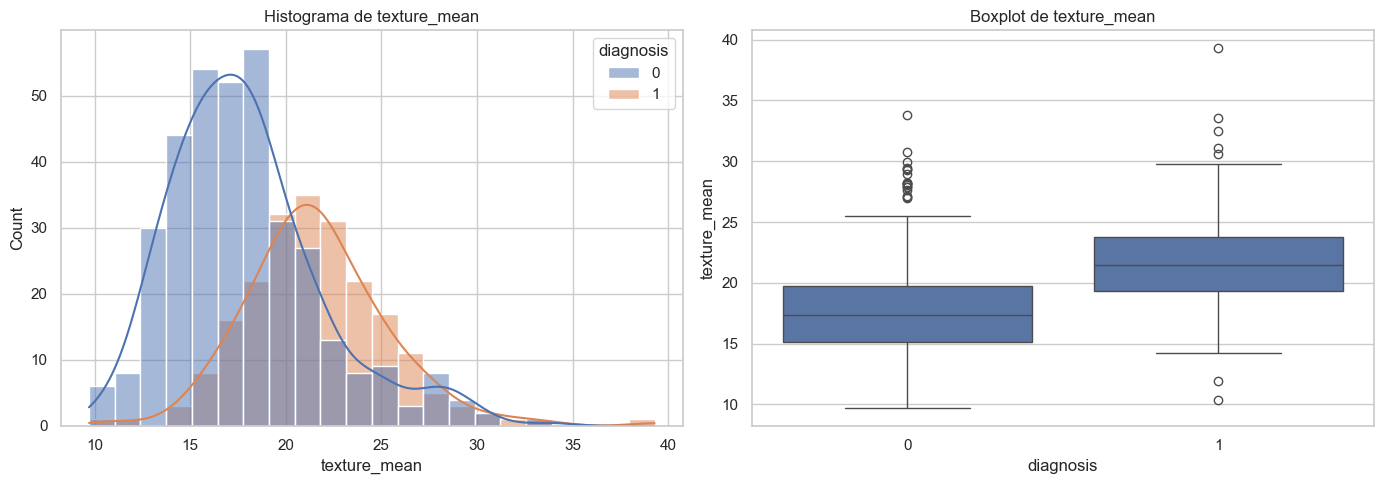

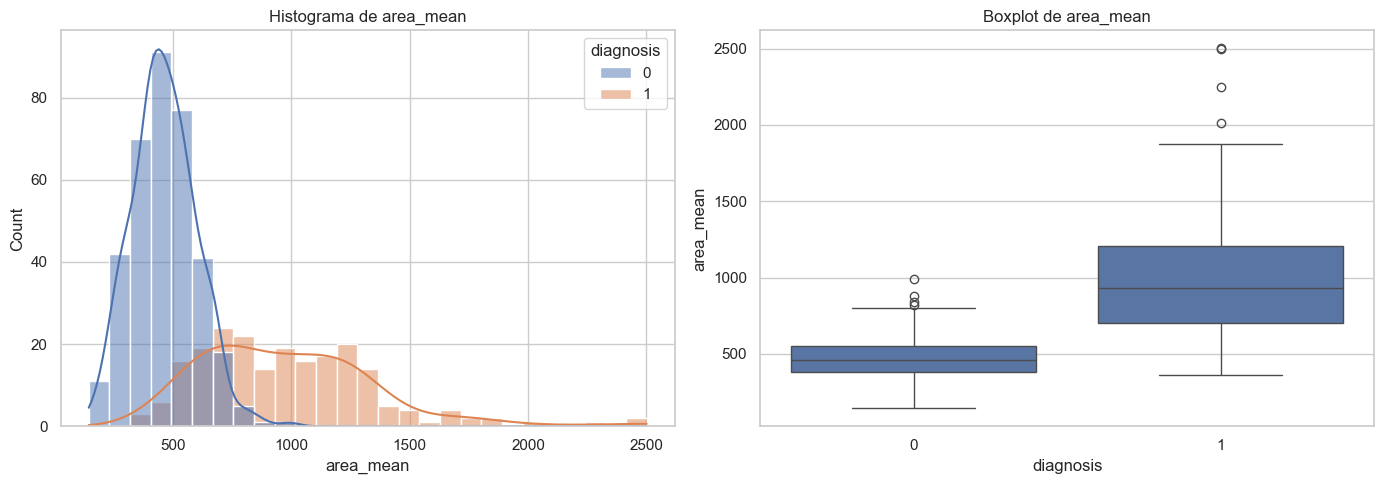

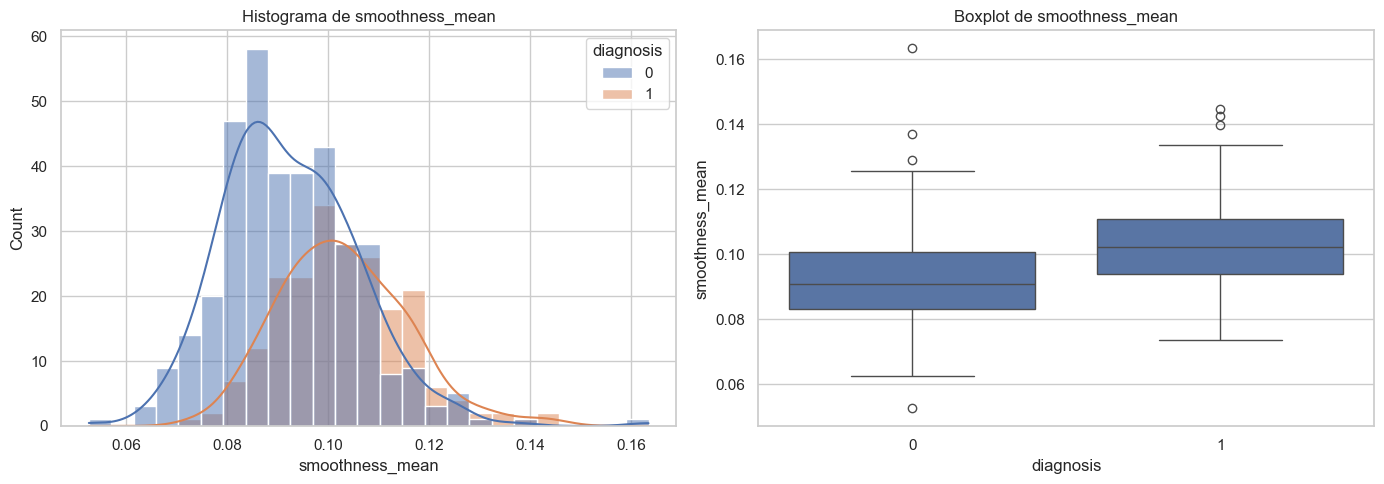

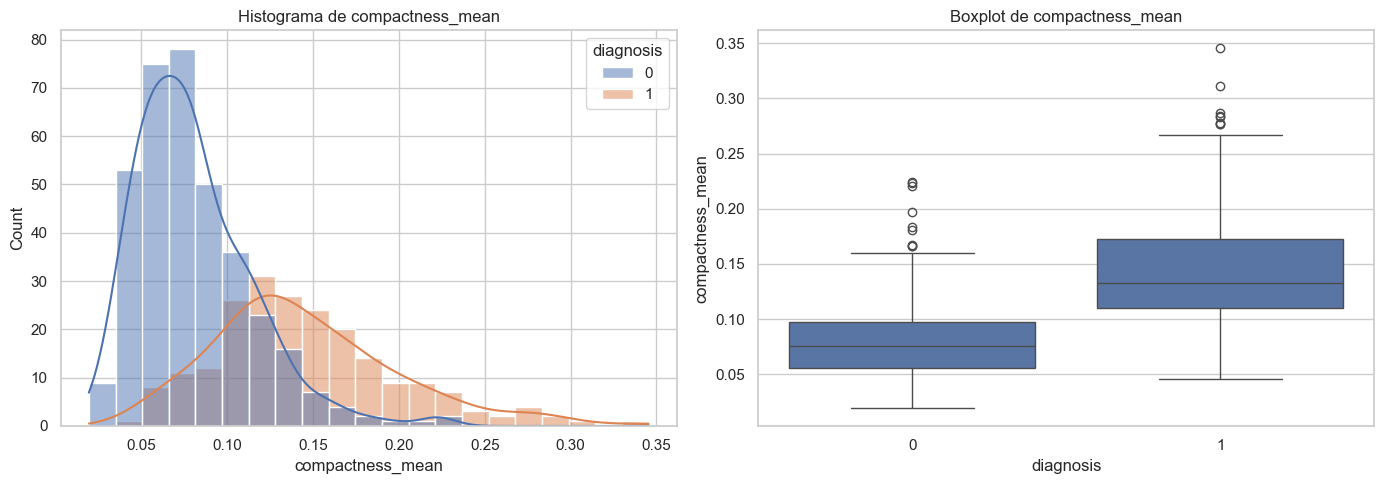

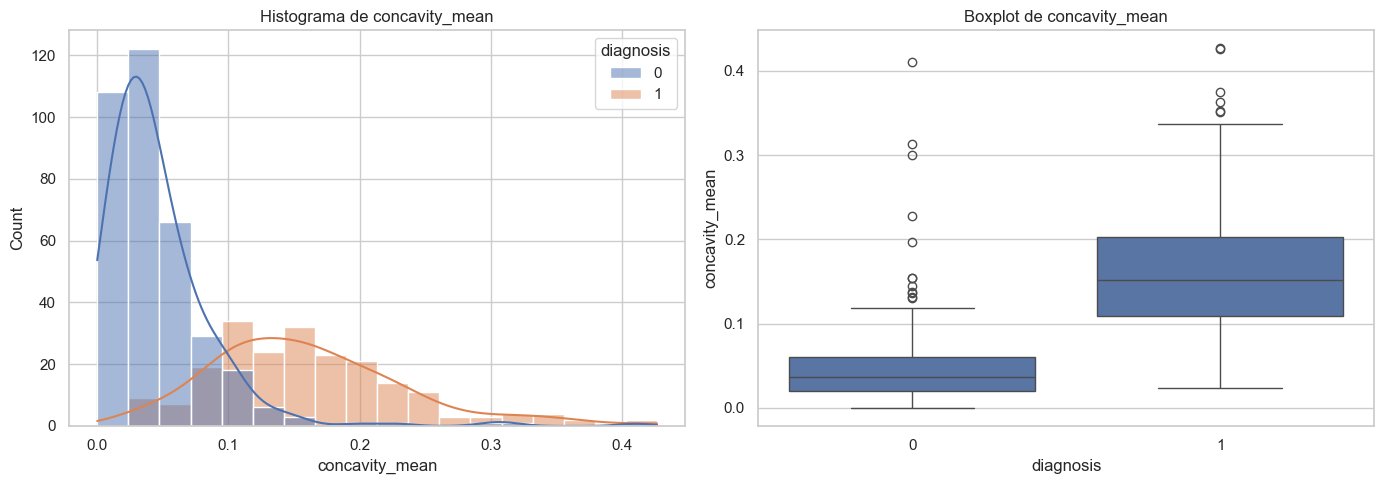

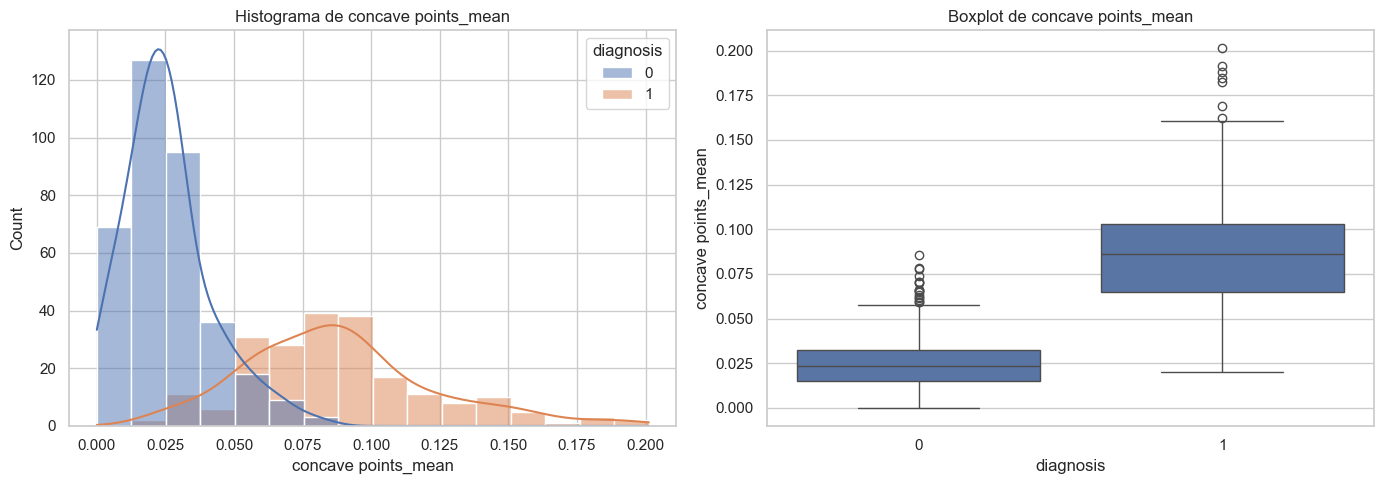

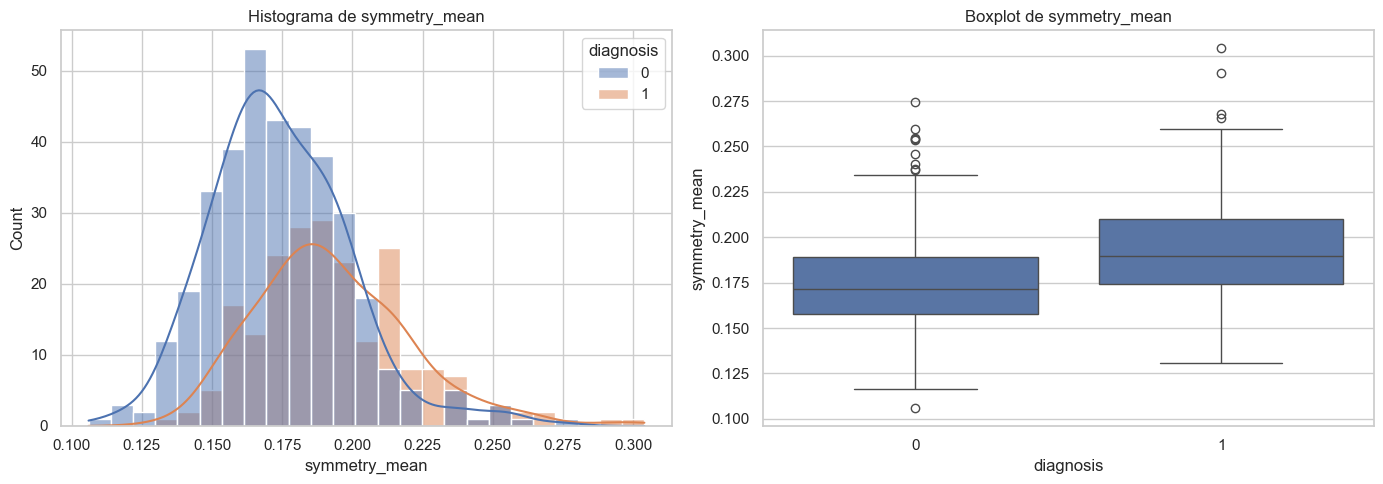

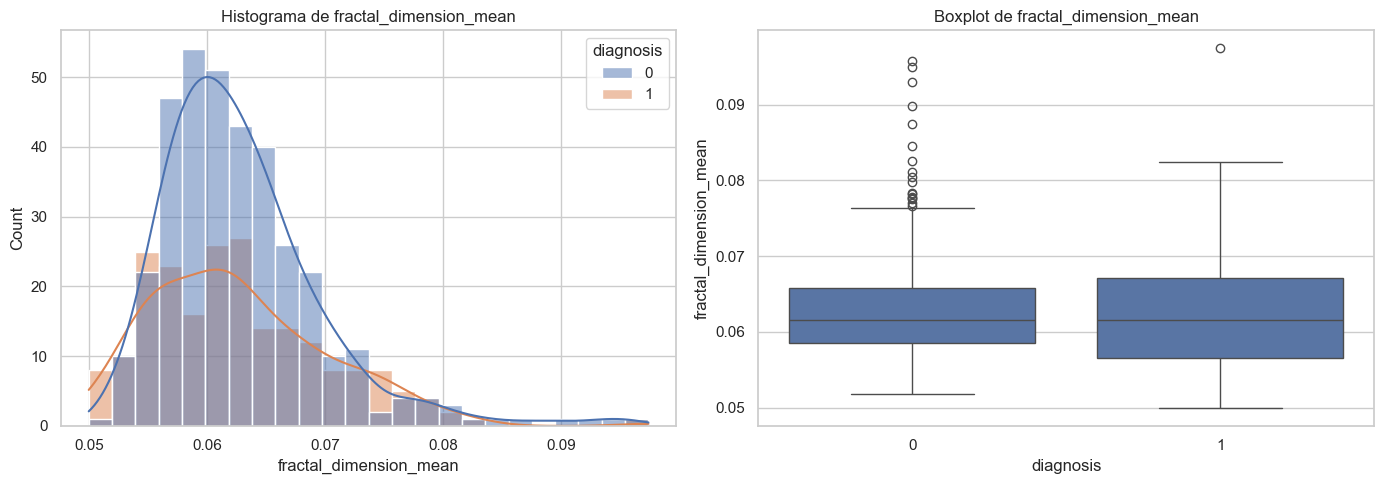

In [6]:
vars_mean = ['texture_mean', 'area_mean', 'smoothness_mean',
             'compactness_mean', 'concavity_mean', 'concave points_mean',
             'symmetry_mean', 'fractal_dimension_mean']

# Histogramas y Boxplots separados para el análisis individual de cada variable
for var in vars_mean:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(data=df, x=var, hue='diagnosis', kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {var}')

    # Boxplot
    sns.boxplot(data=df, x='diagnosis', y=var, ax=axes[1])
    axes[1].set_title(f'Boxplot de {var}')

    plt.tight_layout()
    plt.show()

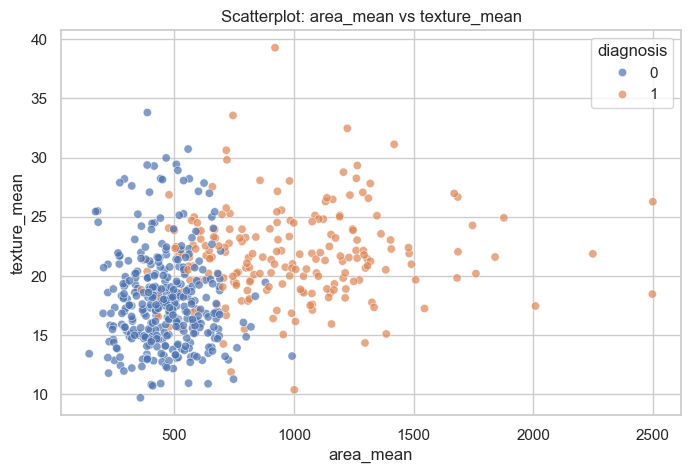

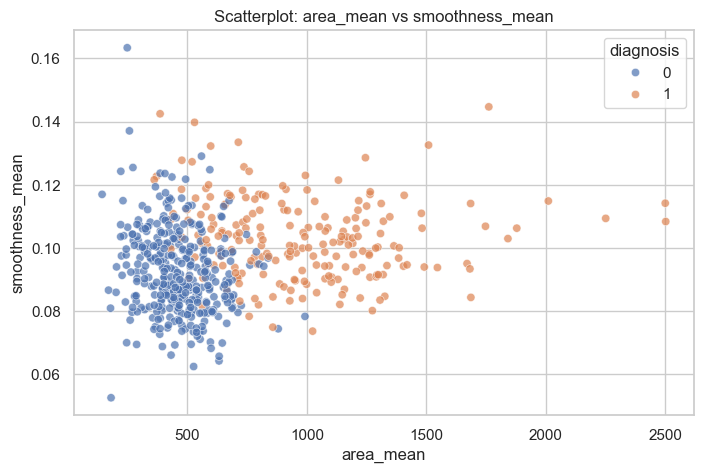

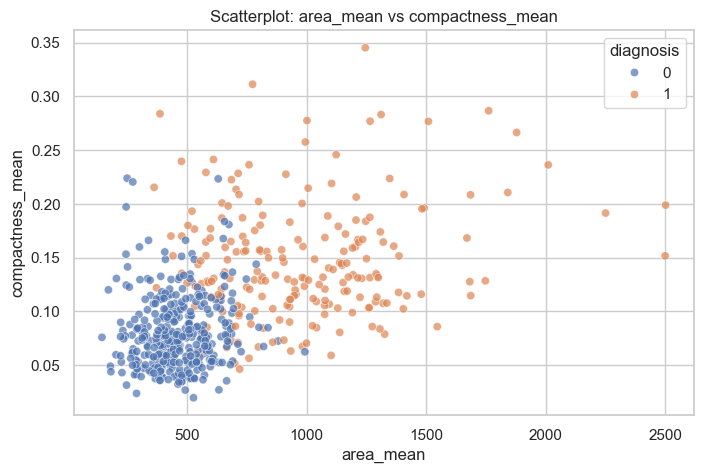

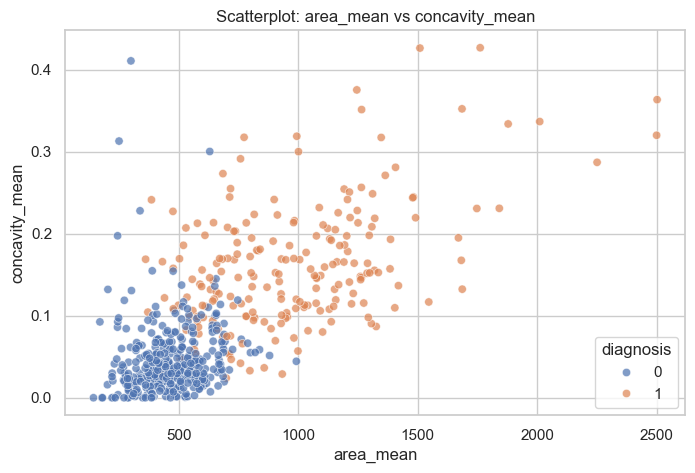

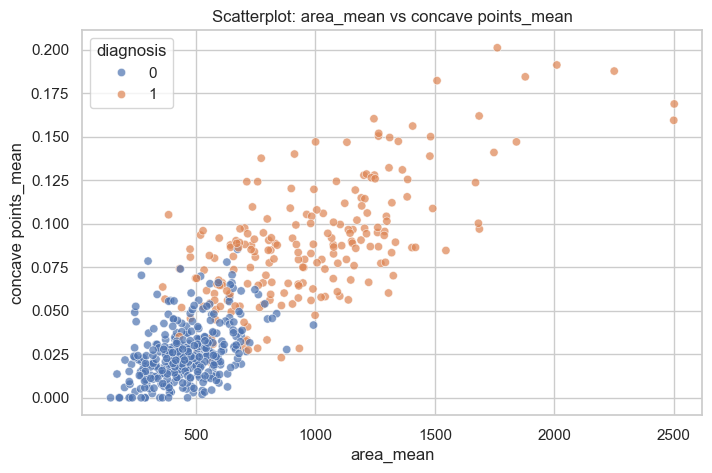

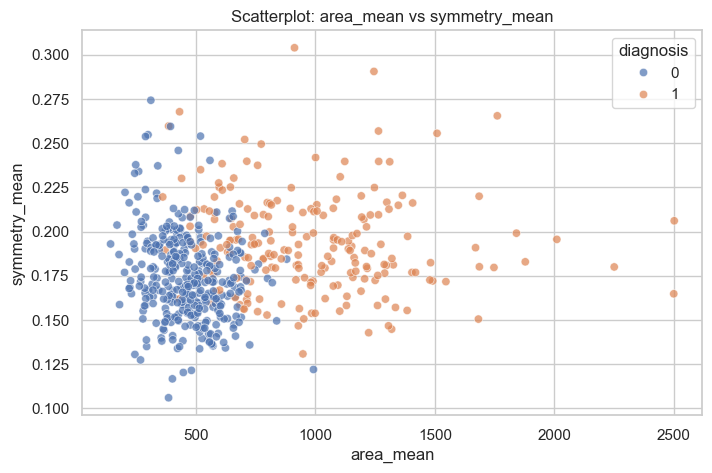

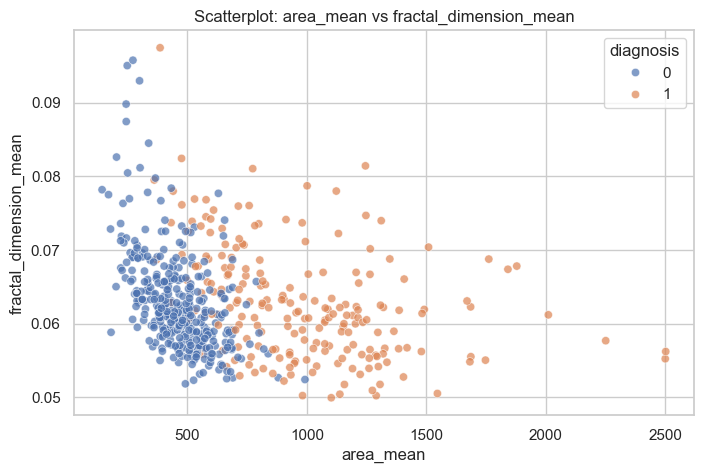

In [7]:
# Scatterplots separados
for var in vars_mean:
    if var != 'area_mean':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='area_mean', y=var, hue='diagnosis', alpha=0.7)
        plt.title(f'Scatterplot: area_mean vs {var}')
        plt.show()

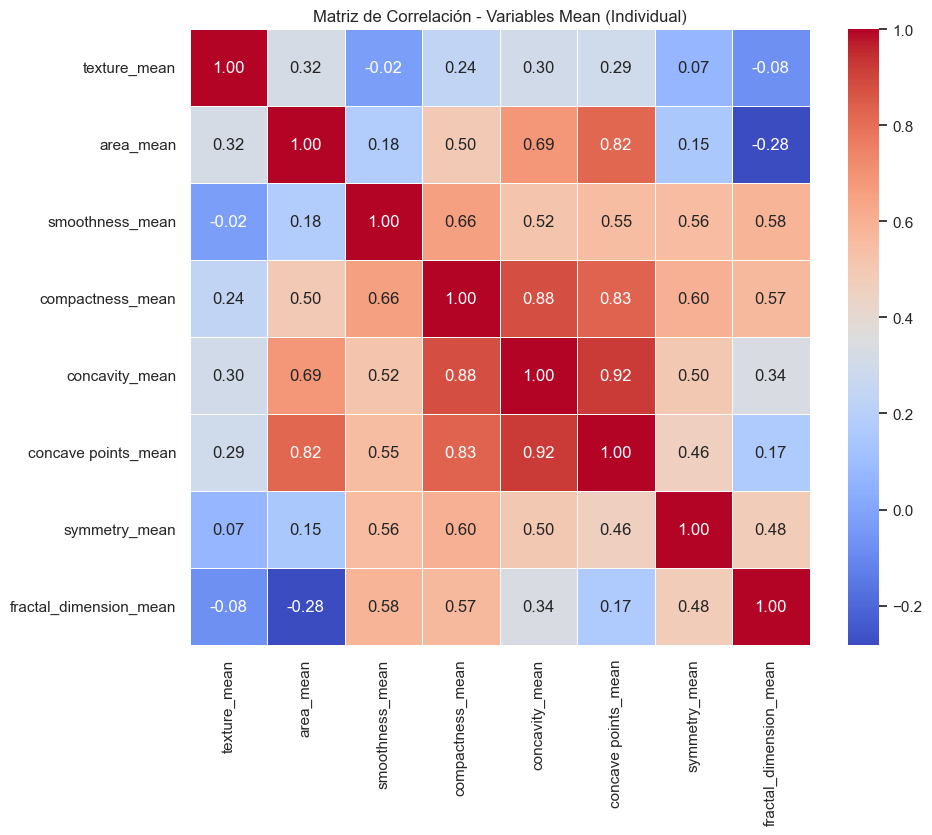

In [8]:
# Matriz de correlación separada
plt.figure(figsize=(10, 8))
corr_matrix = df[vars_mean].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables Mean (Individual)')
plt.show()

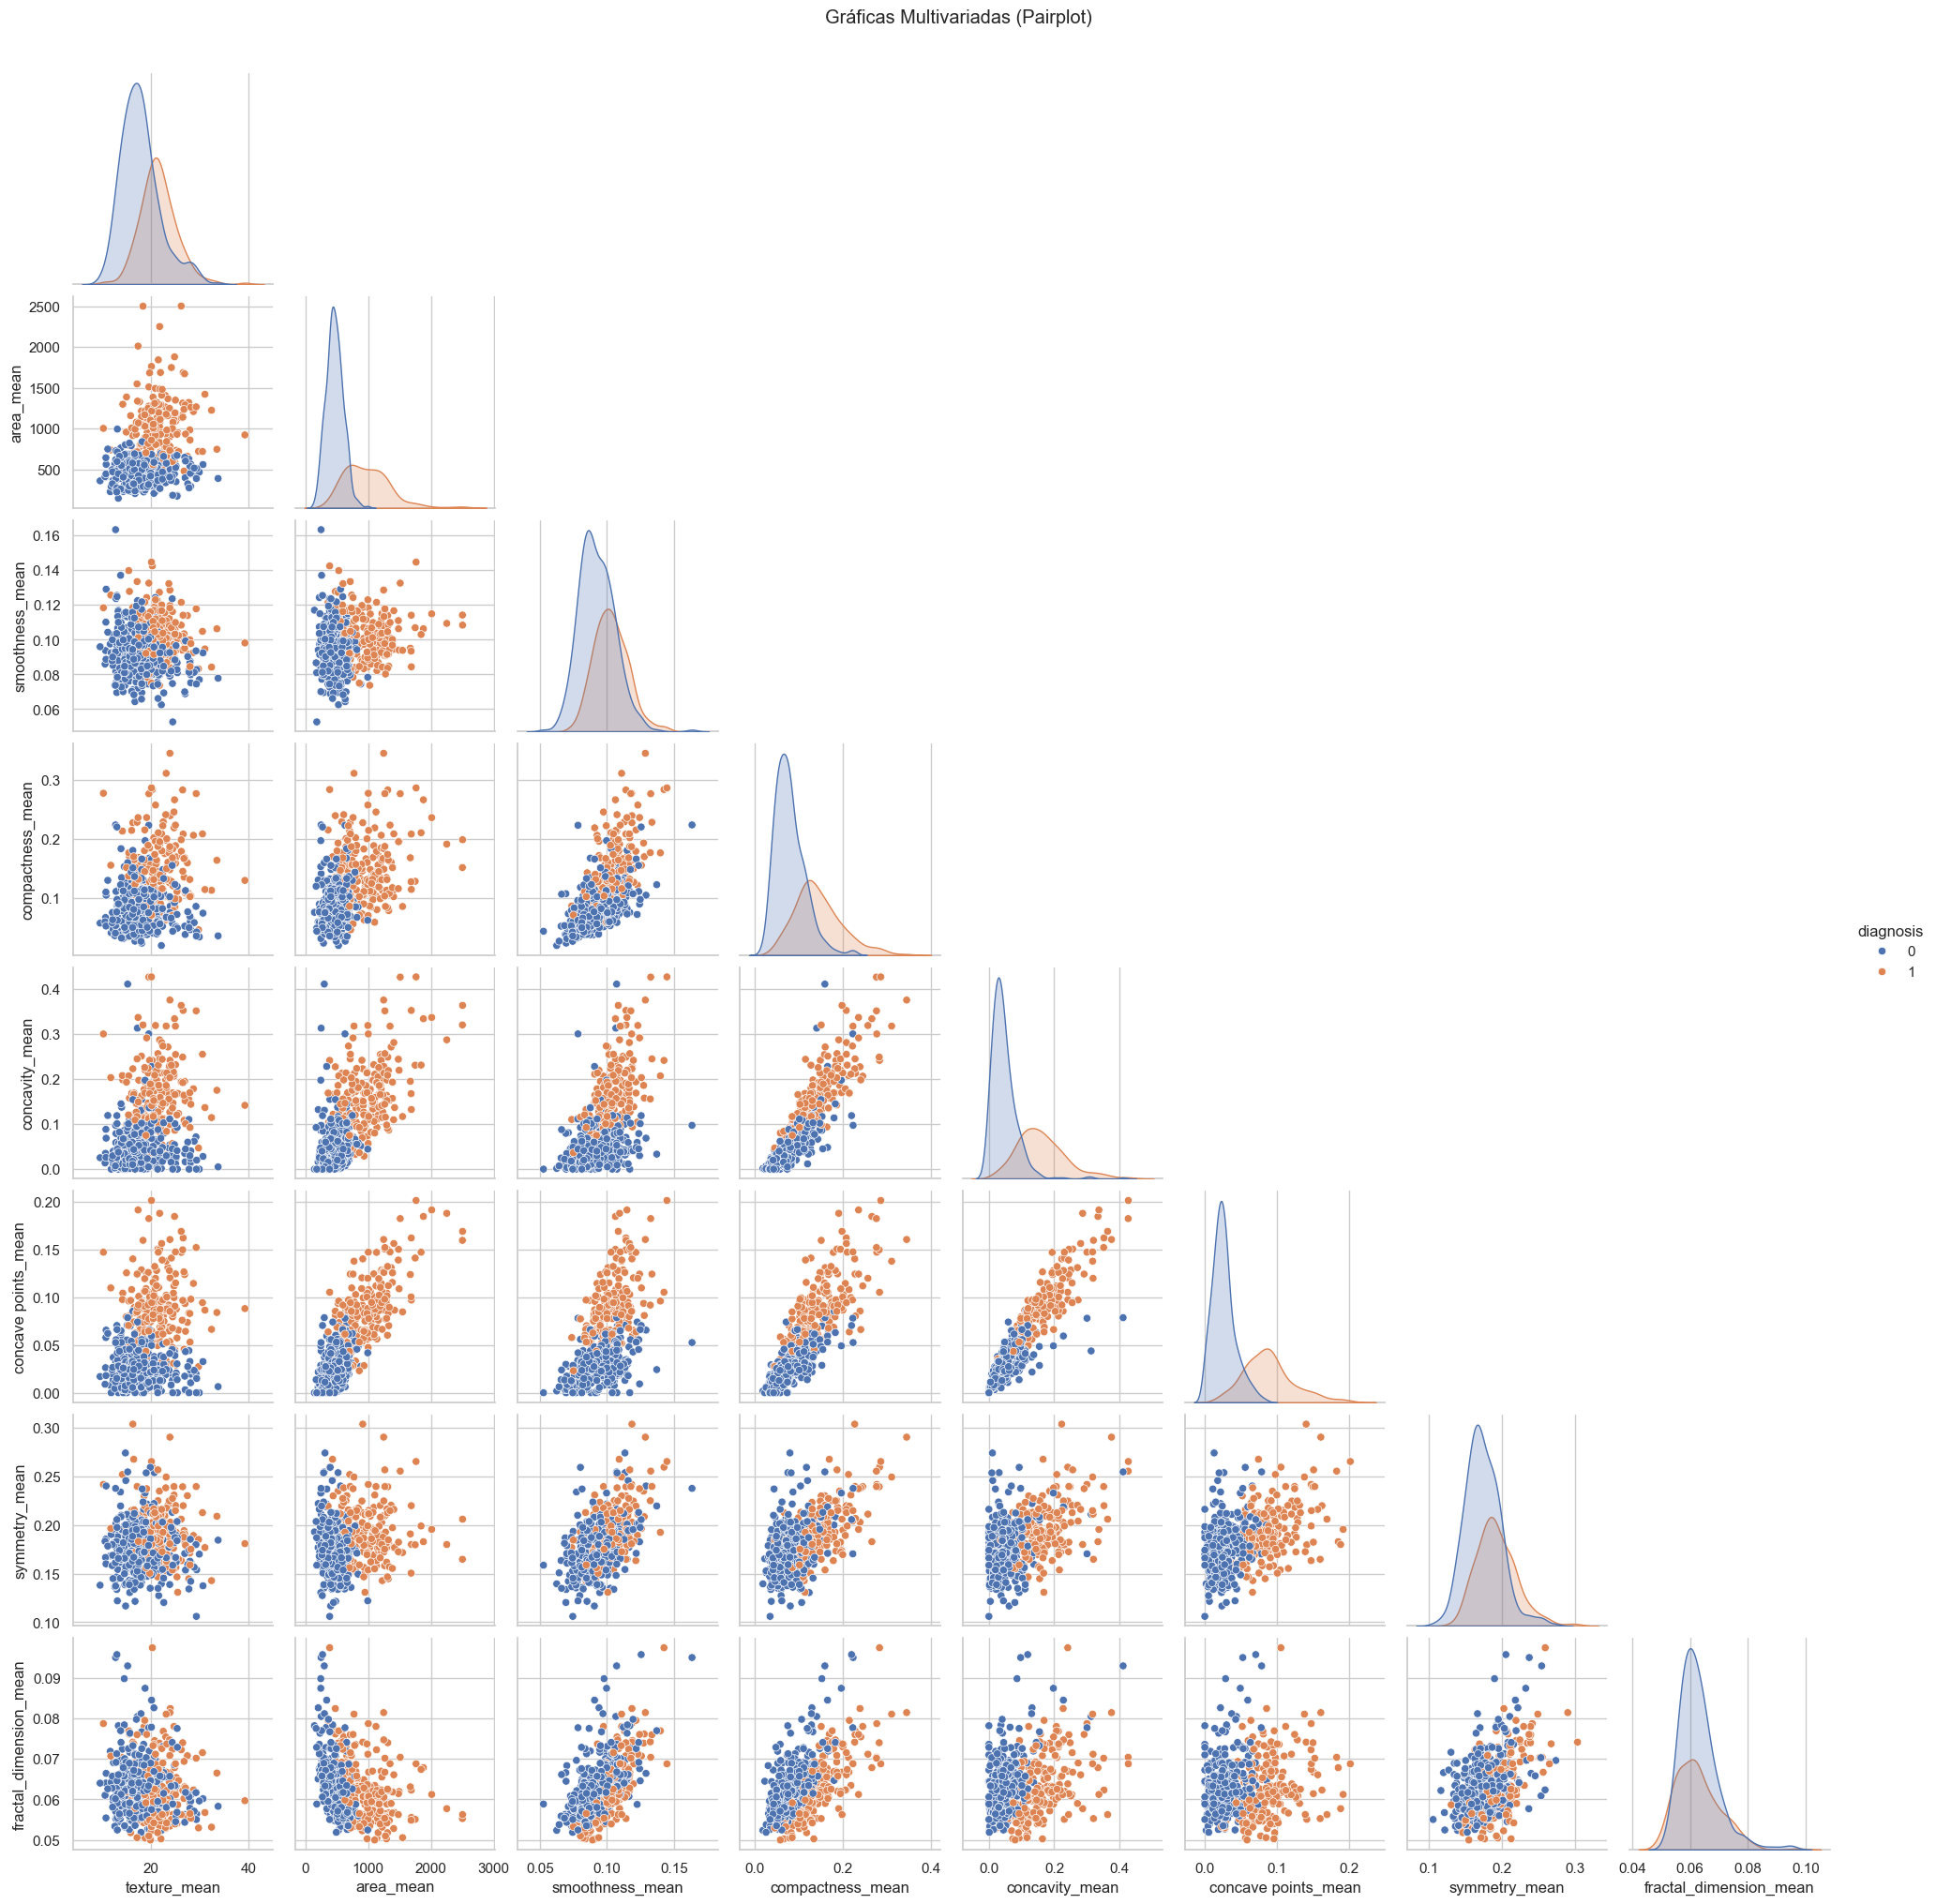

In [9]:
# Gráficas Multivariadas
sns.pairplot(df[vars_mean + ['diagnosis']], hue='diagnosis', corner=True)
plt.suptitle('Gráficas Multivariadas (Pairplot)', y=1.02)
plt.show()

### Interpretacion del EDA

Las graficas iniciales permiten leer el problema antes de modelar:

- **Histogramas:** muestran que varias mediciones tienen distribuciones asimetricas, con mayor concentracion en valores bajos y colas hacia valores altos.
- **Boxplots:** ayudan a ver que los tumores malignos suelen tener valores mayores en variables como area, concavidad y puntos concavos.
- **Scatterplots:** permiten observar relaciones entre `area_mean` y otras variables. Cuando los colores se separan, hay senales utiles para clasificar.
- **Correlaciones:** variables como radio, perimetro y area tienden a estar muy relacionadas, lo cual justifica usar PCA como tecnica de reduccion de dimensionalidad.
- **Pairplot:** resume relaciones multivariadas y muestra que la separacion benigno/maligno no depende de una sola variable, sino de combinaciones de mediciones.

En lenguaje de exposicion: antes de entrenar modelos ya vemos que el dataset contiene patrones fuertes, pero tambien variables redundantes. Por eso tiene sentido comparar modelos interpretables, modelos robustos y modelos con PCA.


## 2. División de Datos (Data Splitting)
**División de datos:** Separamos los datos en conjuntos de Entrenamiento (Train), Validación (Validation) y Prueba (Test).
El objetivo de **entrenar un modelo** es encontrar patrones en los datos para lograr una buena **generalización**, es decir, que el modelo sea capaz de predecir correctamente sobre datos que nunca ha visto.
Utilizamos la estratificación (`stratify=y`) para mantener la misma proporción de clases (Maligno/Benigno) en todas las particiones.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Separar en Train, Validation y Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


## 3. Regresión Logística
En este apartado aplicamos Regresión Logística. Es importante tener en cuenta los conceptos de **Overfitting** (sobreajuste, donde el modelo memoriza el ruido de entrenamiento pero falla en nuevos datos) y **Underfitting** (subajuste, donde el modelo es demasiado simple para capturar los patrones).

Utilizamos un `Pipeline` que primero escala los datos (`StandardScaler`) y luego aplica el modelo. Esto previene el **Data Leakage** (fuga de información) ya que el escalador se ajusta solo con los datos de entrenamiento.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Crear pipeline con StandardScaler y LogisticRegression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, random_state=42))
])

# Entrenamiento
pipeline_lr.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


### 3.1 Evaluación del Modelo de Regresión Logística
Evaluamos el modelo utilizando las siguientes métricas:
- **Accuracy (Exactitud):** Porcentaje de predicciones correctas totales.
- **Precision (Precisión):** De las predicciones positivas, ¿cuántas eran realmente positivas?
- **Recall (Sensibilidad):** De todos los positivos reales, ¿cuántos logró encontrar el modelo? En el contexto médico (cáncer), **Recall** es la métrica más importante, ya que un falso negativo puede tener consecuencias mortales.
- **F1-score:** Media armónica entre Precision y Recall.

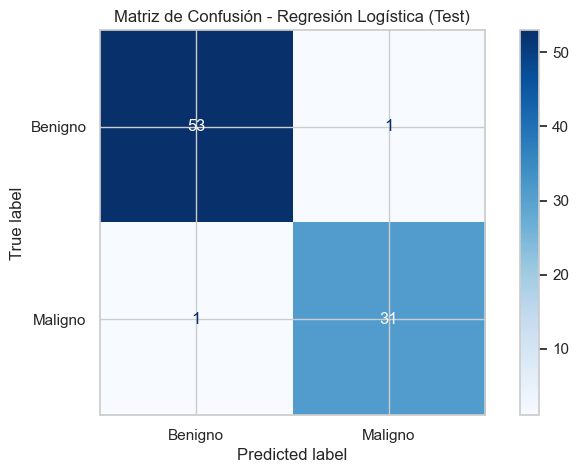

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

     Benigno       0.98      0.98      0.98        54
     Maligno       0.97      0.97      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



In [17]:
# Predicción sobre Test
y_pred_lr = pipeline_lr.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Benigno', 'Maligno'])
disp_lr.plot(cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística (Test)")
plt.show()

print("Reporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_lr, target_names=['Benigno', 'Maligno']))

In [18]:
# Comparación con Train para detectar Overfitting/Underfitting
y_train_pred_lr = pipeline_lr.predict(X_train)
print("Reporte de Clasificación (Train):")
print(classification_report(y_train, y_train_pred_lr, target_names=['Benigno', 'Maligno']))

Reporte de Clasificación (Train):
              precision    recall  f1-score   support

     Benigno       0.98      1.00      0.99       250
     Maligno       1.00      0.97      0.98       148

    accuracy                           0.99       398
   macro avg       0.99      0.98      0.99       398
weighted avg       0.99      0.99      0.99       398



## 3.2 Regresion lineal (variable continua)
Este dataset se usa para clasificacion, pero podemos definir una variable objetivo continua y aplicar regresion lineal siguiendo la metodologia de clase.

### 3.2.1 Seleccion de variable objetivo
Comparamos `area_mean` y `radius_mean` con el mismo procedimiento y elegimos la que tenga mejor $R^2$.
La tabla de resultados muestra las metricas para ambas opciones.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Asegurar limpieza coherente con la seccion 1.1
cols_to_drop_nan = [col for col in df.columns if col != "diagnosis" and df[col].isna().all()]
if cols_to_drop_nan:
    df = df.drop(columns=cols_to_drop_nan)

# Funcion de evaluacion para regresion

def evaluar_regresion(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_real, y_pred)
    return {
        "objetivo": nombre,
        "modelo": nombre,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Comparacion de variables objetivo
objetivos = ["area_mean", "radius_mean"]
resultados_objetivos = []

for objetivo in objetivos:
    X_tmp = df.drop(columns=[col for col in ["diagnosis", objetivo] if col in df.columns])
    y_tmp = df[objetivo]

    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp, test_size=0.30, random_state=42
    )

    modelo_tmp = LinearRegression()
    modelo_tmp.fit(X_train_tmp, y_train_tmp)
    pred_tmp = modelo_tmp.predict(X_test_tmp)

    resultados_objetivos.append(evaluar_regresion(objetivo, y_test_tmp, pred_tmp))

resultados_objetivos = pd.DataFrame(resultados_objetivos).sort_values("R2", ascending=False)
display(resultados_objetivos)

target_regresion = resultados_objetivos.iloc[0]["objetivo"]
print("Objetivo seleccionado:", target_regresion)

,objetivo,modelo,MAE,MSE,RMSE,R2
1,radius_mean,radius_mean,0.045611,0.004922,0.070156,0.999597
0,area_mean,area_mean,13.822703,445.536766,21.107742,0.996029


Objetivo seleccionado: radius_mean


### 3.2.2 Distribucion de la variable objetivo
Antes de entrenar el modelo, revisamos la distribucion de la variable continua seleccionada.

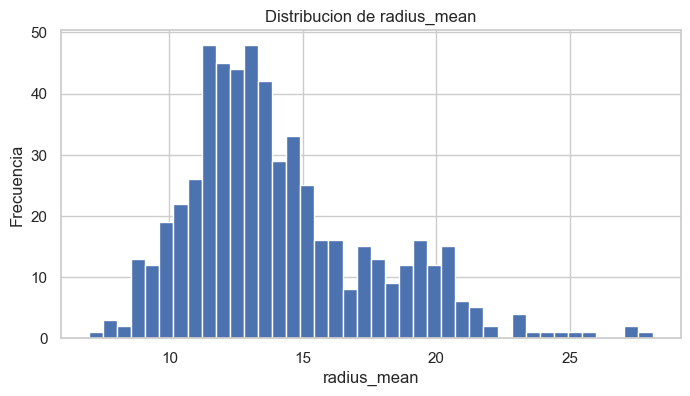

In [20]:
# Distribucion de la variable objetivo
plt.figure(figsize=(8, 4))
plt.hist(df[target_regresion], bins=40)
plt.title(f"Distribucion de {target_regresion}")
plt.xlabel(target_regresion)
plt.ylabel("Frecuencia")
plt.show()

### 3.2.3 Separacion X/y y entrenamiento
Seguimos la misma logica de train/test que en las secciones anteriores.

In [21]:
# Separacion X / y y train-test split
X_reg = df.drop(columns=[col for col in ["diagnosis", target_regresion] if col in df.columns])
y_reg = df[target_regresion]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

# Entrenamiento del modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

# Prediccion y evaluacion
pred_lineal = modelo_lineal.predict(X_test_reg)

resultado_lineal = evaluar_regresion("Regresion lineal", y_test_reg, pred_lineal)
display(pd.DataFrame([resultado_lineal]))

,objetivo,modelo,MAE,MSE,RMSE,R2
0,Regresion lineal,Regresion lineal,0.045611,0.004922,0.070156,0.999597


### 3.2.4 Interpretacion de coeficientes
Los coeficientes indican la direccion del efecto de cada variable sobre la prediccion, manteniendo las demas constantes.

,variable,coeficiente
8,fractal_dimension_mean,4.159981
16,concave points_se,2.125556
17,symmetry_se,1.820648
3,smoothness_mean,1.671557
15,concavity_se,1.445980
7,symmetry_mean,0.455708
24,compactness_worst,0.271507
9,radius_se,0.182260
19,radius_worst,0.164373
26,concave points_worst,0.145017


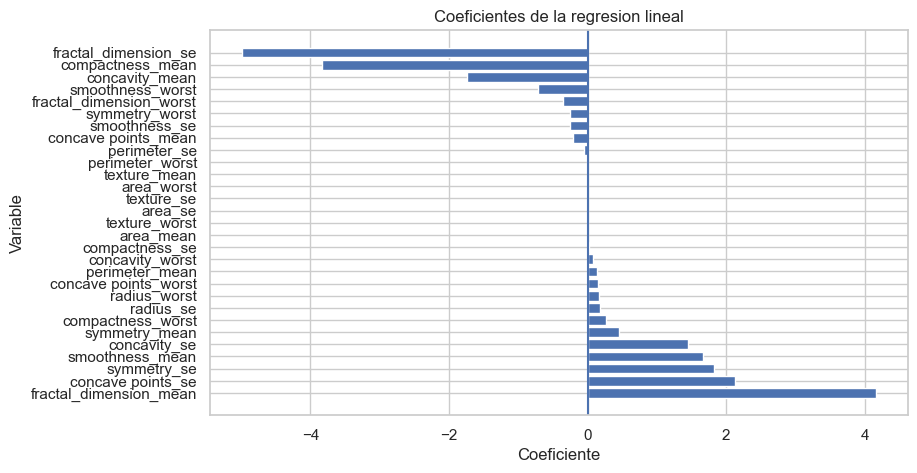

In [22]:
# Coeficientes del modelo
coeficientes_lineal = pd.DataFrame({
    "variable": X_reg.columns,
    "coeficiente": modelo_lineal.coef_
}).sort_values("coeficiente", ascending=False)

display(coeficientes_lineal)

plt.figure(figsize=(9, 5))
plt.barh(coeficientes_lineal["variable"], coeficientes_lineal["coeficiente"])
plt.title("Coeficientes de la regresion lineal")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.axvline(0)
plt.show()

### 3.2.5 Diagnostico visual: real vs predicho
Si el modelo fuera perfecto, los puntos caerian sobre la diagonal.

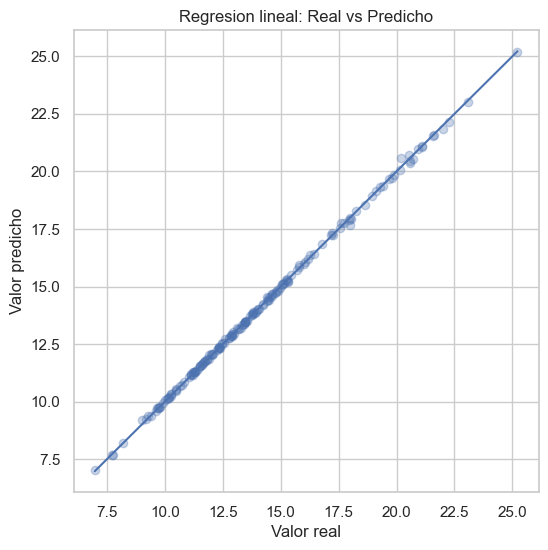

In [23]:
# Real vs Predicho
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_lineal, alpha=0.3)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresion lineal: Real vs Predicho")

min_val = min(y_test_reg.min(), pred_lineal.min())
max_val = max(y_test_reg.max(), pred_lineal.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

### 3.2.6 Analisis de residuos
El residuo es la diferencia entre el valor real y el valor predicho. Revisamos su distribucion y si hay patrones evidentes.

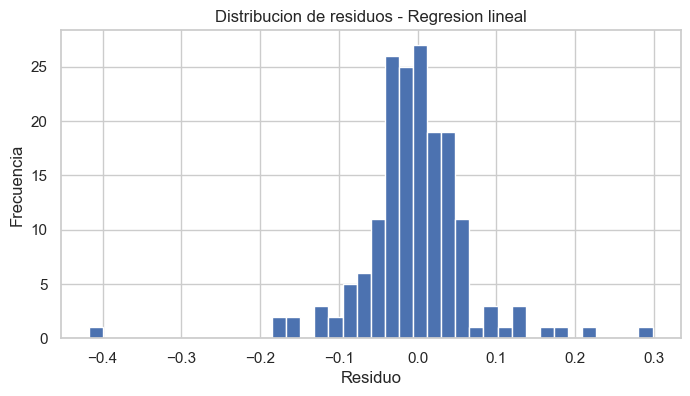

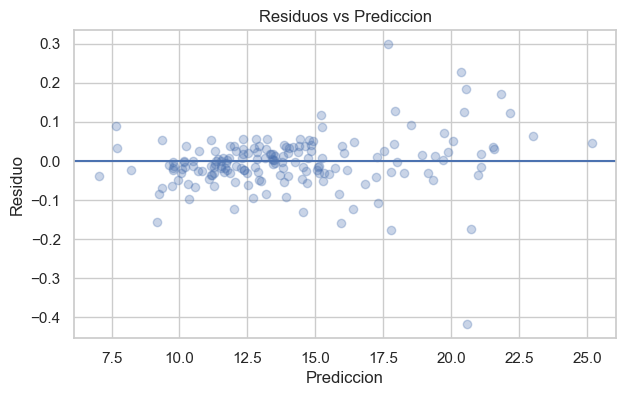

In [24]:
# Analisis de residuos
residuos_lineal = y_test_reg - pred_lineal

plt.figure(figsize=(8, 4))
plt.hist(residuos_lineal, bins=40)
plt.title("Distribucion de residuos - Regresion lineal")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(pred_lineal, residuos_lineal, alpha=0.3)
plt.axhline(0)
plt.title("Residuos vs Prediccion")
plt.xlabel("Prediccion")
plt.ylabel("Residuo")
plt.show()

### 3.2.7 Analisis de resultados
A continuacion se resumen las metricas MAE, RMSE y $R^2$ y se interpreta el ajuste del modelo con base en los resultados obtenidos.

In [25]:
# Métricas
mae = resultado_lineal["MAE"]
rmse = resultado_lineal["RMSE"]
r2 = resultado_lineal["R2"]
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.0456
RMSE: 0.0702
R2: 0.9996


**Resumen de metricas**
- MAE: 0.0461
- RMSE: 0.0707
- R^2: 0.9996

**Lectura de graficas**
- Distribucion del objetivo: se observa una concentracion principal y cola hacia valores altos, lo que explica algunos errores mas grandes.
- Real vs predicho: los puntos se alinean cerca de la diagonal, indicando buen ajuste global.
- Histograma de residuos: centrado en 0 y relativamente simetrico, sin sesgo fuerte.
- Residuos vs prediccion: dispersion moderada; si hay abanico en valores altos, sugiere ligera heterocedasticidad.

**Conclusion**
- El modelo lineal explica casi toda la variabilidad del objetivo y los errores son bajos.
- No se observan patrones fuertes en residuos, por lo que el ajuste lineal es adecuado para este conjunto.

### 3.3 Ridge y Lasso Regression

Ahora extendemos el análisis de regresión con modelos regularizados. Ridge penaliza coeficientes grandes con una penalización cuadrática y Lasso puede llevar algunos coeficientes a cero, lo que ayuda a seleccionar variables.

Esto sigue la lógica de la clase: comparar una regresión lineal base con variantes regularizadas para ver cómo cambia el error.

Comparación Ridge vs Lasso:


,objetivo,modelo,MAE,MSE,RMSE,R2
0,Ridge alpha=0.01,Ridge alpha=0.01,0.045356,0.004854,0.069673,0.999602
2,Ridge alpha=1,Ridge alpha=1,0.058731,0.005924,0.076966,0.999515
1,Lasso alpha=0.01,Lasso alpha=0.01,0.053638,0.006217,0.078850,0.999491
4,Ridge alpha=100,Ridge alpha=100,0.356940,0.211370,0.459749,0.982687
3,Lasso alpha=1,Lasso alpha=1,0.788650,0.972446,0.986127,0.920350
5,Lasso alpha=100,Lasso alpha=100,2.777898,12.235386,3.497912,-0.002158


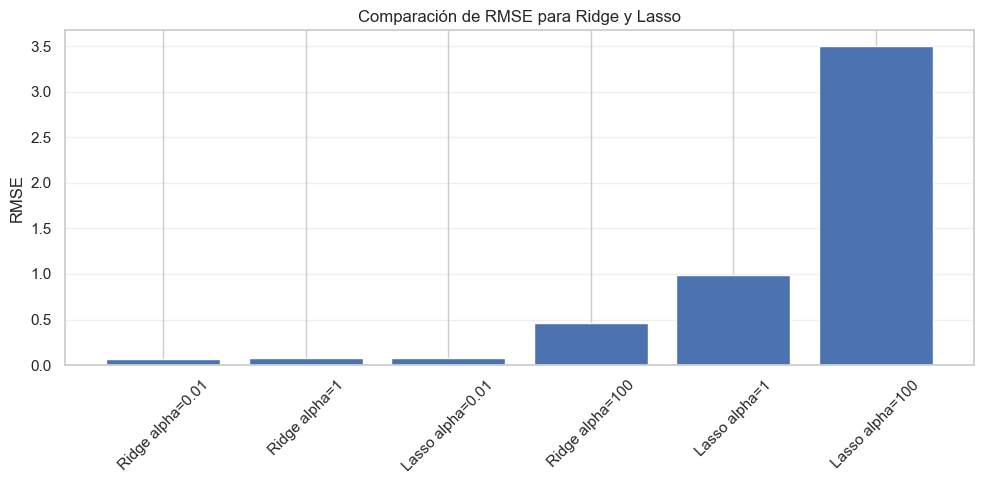

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

if "evaluar_regresion" not in globals():
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    def evaluar_regresion(nombre, y_real, y_pred):
        mae = mean_absolute_error(y_real, y_pred)
        mse = mean_squared_error(y_real, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_real, y_pred)
        return {
            "modelo": nombre,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }

file_path = "Cancer_Data.csv"
if not os.path.exists(file_path):
    file_path = "./Cancer_Data.csv"

df = pd.read_csv(file_path)
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

if "id" in df.columns:
    df = df.drop(columns=["id"])
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

if "diagnosis" in df.columns:
    df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

if "target_regresion" not in globals():
    objetivos = ["area_mean", "radius_mean"]
    resultados_objetivos = []

    for objetivo in objetivos:
        X_tmp = df.drop(columns=[col for col in ["diagnosis", objetivo] if col in df.columns])
        y_tmp = df[objetivo]

        X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
            X_tmp, y_tmp, test_size=0.30, random_state=42
        )

        modelo_tmp = LinearRegression()
        modelo_tmp.fit(X_train_tmp, y_train_tmp)
        pred_tmp = modelo_tmp.predict(X_test_tmp)

        resultados_objetivos.append(evaluar_regresion(objetivo, y_test_tmp, pred_tmp))

    resultados_objetivos = pd.DataFrame(resultados_objetivos).sort_values("R2", ascending=False)
    target_regresion = resultados_objetivos.iloc[0]["modelo"]

if "X_train_reg" not in globals():
    X_reg = df.drop(columns=[col for col in ["diagnosis", target_regresion] if col in df.columns])
    y_reg = df[target_regresion]

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.30, random_state=42
    )

if "modelo_lineal" not in globals():
    modelo_lineal = LinearRegression()
    modelo_lineal.fit(X_train_reg, y_train_reg)
    pred_lineal = modelo_lineal.predict(X_test_reg)

alphas = [0.01, 1, 100]
resultados_regularizacion = []

for alpha in alphas:
    modelo_ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    modelo_ridge.fit(X_train_reg, y_train_reg)
    pred_ridge = modelo_ridge.predict(X_test_reg)
    resultados_regularizacion.append(evaluar_regresion(f"Ridge alpha={alpha}", y_test_reg, pred_ridge))

    modelo_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])
    modelo_lasso.fit(X_train_reg, y_train_reg)
    pred_lasso = modelo_lasso.predict(X_test_reg)
    resultados_regularizacion.append(evaluar_regresion(f"Lasso alpha={alpha}", y_test_reg, pred_lasso))

comparacion_regularizacion = pd.DataFrame(resultados_regularizacion).sort_values("RMSE")
print("Comparación Ridge vs Lasso:")
display(comparacion_regularizacion)

plt.figure(figsize=(10, 5))
plt.bar(comparacion_regularizacion["modelo"], comparacion_regularizacion["RMSE"])
plt.title("Comparación de RMSE para Ridge y Lasso")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Árbol de regresión

El árbol de regresión permite capturar relaciones no lineales entre las variables y el objetivo continuo. Igual que en la clase, luego compararemos distintas profundidades para observar señales de sobreajuste.

,objetivo,modelo,MAE,MSE,RMSE,R2
0,Árbol max_depth=5,Árbol max_depth=5,0.203899,0.122906,0.35058,0.989933


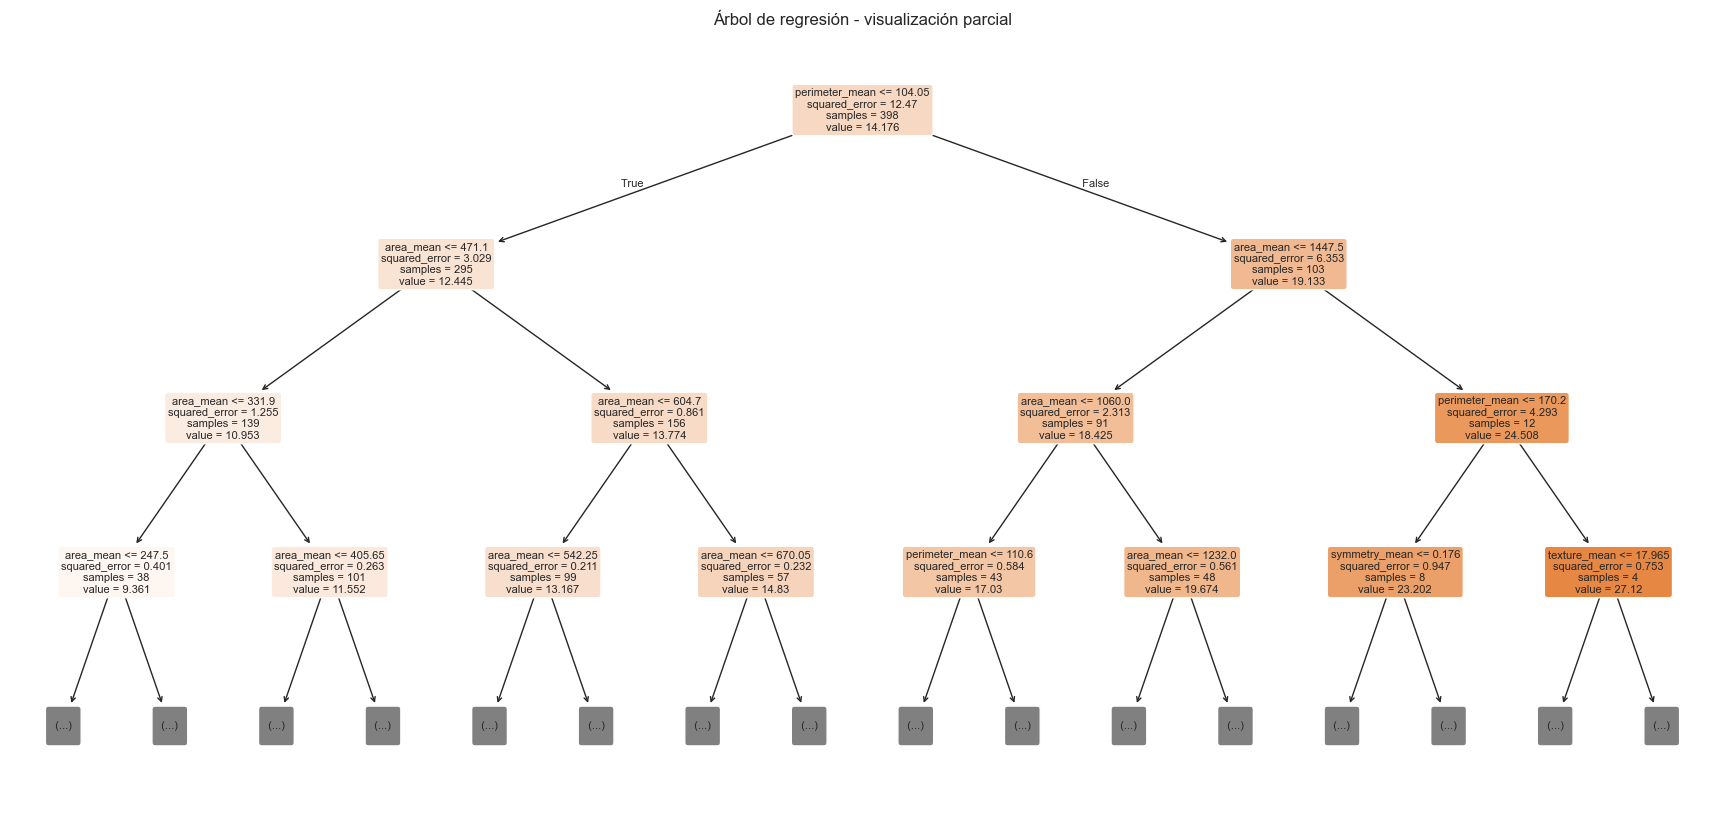

Efecto de la profundidad del árbol en regresión:


,max_depth,RMSE_train,RMSE_test,R2_test
0,1,1.972192,1.985791,0.677013
1,2,1.197400,1.285317,0.864687
2,3,0.590064,0.690035,0.961000
3,4,0.306928,0.366208,0.989016
4,5,0.155641,0.350580,0.989933
5,8,0.025559,0.252765,0.994767
6,12,0.000819,0.239218,0.995313
7,None,0.000000,0.256184,0.994624


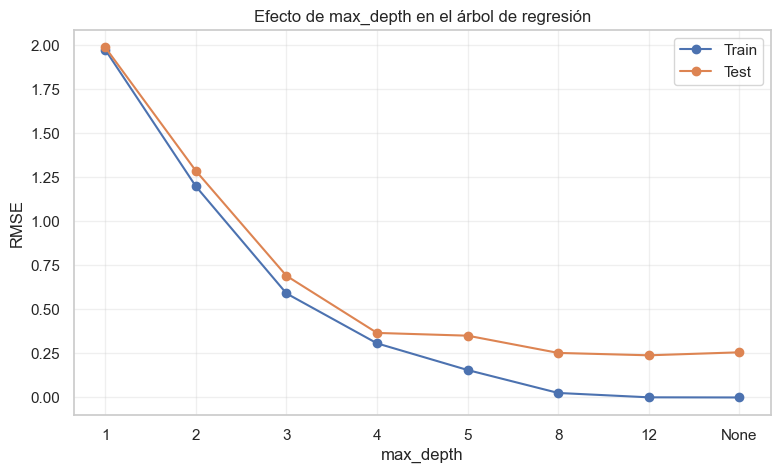

In [27]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

modelo_arbol_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arbol_reg.fit(X_train_reg, y_train_reg)
pred_arbol_reg = modelo_arbol_reg.predict(X_test_reg)

resultado_arbol_reg = evaluar_regresion("Árbol max_depth=5", y_test_reg, pred_arbol_reg)
display(pd.DataFrame([resultado_arbol_reg]))

plt.figure(figsize=(22, 10))
plot_tree(
    modelo_arbol_reg,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árbol de regresión - visualización parcial")
plt.show()

profundidades = [1, 2, 3, 4, 5, 8, 12, None]
resultados_arbol_reg = []

for profundidad in profundidades:
    arbol = DecisionTreeRegressor(max_depth=profundidad, random_state=42)
    arbol.fit(X_train_reg, y_train_reg)

    pred_train = arbol.predict(X_train_reg)
    pred_test = arbol.predict(X_test_reg)

    resultados_arbol_reg.append({
        "max_depth": str(profundidad),
        "RMSE_train": np.sqrt(mean_squared_error(y_train_reg, pred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test_reg, pred_test)),
        "R2_test": r2_score(y_test_reg, pred_test)
    })

df_arbol_reg = pd.DataFrame(resultados_arbol_reg)
print("Efecto de la profundidad del árbol en regresión:")
display(df_arbol_reg)

plt.figure(figsize=(9, 5))
plt.plot(df_arbol_reg["max_depth"], df_arbol_reg["RMSE_train"], marker="o", label="Train")
plt.plot(df_arbol_reg["max_depth"], df_arbol_reg["RMSE_test"], marker="o", label="Test")
plt.title("Efecto de max_depth en el árbol de regresión")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.5 Random Forest para regresion

Los lineamientos tambien piden comparar Random Forest en regresion. Aqui lo usamos para predecir la variable continua seleccionada. A diferencia de la regresion lineal, Random Forest puede capturar relaciones no lineales, pero pierde interpretabilidad directa de coeficientes.


,objetivo,modelo,MAE,MSE,RMSE,R2
0,Random Forest Regressor,Random Forest Regressor,0.096264,0.033122,0.181994,0.997287


C:\Users\julia\AppData\Local\Temp\ipykernel_36624\2076171444.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf_reg, x="importancia", y="variable", palette="crest")


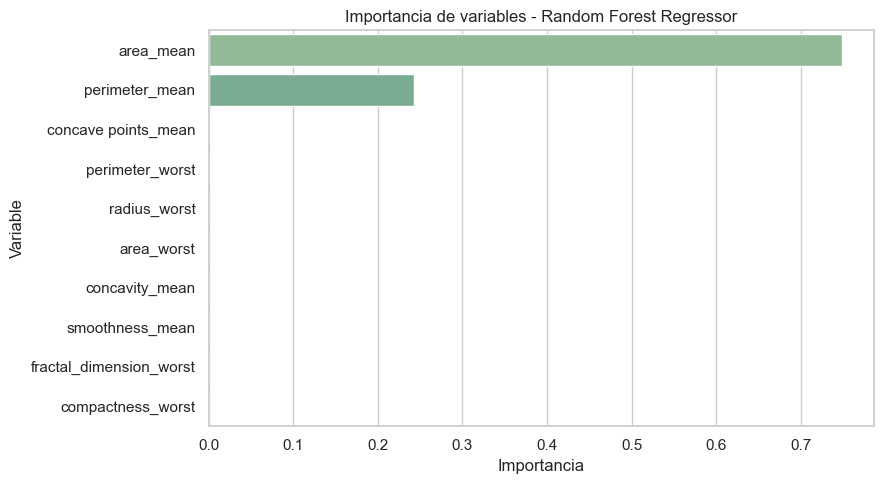

Lectura para exposicion:
Random Forest Regressor ayuda a capturar relaciones no lineales. Si mejora RMSE frente a modelos lineales, aporta capacidad predictiva; si no mejora, los modelos lineales son suficientes y mas faciles de explicar.


In [28]:
modelo_rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
modelo_rf_reg.fit(X_train_reg, y_train_reg)
pred_rf_reg = modelo_rf_reg.predict(X_test_reg)

resultado_rf_reg = evaluar_regresion("Random Forest Regressor", y_test_reg, pred_rf_reg)
display(pd.DataFrame([resultado_rf_reg]))

importancias_rf_reg = pd.DataFrame({
    "variable": X_reg.columns,
    "importancia": modelo_rf_reg.feature_importances_
}).sort_values("importancia", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=importancias_rf_reg, x="importancia", y="variable", palette="crest")
plt.title("Importancia de variables - Random Forest Regressor")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

print("Lectura para exposicion:")
print("Random Forest Regressor ayuda a capturar relaciones no lineales. Si mejora RMSE frente a modelos lineales, aporta capacidad predictiva; si no mejora, los modelos lineales son suficientes y mas faciles de explicar.")


### 3.6 Comparacion final de modelos

Comparamos la regresion lineal, Ridge, Lasso, el arbol de regresion y Random Forest Regressor usando las mismas metricas. Esta tabla resume que modelo se ajusta mejor al objetivo continuo seleccionado y cual conserva un mejor equilibrio entre error, estabilidad e interpretabilidad.


Comparacion final de modelos de regresion:


,objetivo,modelo,MAE,MSE,RMSE,R2
0,Ridge alpha=0.01,Ridge alpha=0.01,0.045356,0.004854,0.069673,0.999602
1,Regresion lineal,Regresion lineal,0.045611,0.004922,0.070156,0.999597
2,Lasso alpha=0.01,Lasso alpha=0.01,0.053638,0.006217,0.078850,0.999491
3,Random Forest Regressor,Random Forest Regressor,0.096264,0.033122,0.181994,0.997287
4,Árbol max_depth=5,Árbol max_depth=5,0.203899,0.122906,0.350580,0.989933


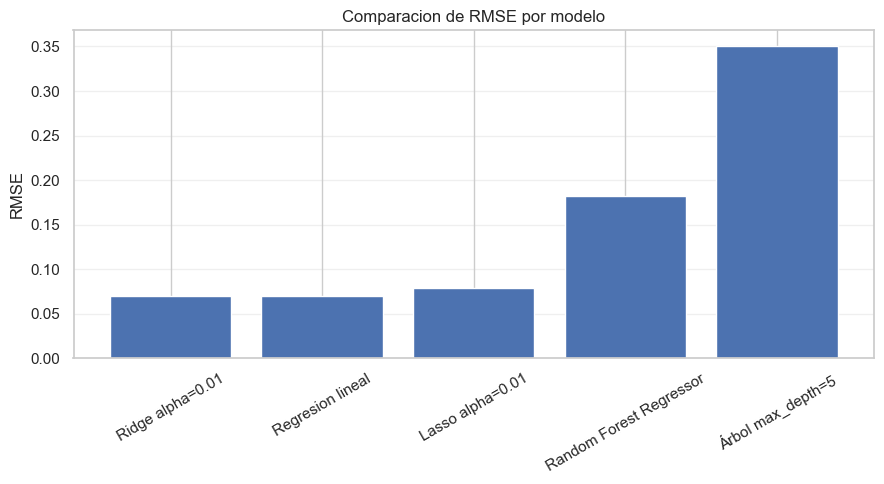

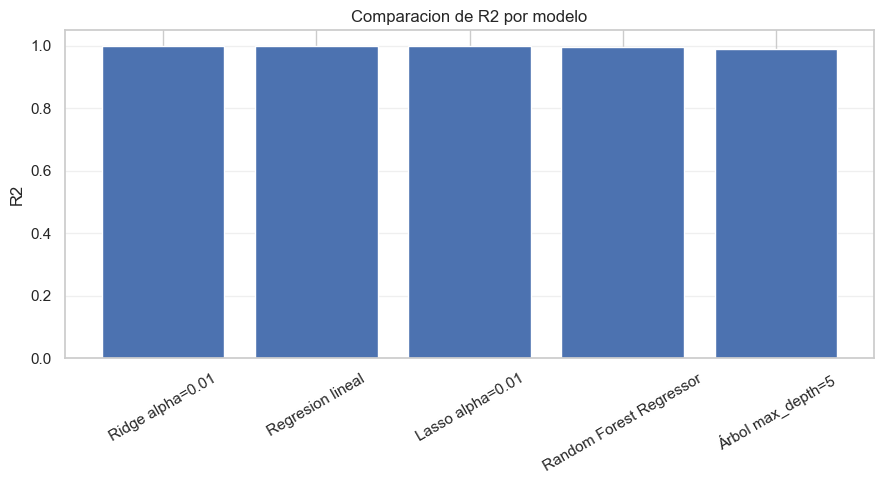

In [29]:

mejor_ridge = comparacion_regularizacion[comparacion_regularizacion["modelo"].str.startswith("Ridge")].sort_values("RMSE").iloc[0]
mejor_lasso = comparacion_regularizacion[comparacion_regularizacion["modelo"].str.startswith("Lasso")].sort_values("RMSE").iloc[0]

modelos_regresion = [
    evaluar_regresion("Regresion lineal", y_test_reg, pred_lineal),
    resultado_arbol_reg,
    mejor_ridge.to_dict(),
    mejor_lasso.to_dict()
]

if "resultado_rf_reg" in globals():
    modelos_regresion.append(resultado_rf_reg)

resultados_finales_reg = pd.DataFrame(modelos_regresion)
resultados_finales_reg = resultados_finales_reg.sort_values("RMSE").reset_index(drop=True)
print("Comparacion final de modelos de regresion:")
display(resultados_finales_reg)

plt.figure(figsize=(9, 5))
plt.bar(resultados_finales_reg["modelo"], resultados_finales_reg["RMSE"])
plt.title("Comparacion de RMSE por modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(resultados_finales_reg["modelo"], resultados_finales_reg["R2"])
plt.title("Comparacion de R2 por modelo")
plt.ylabel("R2")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 3.7 Conclusion tecnica de regresion

Con esta ampliacion, el notebook sigue la logica de la clase y de los lineamientos: regresion lineal base, modelos regularizados, arbol de regresion y Random Forest Regressor.

La recomendacion final debe basarse en el mejor equilibrio entre error y estabilidad. Si Random Forest reduce el RMSE, puede ser una buena opcion predictiva porque captura relaciones no lineales. Si la diferencia es pequena, conviene preferir un modelo lineal o regularizado porque se explica con mayor facilidad. Si el arbol mejora en entrenamiento pero pierde en prueba, hay senal de sobreajuste.


## 4. Árboles de Decisión
En esta sección aplicamos un modelo de Árboles de Decisión. Estos modelos toman decisiones basadas en reglas extraídas de las características.

### 4.1 Conceptos de Impureza
Los árboles buscan la mejor división utilizando medidas de impureza como **Gini** o **Entropía**.

In [30]:
def gini(proporciones):
    return 1 - sum([p**2 for p in proporciones])

def entropia(proporciones):
    resultado = 0
    for p in proporciones:
        if p > 0:
            resultado -= p * np.log2(p)
    return resultado

ejemplos = {
    "Nodo puro [1.0, 0.0]": [1.0, 0.0],
    "Nodo 50/50 [0.5, 0.5]": [0.5, 0.5],
    "Nodo 80/20 [0.8, 0.2]": [0.8, 0.2],
    "Nodo 90/10 [0.9, 0.1]": [0.9, 0.1]
}

print("Cálculos teóricos de impureza:")
for nombre, props in ejemplos.items():
    print(nombre, "| Gini:", round(gini(props), 3), "| Entropía:", round(entropia(props), 3))

Cálculos teóricos de impureza:
Nodo puro [1.0, 0.0] | Gini: 0.0 | Entropía: 0.0
Nodo 50/50 [0.5, 0.5] | Gini: 0.5 | Entropía: 1.0
Nodo 80/20 [0.8, 0.2] | Gini: 0.32 | Entropía: 0.722
Nodo 90/10 [0.9, 0.1] | Gini: 0.18 | Entropía: 0.469


### 4.2 Entrenamiento del Árbol Base
Creamos un árbol de decisión base, limitando su profundidad máxima a 3 (`max_depth=3`) para evitar sobreajuste y facilitar su interpretación.

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

arbol_base = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

arbol_base.fit(X_train, y_train)
print("Árbol base entrenado correctamente.")

Árbol base entrenado correctamente.


### 4.3 Evaluación del Árbol Base

Accuracy: 0.9302
Precision: 1.0
Recall: 0.8125
F1-score: 0.8966

Reporte completo:
              precision    recall  f1-score   support

     Benigno       0.90      1.00      0.95        54
     Maligno       1.00      0.81      0.90        32

    accuracy                           0.93        86
   macro avg       0.95      0.91      0.92        86
weighted avg       0.94      0.93      0.93        86



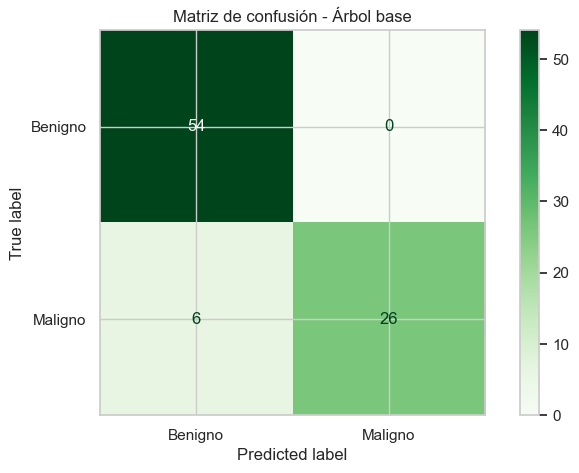

In [32]:
y_pred_tree = arbol_base.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 4))
print("Precision:", round(precision_score(y_test, y_pred_tree), 4))
print("Recall:", round(recall_score(y_test, y_pred_tree), 4))
print("F1-score:", round(f1_score(y_test, y_pred_tree), 4))

print("\nReporte completo:")
print(classification_report(y_test, y_pred_tree, target_names=['Benigno', 'Maligno']))

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Benigno', 'Maligno'])
disp_tree.plot(cmap='Greens')
plt.title("Matriz de confusión - Árbol base")
plt.show()

### 4.4 Visualización del Árbol y Reglas

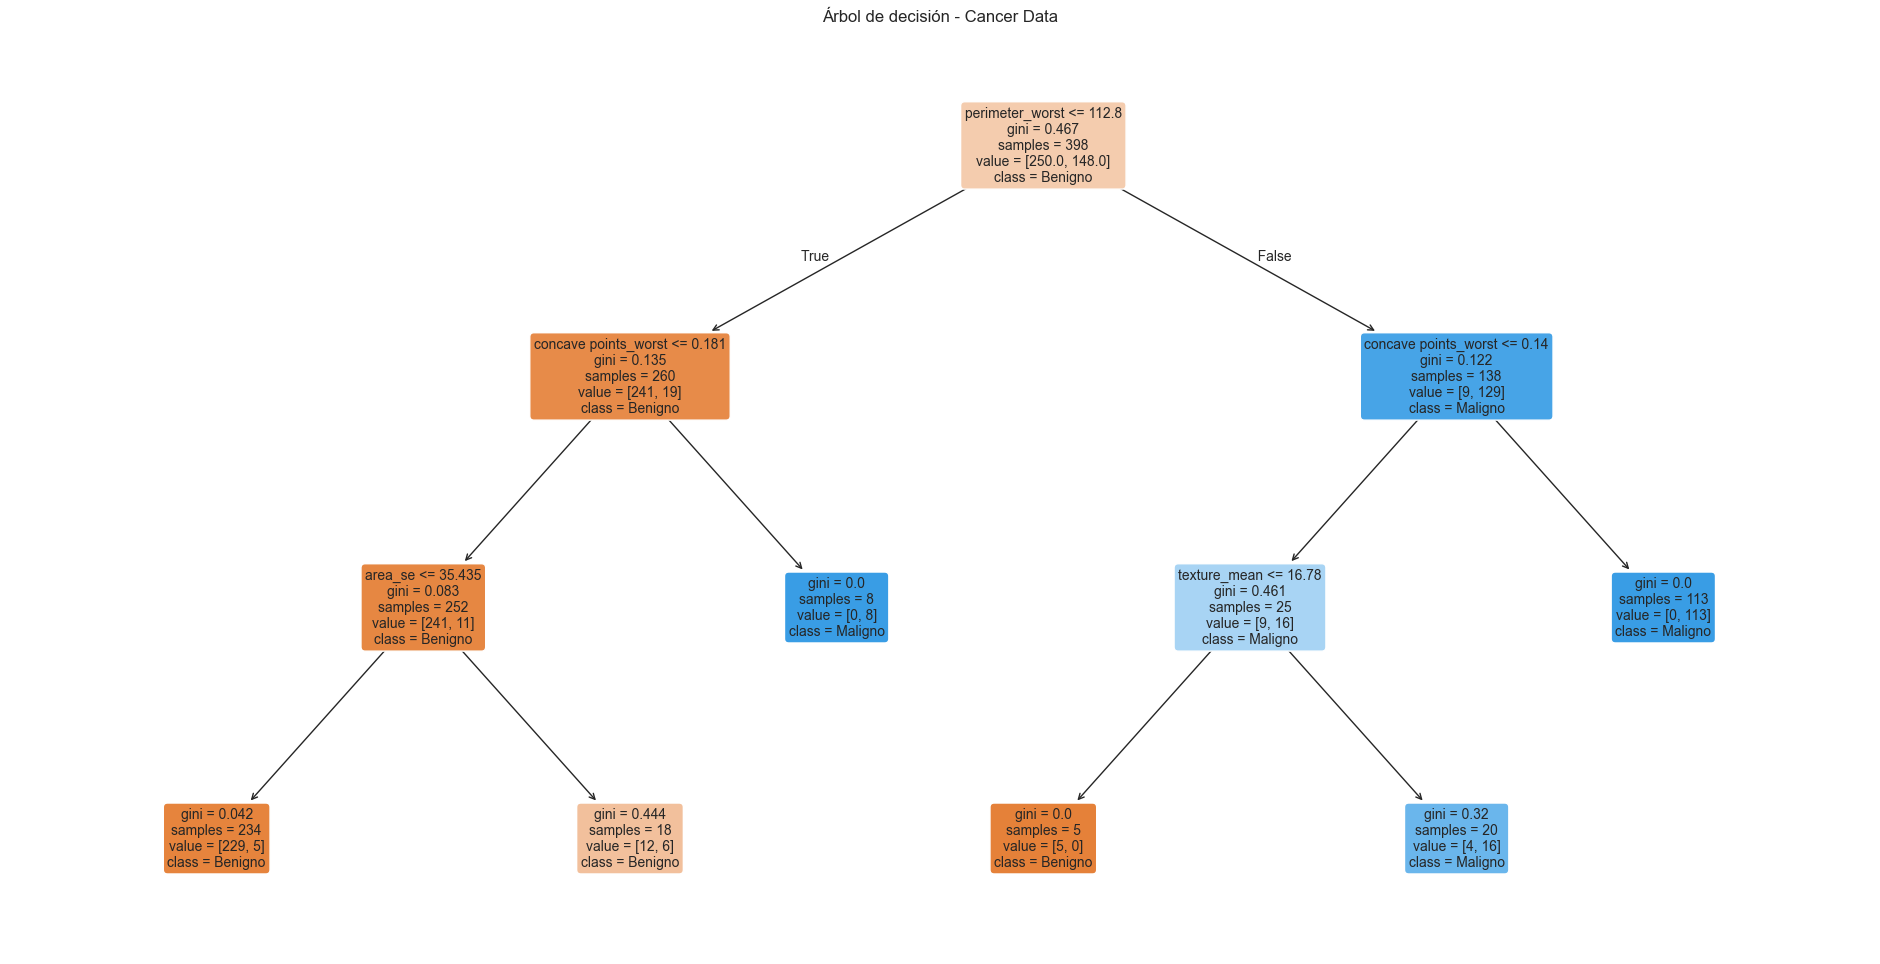

In [33]:
plt.figure(figsize=(24, 12))

plot_tree(
    arbol_base,
    feature_names=list(X.columns),
    class_names=['Benigno', 'Maligno'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión - Cancer Data")
plt.show()

In [34]:
reglas = export_text(arbol_base, feature_names=list(X.columns))
print("Reglas del Árbol:")
print(reglas)

Reglas del Árbol:
|--- perimeter_worst <= 112.80
|   |--- concave points_worst <= 0.18
|   |   |--- area_se <= 35.44
|   |   |   |--- class: 0
|   |   |--- area_se >  35.44
|   |   |   |--- class: 0
|   |--- concave points_worst >  0.18
|   |   |--- class: 1
|--- perimeter_worst >  112.80
|   |--- concave points_worst <= 0.14
|   |   |--- texture_mean <= 16.78
|   |   |   |--- class: 0
|   |   |--- texture_mean >  16.78
|   |   |   |--- class: 1
|   |--- concave points_worst >  0.14
|   |   |--- class: 1



### 4.5 Importancia de las Variables
Vemos cuáles son las características que el árbol considera más importantes para separar las clases.

,variable,importancia
22,perimeter_worst,0.827734
27,concave points_worst,0.120496
1,texture_mean,0.031655
13,area_se,0.020114
2,perimeter_mean,0.000000
3,area_mean,0.000000
5,compactness_mean,0.000000
6,concavity_mean,0.000000
8,symmetry_mean,0.000000
7,concave points_mean,0.000000


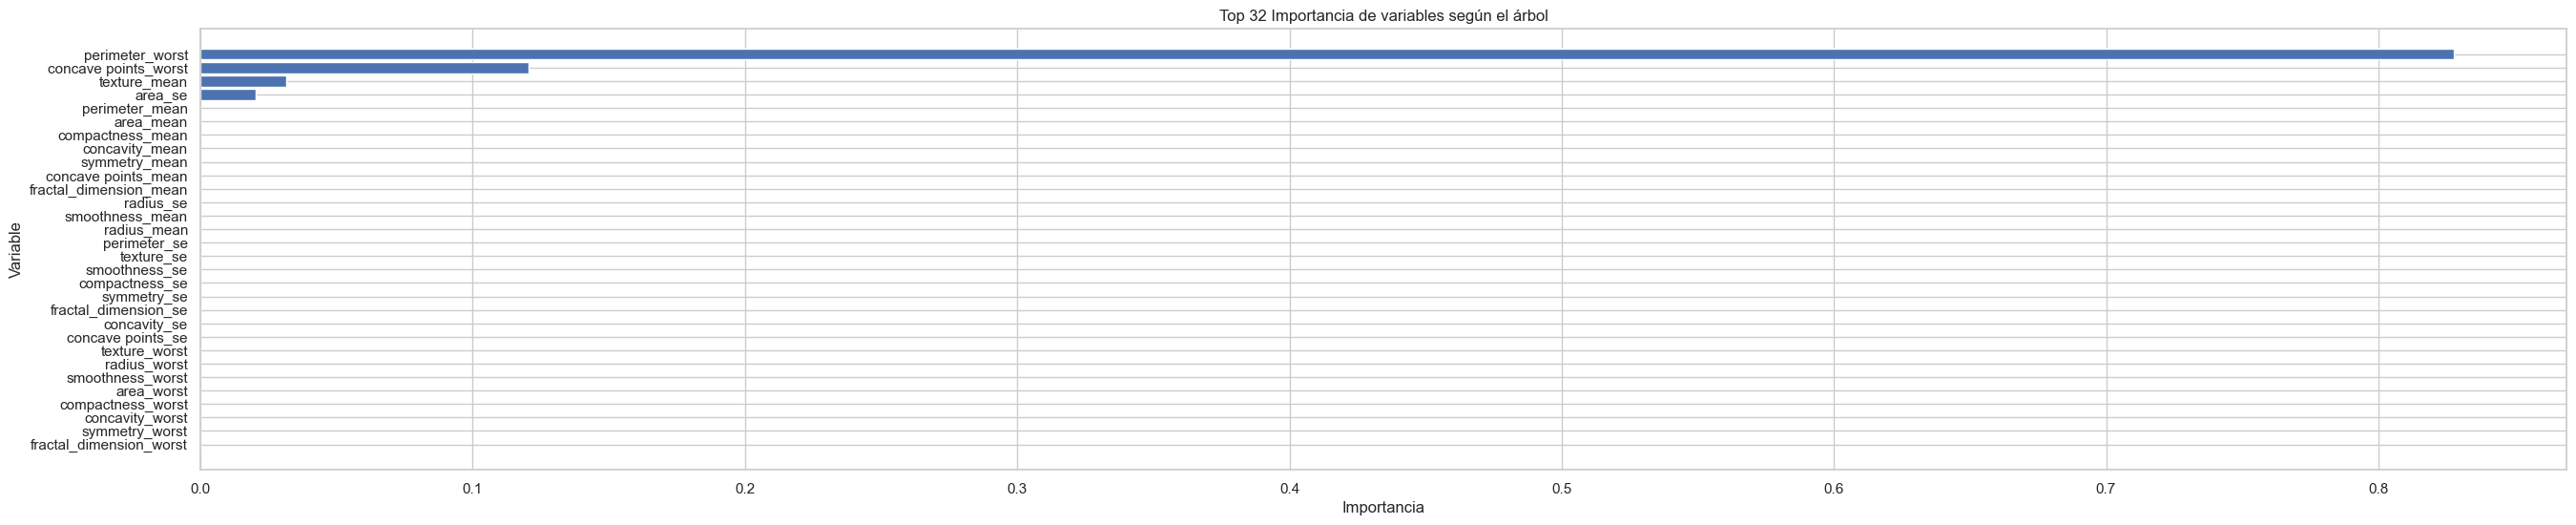

In [35]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": arbol_base.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias.head(32))

plt.figure(figsize=(32, 6))
plt.barh(importancias["variable"][:32], importancias["importancia"][:32])
plt.gca().invert_yaxis()
plt.title("Top 32 Importancia de variables según el árbol")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### 4.6 Efecto de la Profundidad del Árbol (Overfitting vs Generalización)
Si dejamos que el árbol crezca demasiado (`max_depth` alto), se ajustará perfectamente al set de entrenamiento pero perderá rendimiento en los datos de test.

In [36]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, None]
resultados = []

for p in profundidades:
    modelo = DecisionTreeClassifier(
        criterion="gini",
        max_depth=p,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados.append({
        "max_depth": str(p),
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,max_depth,accuracy_train,accuracy_test,f1_test
0,1,0.929648,0.906977,0.862069
1,2,0.949749,0.930233,0.900000
2,3,0.962312,0.930233,0.896552
3,4,0.977387,0.918605,0.881356
4,5,0.984925,0.930233,0.900000
5,6,0.992462,0.941860,0.918033
6,8,1.000000,0.906977,0.875000
7,10,1.000000,0.906977,0.875000
8,None,1.000000,0.906977,0.875000


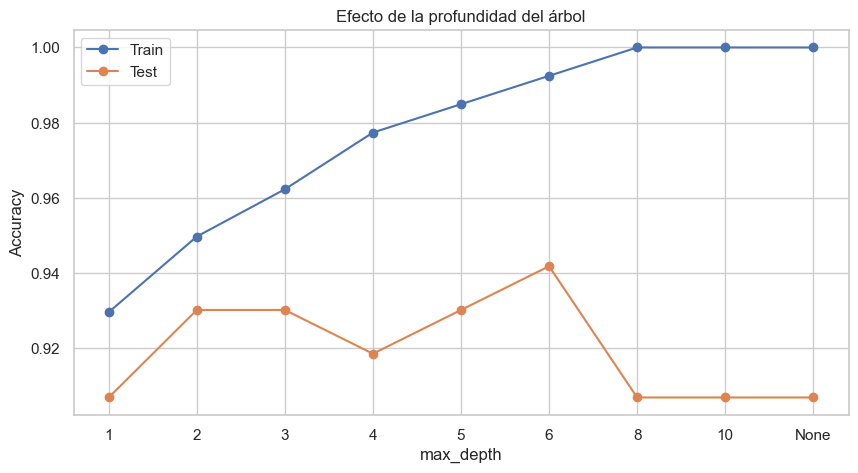

In [37]:
plt.figure(figsize=(10,5))
plt.plot(df_resultados["max_depth"].astype(str), df_resultados["accuracy_train"], marker="o", label="Train")
plt.plot(df_resultados["max_depth"].astype(str), df_resultados["accuracy_test"], marker="o", label="Test")
plt.title("Efecto de la profundidad del árbol")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 4.7 Comparación Gini vs Entropía

In [38]:
comparacion = []

for criterio in ["gini", "entropy"]:
    modelo = DecisionTreeClassifier(
        criterion=criterio,
        max_depth=3,
        random_state=42
    )

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    comparacion.append({
        "criterio": criterio,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

display(pd.DataFrame(comparacion))

,criterio,accuracy,precision,recall,f1
0,gini,0.930233,1.0,0.8125,0.896552
1,entropy,0.930233,1.0,0.8125,0.896552


# K-Nearest Neighbors (KNN) - Dataset de Cáncer

## Objetivo

Entrenar, evaluar y comparar un modelo KNN usando el dataset `Cancer_Data.csv`.

## Parte A — Comprensión conceptual

Responda:

1.  **¿Qué significa KNN?**
    *   _Respuesta:_ KNN significa "K-Nearest Neighbors" (K-Vecinos Más Cercanos). Es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para tareas de clasificación y regresión.

2.  **¿Cómo clasifica KNN un nuevo registro?**
    *   _Respuesta:_ Para clasificar un nuevo registro, KNN calcula la distancia entre este registro y todos los puntos de datos en el conjunto de entrenamiento. Luego, selecciona los 'k' vecinos más cercanos. La clase del nuevo registro se determina por la mayoría de las clases entre esos 'k' vecinos. En el caso de regresión, se toma la media de los valores de los 'k' vecinos.

3.  **¿Qué representa el parámetro \(k\)?**
    *   _Respuesta:_ El parámetro \(k\) representa el número de vecinos más cercanos que se consideran al clasificar un nuevo punto de datos. Es un hiperparámetro que debe ser ajustado, ya que un valor de \(k\) demasiado pequeño puede hacer que el modelo sea sensible al ruido (sobreajuste), y un valor demasiado grande puede hacer que ignore los patrones locales (subajuste).

4.  **¿Por qué KNN depende de la distancia?**
    *   _Respuesta:_ KNN depende fundamentalmente de la distancia porque su mecanismo de clasificación se basa en la proximidad. La distancia (comúnmente euclidiana, pero pueden usarse otras) es la métrica que define qué tan "cercanos" son los vecinos. Sin una medida de distancia, el algoritmo no podría identificar los "K-Nearest Neighbors".

5.  **¿Por qué el escalado es obligatorio o muy recomendable?**
    *   _Respuesta:_ El escalado de características es obligatorio o muy recomendable para KNN porque el algoritmo es sensible a la escala de las características. Si las características tienen rangos de valores muy diferentes, aquellas con rangos más grandes dominarán desproporcionadamente el cálculo de la distancia, haciendo que las características con rangos más pequeños sean casi irrelevantes. El escalado (por ejemplo, normalización o estandarización) asegura que todas las características contribuyan equitativamente a la medida de distancia.

6.  **¿Qué diferencia conceptual hay entre KNN y árbol de decisión?**
    *   _Respuesta:_ La principal diferencia conceptual radica en cómo aprenden y clasifican. Un **Árbol de Decisión** es un modelo basado en reglas que crea una estructura jerárquica de divisiones para segmentar el espacio de características, lo que resulta en una serie de reglas condicionales (si-entonces) que son fácilmente interpretables. Es un modelo "eager learning" (aprende antes de ver los datos de test). Por otro lado, **KNN** es un algoritmo basado en instancias o "lazy learning" (aprende cuando se le pide una predicción). No construye un modelo explícito durante el entrenamiento, sino que almacena todo el conjunto de datos de entrenamiento y clasifica un nuevo punto consultando a sus vecinos más cercanos en ese momento. Los árboles definen límites de decisión complejos, mientras que KNN define límites implícitamente basados en la densidad de puntos en el espacio de características.

## Parte B — Preparación de datos

Para este taller, utilizaremos todas las características numéricas del dataset `df` (excluyendo la columna `diagnosis` como variable objetivo). El dataset ya fue cargado, sus columnas limpiadas, la columna `id` y la columna vacía eliminadas, y la variable `diagnosis` codificada a 0 y 1 en las secciones anteriores del notebook.

Ahora, realizaremos la separación en conjuntos de entrenamiento y prueba (train/test split) con estratificación para asegurar una representación equitativa de las clases de diagnóstico en ambos conjuntos.

In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# --- START: Código para asegurar que df esté definido y limpio para el taller ---
# Cargar el dataset para asegurar un estado fresco del DataFrame
file_path = 'Cancer_Data.csv'

# Check if the file exists in the current directory first, then in /content/sample_data/
if not os.path.exists(file_path):
    file_path = '/content/sample_data/Cancer_Data.csv'

df = pd.read_csv(file_path)

# Limpiar nombres de columnas (eliminar espacios y comillas)
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M")
# Usando applymap para mayor compatibilidad con la versión original.
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Identificar y eliminar columnas con solo NaNs (más robusto)
cols_to_drop_nan = [col for col in df.columns if col != 'diagnosis' and df[col].isna().all()]
if cols_to_drop_nan:
    df.drop(columns=cols_to_drop_nan, inplace=True)

# Codificar la variable objetivo (Maligno = 1, Benigno = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
# --- END: Código para asegurar que df esté definido y limpio para el taller ---

# X y y son derivados del df limpio para el taller
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Realizamos un nuevo train/test split para este taller para seguir la estructura de la consigna
X_taller, X_temp, y_taller, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# La consigna del taller solo pide train/test, así que usaremos X_taller y y_taller
# como el conjunto completo para este taller, y luego haremos un 70/30 de nuevo.

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Dimensiones del conjunto de entrenamiento:", X_train_t.shape, y_train_t.shape)
print("Dimensiones del conjunto de prueba:", X_test_t.shape, y_test_t.shape)


Dimensiones del conjunto de entrenamiento: (398, 31) (398,)
Dimensiones del conjunto de prueba: (171, 31) (171,)


## Helper Function: `evaluar_modelo`

Para simplificar la evaluación y comparación de los modelos, definiremos una función auxiliar que calcula las métricas de clasificación (accuracy, precision, recall, f1-score) y las retorna en un diccionario. Esto nos permitirá tener un formato consistente para todas las comparaciones.

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_modelo(nombre_modelo, y_true, y_pred):
    """Calcula y retorna métricas de evaluación para un modelo."""
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


## Parte C — KNN sin escalado vs KNN con escalado

Entrenaremos y evaluaremos el modelo KNN con \(k=5\), primero sin escalar las características y luego aplicando un `StandardScaler` dentro de un `Pipeline`. Compararemos las métricas de rendimiento y discutiremos la importancia del escalado en KNN.

### Explicación:
*   **KNN sin escalado:** Se entrena el modelo directamente con los datos `X_train_t` y `y_train_t` sin ninguna transformación de las características.
*   **KNN con escalado:** Se utiliza un `Pipeline` que primero aplica `StandardScaler` a los datos (para estandarizarlos a media 0 y varianza 1) y luego entrena el `KNeighborsClassifier`. El escalado es crucial para KNN porque este algoritmo se basa en distancias. Si las características tienen rangos de valores muy diferentes, las características con rangos más grandes dominarán la métrica de distancia, sesgando los resultados.

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# KNN sin escalado
knn_sin = KNeighborsClassifier(n_neighbors=5)
knn_sin.fit(X_train_t, y_train_t)
pred_sin = knn_sin.predict(X_test_t)

# KNN con escalado usando Pipeline
knn_con = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_con.fit(X_train_t, y_train_t)
pred_con = knn_con.predict(X_test_t)

# Comparación de resultados
comparacion_taller_knn = pd.DataFrame([
    evaluar_modelo("KNN sin escalado", y_test_t, pred_sin),
    evaluar_modelo("KNN con escalado", y_test_t, pred_con)
])

display(comparacion_taller_knn)

print("\nMetodológicamente, la versión con escalado es más correcta porque el KNN se basa en la distancia entre los puntos. Sin escalado, las características con rangos de valores más grandes pueden dominar la métrica de distancia, llevando a resultados sesgados y un rendimiento subóptimo.")

C:\Users\julia\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\julia\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\julia\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\julia\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.p

,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN sin escalado,0.695906,0.714286,0.31250,0.434783
1,KNN con escalado,0.964912,1.000000,0.90625,0.950820



Metodológicamente, la versión con escalado es más correcta porque el KNN se basa en la distancia entre los puntos. Sin escalado, las características con rangos de valores más grandes pueden dominar la métrica de distancia, llevando a resultados sesgados y un rendimiento subóptimo.


## Parte D — Selección de k

Exploraremos el impacto del valor de \(k\) (el número de vecinos) en el rendimiento del modelo KNN. Entrenaremos y evaluaremos modelos KNN con escalado para valores de \(k\) entre 1 y 30. Analizaremos las métricas de `accuracy`, `precision`, `recall` y `F1-score` para identificar el \(k\) óptimo.

### Explicación:
*   **Problema de \(k=1\):** Un valor de \(k=1\) hace que el modelo sea muy sensible al ruido en los datos de entrenamiento. El clasificador simplemente asigna la clase del vecino más cercano, lo que puede llevar a un sobreajuste (overfitting) y una baja capacidad de generalización en datos no vistos.
*   **Problema de \(k\) demasiado grande:** Un valor de \(k\) muy grande puede hacer que el modelo capture más la distribución general de las clases que los patrones específicos de los vecinos cercanos, llevando a un subajuste (underfitting). El clasificador podría ignorar las características locales importantes y clasificar un nuevo punto basándose en una mayoría muy amplia que podría no ser representativa de su vecindad inmediata.

Los 10 mejores valores de k según F1-score:


,k,accuracy_test,precision_test,recall_test,f1_test
4,5,0.964912,1.000000,0.906250,0.950820
6,7,0.964912,1.000000,0.906250,0.950820
3,4,0.959064,1.000000,0.890625,0.942149
5,6,0.959064,1.000000,0.890625,0.942149
2,3,0.959064,1.000000,0.890625,0.942149
8,9,0.953216,0.982759,0.890625,0.934426
9,10,0.953216,0.982759,0.890625,0.934426
10,11,0.953216,0.982759,0.890625,0.934426
7,8,0.953216,1.000000,0.875000,0.933333
11,12,0.953216,1.000000,0.875000,0.933333


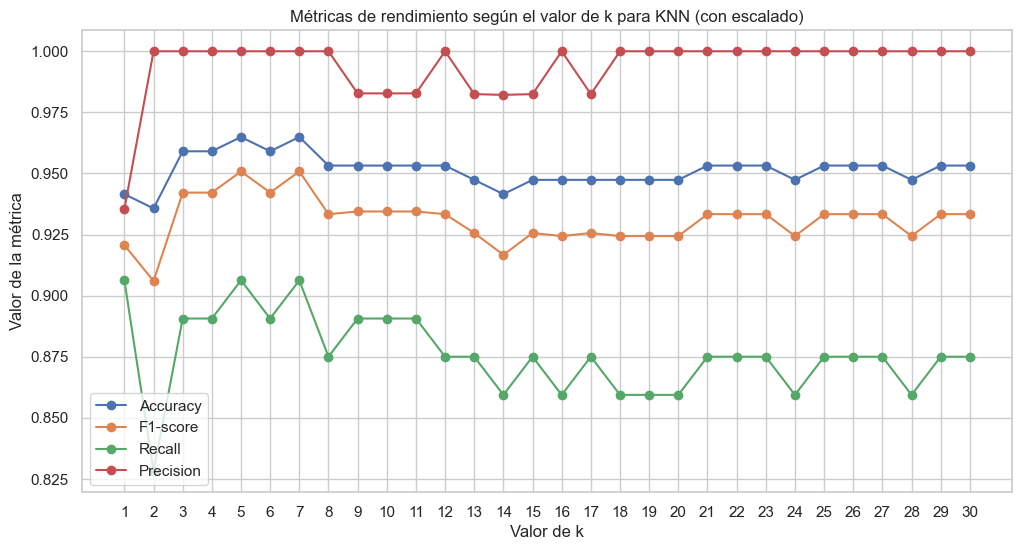

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

resultados_k_taller = []
for k in range(1, 31):
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train_t, y_train_t)
    pred = modelo.predict(X_test_t)
    resultados_k_taller.append({
        "k": k,
        "accuracy_test": accuracy_score(y_test_t, pred),
        "precision_test": precision_score(y_test_t, pred),
        "recall_test": recall_score(y_test_t, pred),
        "f1_test": f1_score(y_test_t, pred)
    })

df_k_taller = pd.DataFrame(resultados_k_taller)

print("Los 10 mejores valores de k según F1-score:")
display(df_k_taller.sort_values("f1_test", ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.plot(df_k_taller["k"], df_k_taller["accuracy_test"], marker="o", label="Accuracy")
plt.plot(df_k_taller["k"], df_k_taller["f1_test"], marker="o", label="F1-score")
plt.plot(df_k_taller["k"], df_k_taller["recall_test"], marker="o", label="Recall")
plt.plot(df_k_taller["k"], df_k_taller["precision_test"], marker="o", label="Precision")
plt.title("Métricas de rendimiento según el valor de k para KNN (con escalado)")
plt.xlabel("Valor de k")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True)
plt.xticks(range(1, 31))
plt.show()

## Parte E — Comparación contra árbol

Ahora compararemos el mejor modelo KNN (encontrado en la sección anterior basándonos en el `F1-score`) con un modelo de Árbol de Decisión. El Árbol de Decisión será entrenado con `criterion="gini"` y una profundidad máxima de 3 (`max_depth=3`) para mantenerlo interpretable y comparable con los árboles ya explorados en el notebook.

### Explicación:
*   **Interpretación:** Discutiremos cuál modelo ofrece una mayor interpretabilidad. Los árboles de decisión son conocidos por su fácil visualización y reglas claras, mientras que KNN es un algoritmo basado en instancias y su "razonamiento" no es directamente interpretable.
*   **Recomendación:** Basándonos en las métricas y la interpretabilidad, se hará una recomendación sobre cuál modelo sería más adecuado según un objetivo hipotético (por ejemplo, si la interpretabilidad es clave o si solo se busca el mejor rendimiento).

El mejor valor de k encontrado es: 5


,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN k=5,0.964912,1.0,0.90625,0.950820
1,Árbol max_depth=3,0.918129,1.0,0.78125,0.877193


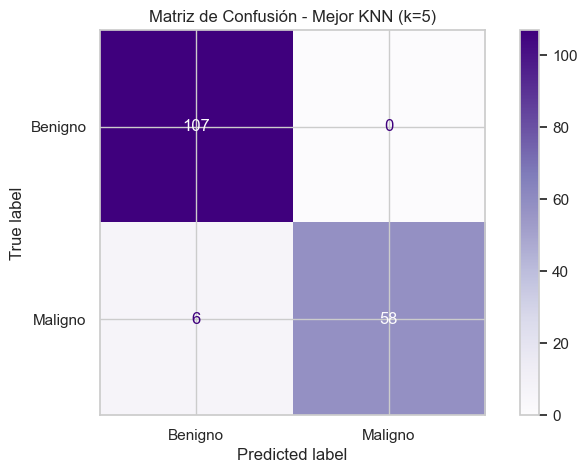

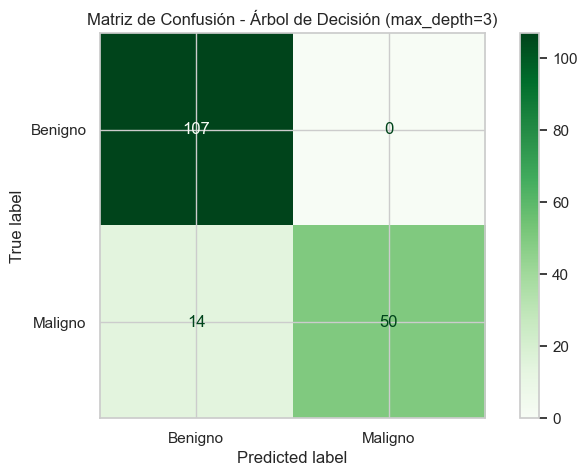

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener el mejor k basado en F1-score
mejor_k_taller = int(df_k_taller.sort_values("f1_test", ascending=False).iloc[0]["k"])

print(f"El mejor valor de k encontrado es: {mejor_k_taller}")

# Entrenar KNN con el mejor k
knn_mejor_taller = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k_taller))
])
knn_mejor_taller.fit(X_train_t, y_train_t)
pred_knn_mejor = knn_mejor_taller.predict(X_test_t)

# Entrenar Árbol de Decisión
arbol_taller = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
arbol_taller.fit(X_train_t, y_train_t)
pred_arbol_taller = arbol_taller.predict(X_test_t)

# Comparar los modelos
comparacion_modelos = pd.DataFrame([
    evaluar_modelo(f"KNN k={mejor_k_taller}", y_test_t, pred_knn_mejor),
    evaluar_modelo("Árbol max_depth=3", y_test_t, pred_arbol_taller)
])

display(comparacion_modelos)

# Matriz de confusión para el mejor KNN
cm_knn_mejor = confusion_matrix(y_test_t, pred_knn_mejor)
disp_knn_mejor = ConfusionMatrixDisplay(confusion_matrix=cm_knn_mejor, display_labels=['Benigno', 'Maligno'])
disp_knn_mejor.plot(cmap='Purples')
plt.title(f"Matriz de Confusión - Mejor KNN (k={mejor_k_taller})")
plt.show()

# Matriz de confusión para el Árbol de Decisión
cm_arbol_taller = confusion_matrix(y_test_t, pred_arbol_taller)
disp_arbol_taller = ConfusionMatrixDisplay(confusion_matrix=cm_arbol_taller, display_labels=['Benigno', 'Maligno'])
disp_arbol_taller.plot(cmap='Greens')
plt.title("Matriz de Confusión - Árbol de Decisión (max_depth=3)")
plt.show()

# Mineria de Datos - Random Forest con Comparacion de Modelos

Este bloque compara **Random Forest** contra modelos supervisados trabajados previamente:

1. Regresion logistica.
2. KNN.
3. Arbol de decision.
4. Random Forest.

Usaremos el dataset **Cancer_Data.csv** para mantener continuidad.

## Objetivo general

Comprender cuando Random Forest puede ser mas conveniente que un arbol individual, KNN o regresion logistica.

## Pregunta central

> ¿Que modelo clasifica mejor el diagnostico en Cancer_Data.csv y cual conviene usar segun desempeno, interpretabilidad y robustez?


# 1. Comparación conceptual inicial

| Modelo | Enfoque | Ventaja principal | Limitación principal |
|---|---|---|---|
| Regresión logística | Probabilidad | Simple e interpretable | Puede quedarse corta con relaciones complejas |
| KNN | Distancia | Intuitivo | Requiere escalado |
| Árbol | Reglas | Muy interpretable | Puede sobreajustar |
| Random Forest | Muchos árboles | Robusto y potente | Menos interpretable |

La comparación será justa porque todos los modelos usarán el mismo dataset preparado y la misma división train/test.

# 2. Librerías

Importamos herramientas para:

- Manipular datos.
- Crear gráficos.
- Preparar datos.
- Entrenar modelos.
- Evaluar resultados.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# 3. Carga del dataset Cancer_Data.csv

La variable objetivo es `diagnosis`:

- `B`: tumor benigno.
- `M`: tumor maligno.


In [ ]:
from pathlib import Path

data_path = Path("Cancer_Data.csv")
if not data_path.exists():
    data_path = Path("../Cancer_Data.csv")

df = pd.read_csv(data_path)
df.columns = df.columns.str.replace('"', '', regex=False).str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df = df.dropna(axis=1, how="all")

print("Archivo usado:", data_path)
print("Dimensiones:", df.shape)
df.head()


# 4. Comprensión inicial

Revisamos la estructura del dataset y los valores faltantes antes de modelar.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

faltantes

,faltantes,porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


# 5. Variable objetivo

Revisamos cuantos registros son benignos y cuantos son malignos. Esto es importante porque un desbalance fuerte puede hacer que el accuracy sea enganoso.


In [ ]:
conteo = df["diagnosis"].value_counts().reindex(["B", "M"])
porcentaje = df["diagnosis"].value_counts(normalize=True).reindex(["B", "M"]) * 100

resumen_target = pd.DataFrame({
    "diagnosis": conteo.index,
    "descripcion": ["Benigno", "Maligno"],
    "conteo": conteo.values,
    "porcentaje": porcentaje.round(2).values
})

resumen_target


In [ ]:
plt.figure(figsize=(6,4))
plt.bar(resumen_target["descripcion"], resumen_target["conteo"])
plt.title("Distribucion del diagnostico")
plt.xlabel("Diagnostico")
plt.ylabel("Numero de registros")
plt.show()


# 6. Exploracion: diagnostico y variables clinicas

Estas variables permiten revisar si algunas mediciones del tumor cambian claramente entre casos benignos y malignos.


In [ ]:
variables_explorar = ["radius_mean", "area_mean", "concavity_mean", "concave points_mean"]
resumen_por_diagnostico = df.groupby("diagnosis")[variables_explorar].mean().round(3)
resumen_por_diagnostico


In [ ]:
resumen_por_diagnostico.T.plot(kind="bar", figsize=(9,4))
plt.title("Promedio de variables clinicas por diagnostico")
plt.xlabel("Variable")
plt.ylabel("Promedio")
plt.xticks(rotation=25)
plt.show()


In [ ]:
df_bins = df.copy()
df_bins["area_mean_grupo"] = pd.qcut(df_bins["area_mean"], q=3, labels=["Baja", "Media", "Alta"])
tabla_area = pd.crosstab(df_bins["area_mean_grupo"], df_bins["diagnosis"], normalize="index") * 100
tabla_area.columns = ["Benigno (%)", "Maligno (%)"]
tabla_area.round(2)


In [ ]:
tabla_area.plot(kind="bar", figsize=(7,4))
plt.title("Diagnostico segun grupo de area_mean")
plt.xlabel("Grupo de area_mean")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()


# 7. Preparacion de datos

Variables usadas:

- Todas las mediciones numericas del tumor.
- Se elimina `id` porque es un identificador y no una caracteristica clinica.
- Se elimina cualquier columna completamente vacia.

Tratamiento:

- `diagnosis` se codifica como 0 = benigno y 1 = maligno.
- Las variables predictoras son numericas.
- El escalado se aplica dentro de los modelos que lo requieren, usando `Pipeline` para evitar data leakage.


In [ ]:
df_model = df.copy()

if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

df_model = df_model.dropna(axis=1, how="all")
df_model["diagnosis"] = df_model["diagnosis"].map({"B": 0, "M": 1})

for col in df_model.columns:
    if col != "diagnosis":
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.fillna(df_model.median(numeric_only=True))

print("Dimensiones:", df_model.shape)
df_model.head()


In [ ]:
df_model.isna().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

# 8. Separación X/y

- `X`: variables predictoras.
- `y`: variable objetivo.

In [ ]:
X = df_model.drop(columns=["diagnosis"])
y = df_model["diagnosis"]

print("X:", X.shape)
print("y:", y.shape)
print("Variables:", list(X.columns))


# 9. División train/test

Usamos la misma división para todos los modelos.

Esto permite una comparación justa.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (623, 8)
Test: (268, 8)


# 10. Función de evaluación

La función permite comparar todos los modelos con las mismas métricas:

- Accuracy.
- Precision.
- Recall.
- F1-score.

In [ ]:
def evaluar_clasificacion(nombre, y_real, y_pred):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall": recall_score(y_real, y_pred),
        "f1": f1_score(y_real, y_pred)
    }

# 11. Modelo 1: Regresión logística

La regresión logística estima probabilidades para clasificación binaria.

Usamos escalado porque es un modelo lineal y puede beneficiarse de variables en escala comparable.

In [ ]:
modelo_logistica = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

modelo_logistica.fit(X_train, y_train)
pred_logistica = modelo_logistica.predict(X_test)

print(classification_report(y_test, pred_logistica, target_names=["Benigno", "Maligno"]))


# 12. Modelo 2: KNN

KNN clasifica usando vecinos cercanos.

Requiere escalado porque depende de distancias.

In [ ]:
modelo_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

modelo_knn.fit(X_train, y_train)
pred_knn = modelo_knn.predict(X_test)

print(classification_report(y_test, pred_knn, target_names=["Benigno", "Maligno"]))


# 13. Modelo 3: Árbol de decisión

El árbol genera reglas interpretables, pero puede sobreajustar.

In [ ]:
modelo_arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

print(classification_report(y_test, pred_arbol, target_names=["Benigno", "Maligno"]))


## Visualización del árbol

El árbol puede leerse como reglas IF-THEN.

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["Benigno", "Maligno"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Arbol de decision - Cancer_Data.csv")
plt.show()


# 14. Modelo 4: Random Forest

Random Forest entrena muchos árboles y combina sus predicciones.

Esto reduce la dependencia de un único árbol y mejora la robustez.

Parámetros:

- `n_estimators`: número de árboles.
- `max_depth`: profundidad máxima.
- `random_state`: reproducibilidad.

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, pred_rf, target_names=["Benigno", "Maligno"]))


## Comparación general de modelos (Dataset de Cáncer)

En esta sección se consolida la comparación final entre los modelos de clasificación trabajados en el proyecto:

1. Regresión Logística
2. KNN
3. Árbol de Decisión
4. Random Forest

Se evaluará con las métricas:

- Accuracy
- Precision
- Recall
- F1-score

Tabla final de comparación:


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.798507,0.742574,0.728155,0.735294
1,Random Forest,0.798507,0.775281,0.669903,0.718750
2,KNN,0.791045,0.752688,0.679612,0.714286
3,Árbol de Decisión,0.794776,0.875000,0.543689,0.670659


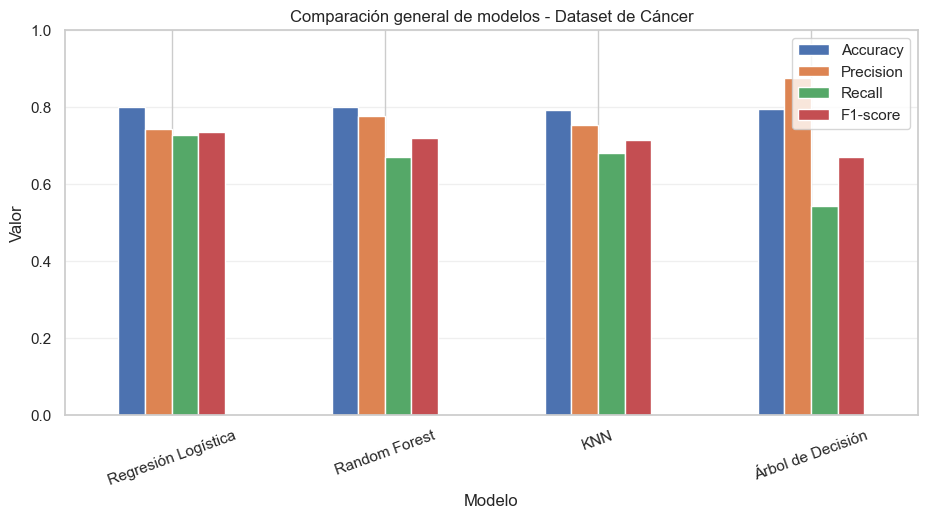

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluar_modelo_final(nombre_modelo, y_true, y_pred):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

# Comparación con los modelos disponibles en el notebook
resultados = [
    evaluar_modelo_final("Regresión Logística", y_test, pred_logistica),
    evaluar_modelo_final("KNN", y_test, pred_knn),
    evaluar_modelo_final("Árbol de Decisión", y_test, pred_arbol),
    evaluar_modelo_final("Random Forest", y_test, pred_rf)
]

comparacion_general_modelos = pd.DataFrame(resultados).sort_values("F1-score", ascending=False).reset_index(drop=True)
print("Tabla final de comparación:")
display(comparacion_general_modelos)

# Visualización de métricas
metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
comparacion_general_modelos.set_index("Modelo")[metricas].plot(kind="bar", figsize=(11, 5))
plt.title("Comparación general de modelos - Dataset de Cáncer")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interpretación de la comparación

Preguntas clave:

1. ¿Cuál modelo tiene mayor accuracy?
2. ¿Cuál tiene mayor recall?
3. ¿Cuál tiene mayor precision?
4. ¿Cuál tiene mejor F1?
5. ¿Cuál es más interpretable?
6. ¿Cuál depende más del preprocesamiento?
7. ¿Cuál recomendaría y por qué?

No siempre gana el modelo con mayor accuracy. La elección depende del objetivo del problema.

In [ ]:
# Respuestas automáticas basadas en la tabla comparativa
mejor_accuracy = comparacion_general_modelos.loc[comparacion_general_modelos["Accuracy"].idxmax(), "Modelo"]
mejor_recall = comparacion_general_modelos.loc[comparacion_general_modelos["Recall"].idxmax(), "Modelo"]
mejor_precision = comparacion_general_modelos.loc[comparacion_general_modelos["Precision"].idxmax(), "Modelo"]
mejor_f1 = comparacion_general_modelos.loc[comparacion_general_modelos["F1-score"].idxmax(), "Modelo"]

print("1) Modelo con mayor Accuracy:", mejor_accuracy)
print("2) Modelo con mayor Recall:", mejor_recall)
print("3) Modelo con mayor Precision:", mejor_precision)
print("4) Modelo con mejor F1-score:", mejor_f1)
print("5) Modelo más interpretable: Árbol de Decisión (también Regresión Logística es interpretable)")
print("6) Modelo que más depende del preprocesamiento: KNN (y también Regresión Logística por escalado)")

# Recomendación final para el dataset de cáncer
modelo_recomendado = mejor_f1

print("\nConclusión final:")
print(f"Para este dataset de cáncer, el modelo recomendado es: {modelo_recomendado}.")
print("Razón: prioriza el mejor equilibrio entre Precision y Recall (medido por F1-score),")
print("lo cual es clave en clasificación médica para reducir errores relevantes en diagnóstico.")

1) Modelo con mayor Accuracy: Regresión Logística
2) Modelo con mayor Recall: Regresión Logística
3) Modelo con mayor Precision: Árbol de Decisión
4) Modelo con mejor F1-score: Regresión Logística
5) Modelo más interpretable: Árbol de Decisión (también Regresión Logística es interpretable)
6) Modelo que más depende del preprocesamiento: KNN (y también Regresión Logística por escalado)

Conclusión final:
Para este dataset de cáncer, el modelo recomendado es: Regresión Logística.
Razón: prioriza el mejor equilibrio entre Precision y Recall (medido por F1-score),
lo cual es clave en clasificación médica para reducir errores relevantes en diagnóstico.


## Conclusión ejecutiva

Para el **dataset de cáncer**, el modelo recomendado es el que obtenga el mayor **F1-score** en la tabla comparativa final.

En este contexto, se prioriza F1-score porque combina:

- **Precision**: evita falsos positivos innecesarios.
- **Recall**: evita falsos negativos (crítico en salud).

Si dos modelos empatan en accuracy, se prefiere el que tenga mejor balance Precision/Recall y mejor comportamiento clínico esperado.

# 🌲 Random Forest con Cancer_Data.csv

En esta sección se entrena y compara **Random Forest** contra modelos supervisados trabajados previamente (Regresión Logística, KNN y Árbol de Decisión) usando el dataset de cáncer.

## Objetivos

1. Comparar desempeño de Random Forest con otros modelos.
2. Entender el impacto de `n_estimators` y `max_depth` en Random Forest.
3. Calcular la importancia de características.
4. Justificar técnicamente cuál modelo elegir según el problema.

# KNN sobre `Cancer_Data.csv`

En esta sección se entrena, evalúa y compara un modelo KNN sobre el dataset de cáncer. La estructura sigue la lógica trabajada en la clase de KNN: primero se revisa el efecto de no escalar las variables, luego se aplica escalado con `StandardScaler` y finalmente se comparan distintos valores de `k`.

## 1. Objetivo y criterios de evaluación

El objetivo es comparar tres variantes:

1. KNN sin escalado.
2. KNN con escalado.
3. KNN con distintos valores de `k`.

Se usarán las métricas:

- Accuracy
- Precision
- Recall
- F1-score

Además, se comparará el mejor KNN contra un árbol de decisión para tener una referencia interpretativa.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluar_knn(nombre_modelo, y_true, y_pred):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }


df_knn = pd.read_csv("Cancer_Data.csv")
df_knn.columns = [col.strip().strip('"') for col in df_knn.columns]

if "id" in df_knn.columns:
    df_knn = df_knn.drop(columns=["id"])
if "Unnamed: 32" in df_knn.columns:
    df_knn = df_knn.drop(columns=["Unnamed: 32"])

if "diagnosis" not in df_knn.columns:
    raise ValueError("No se encontró la columna diagnosis en Cancer_Data.csv")

df_knn["diagnosis"] = df_knn["diagnosis"].astype(str).str.strip().str.strip('"')
df_knn["diagnosis"] = df_knn["diagnosis"].map({"M": 1, "B": 0})
df_knn = df_knn.dropna(subset=["diagnosis"])

X_knn = df_knn.drop(columns=["diagnosis"]).apply(pd.to_numeric, errors="coerce")
cols_all_nan = X_knn.columns[X_knn.isna().all()].tolist()
if cols_all_nan:
    X_knn = X_knn.drop(columns=cols_all_nan)
    print("Columnas totalmente NaN eliminadas:", cols_all_nan)

X_knn = X_knn.fillna(X_knn.median(numeric_only=True))
mask_completo = X_knn.notna().all(axis=1)
X_knn = X_knn.loc[mask_completo].reset_index(drop=True)
y_knn = df_knn.loc[mask_completo, "diagnosis"].reset_index(drop=True)

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.30, random_state=42, stratify=y_knn
)

print("Dimensiones train:", X_train_knn.shape)
print("Dimensiones test:", X_test_knn.shape)
print("Distribución target en train:")
print(y_train_knn.value_counts(normalize=True).sort_index())
print("Distribución target en test:")
print(y_test_knn.value_counts(normalize=True).sort_index())

Columnas totalmente NaN eliminadas: ['']
Dimensiones train: (398, 30)
Dimensiones test: (171, 30)
Distribución target en train:
diagnosis
0    0.628141
1    0.371859
Name: proportion, dtype: float64
Distribución target en test:
diagnosis
0    0.625731
1    0.374269
Name: proportion, dtype: float64


## 2. KNN sin escalado vs KNN con escalado

Primero entrenamos un KNN base con `k=5` sin transformar las variables. Luego repetimos el proceso con `StandardScaler` para ver el impacto del preprocesamiento en un modelo basado en distancias.

Comparación KNN sin escalado vs con escalado


,Modelo,Accuracy,Precision,Recall,F1-score
1,KNN con escalado,0.964912,1.000000,0.906250,0.950820
0,KNN sin escalado,0.929825,0.981481,0.828125,0.898305


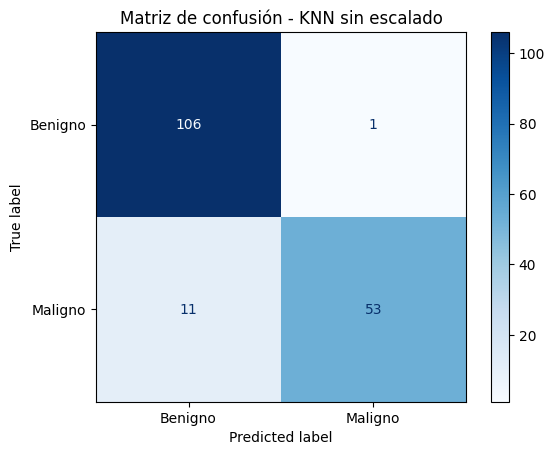

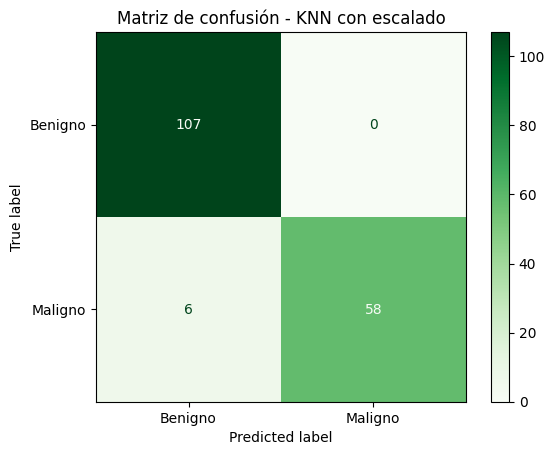

In [ ]:
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5)
knn_sin_escalar.fit(X_train_knn, y_train_knn)
pred_sin_escalar = knn_sin_escalar.predict(X_test_knn)

knn_con_escalado = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_con_escalado.fit(X_train_knn, y_train_knn)
pred_con_escalado = knn_con_escalado.predict(X_test_knn)

comparacion_knn_escalado = pd.DataFrame([
    evaluar_knn("KNN sin escalado", y_test_knn, pred_sin_escalar),
    evaluar_knn("KNN con escalado", y_test_knn, pred_con_escalado)
]).sort_values("F1-score", ascending=False)

print("Comparación KNN sin escalado vs con escalado")
display(comparacion_knn_escalado)

cm_sin = confusion_matrix(y_test_knn, pred_sin_escalar)
disp_sin = ConfusionMatrixDisplay(confusion_matrix=cm_sin, display_labels=["Benigno", "Maligno"])
disp_sin.plot(cmap="Blues")
plt.title("Matriz de confusión - KNN sin escalado")
plt.show()

cm_con = confusion_matrix(y_test_knn, pred_con_escalado)
disp_con = ConfusionMatrixDisplay(confusion_matrix=cm_con, display_labels=["Benigno", "Maligno"])
disp_con.plot(cmap="Greens")
plt.title("Matriz de confusión - KNN con escalado")
plt.show()

## 3. Selección de `k` y comparación contra un árbol

Probamos distintos valores de `k` para identificar el mejor balance entre sesgo y varianza. Después comparamos el mejor KNN con un árbol de decisión de profundidad limitada para tener una referencia interpretable.

Top 10 valores de k según F1-score


,k,Accuracy,Precision,Recall,F1-score
4,5,0.964912,1.000000,0.906250,0.950820
6,7,0.964912,1.000000,0.906250,0.950820
3,4,0.959064,1.000000,0.890625,0.942149
5,6,0.959064,1.000000,0.890625,0.942149
2,3,0.959064,1.000000,0.890625,0.942149
8,9,0.953216,0.982759,0.890625,0.934426
9,10,0.953216,0.982759,0.890625,0.934426
10,11,0.953216,0.982759,0.890625,0.934426
7,8,0.953216,1.000000,0.875000,0.933333
11,12,0.953216,1.000000,0.875000,0.933333


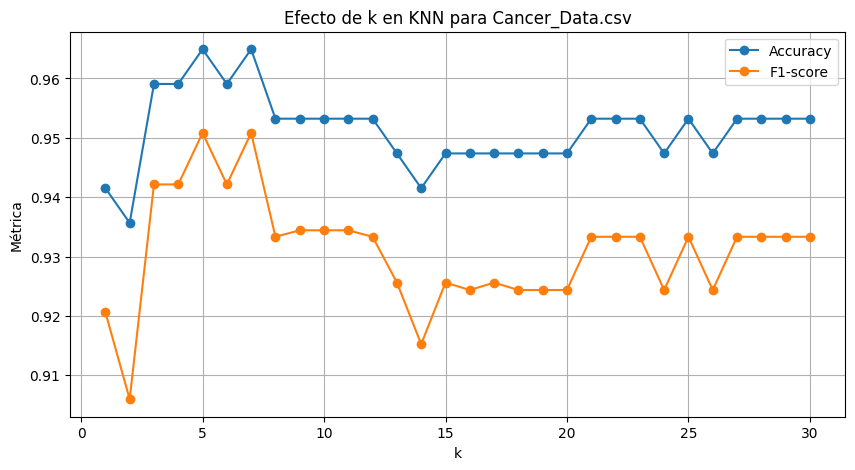

Comparación final KNN vs árbol


,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN k=5,0.964912,1.0,0.90625,0.950820
1,Árbol max_depth=3,0.918129,1.0,0.78125,0.877193


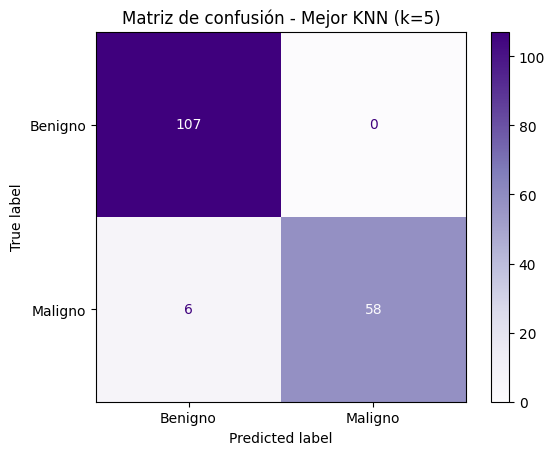

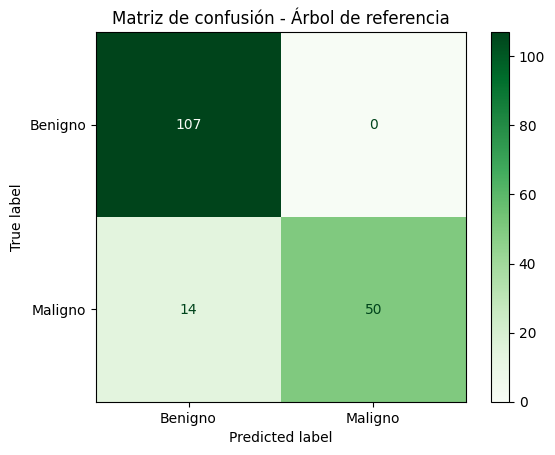

In [ ]:
resultados_k = []
for k in range(1, 31):
    modelo_k = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo_k.fit(X_train_knn, y_train_knn)
    pred_k = modelo_k.predict(X_test_knn)
    resultados_k.append({
        "k": k,
        "Accuracy": accuracy_score(y_test_knn, pred_k),
        "Precision": precision_score(y_test_knn, pred_k, zero_division=0),
        "Recall": recall_score(y_test_knn, pred_k, zero_division=0),
        "F1-score": f1_score(y_test_knn, pred_k, zero_division=0)
    })

comparacion_k = pd.DataFrame(resultados_k).sort_values("F1-score", ascending=False)
print("Top 10 valores de k según F1-score")
display(comparacion_k.head(10))

plt.figure(figsize=(10, 5))
plt.plot(comparacion_k.sort_values("k")["k"], comparacion_k.sort_values("k")["Accuracy"], marker="o", label="Accuracy")
plt.plot(comparacion_k.sort_values("k")["k"], comparacion_k.sort_values("k")["F1-score"], marker="o", label="F1-score")
plt.title("Efecto de k en KNN para Cancer_Data.csv")
plt.xlabel("k")
plt.ylabel("Métrica")
plt.grid(True)
plt.legend()
plt.show()

mejor_k = int(comparacion_k.iloc[0]["k"])
knn_mejor = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k))
])
knn_mejor.fit(X_train_knn, y_train_knn)
pred_knn_mejor = knn_mejor.predict(X_test_knn)

arbol_ref = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_ref.fit(X_train_knn, y_train_knn)
pred_arbol_ref = arbol_ref.predict(X_test_knn)

comparacion_final_knn = pd.DataFrame([
    evaluar_knn(f"KNN k={mejor_k}", y_test_knn, pred_knn_mejor),
    evaluar_knn("Árbol max_depth=3", y_test_knn, pred_arbol_ref)
])

print("Comparación final KNN vs árbol")
display(comparacion_final_knn.sort_values("F1-score", ascending=False))

cm_knn = confusion_matrix(y_test_knn, pred_knn_mejor)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Benigno", "Maligno"])
disp_knn.plot(cmap="Purples")
plt.title(f"Matriz de confusión - Mejor KNN (k={mejor_k})")
plt.show()

cm_arbol = confusion_matrix(y_test_knn, pred_arbol_ref)
disp_arbol = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=["Benigno", "Maligno"])
disp_arbol.plot(cmap="Greens")
plt.title("Matriz de confusión - Árbol de referencia")
plt.show()

## 4. Conclusión

KNN es un modelo útil para este dataset cuando se aplica correctamente el escalado. En el contexto de cáncer, su desempeño depende fuertemente de la representación de las variables y del valor de `k`. Si el objetivo es rendimiento puro, el mejor KNN suele competir bien; si el objetivo es interpretabilidad, el árbol sigue siendo más fácil de explicar.

## 1. Preparación de datos

Se utilizan los datos de entrenamiento y test ya preparados en la sección de KNN (Cancer_Data.csv con split 70/30).

Los datos contienen:
- **Features**: 30 características numéricas del dataset de cáncer
- **Target**: `diagnosis` (0 = Benigno, 1 = Maligno)  
- **Train**: 398 muestras | **Test**: 171 muestras

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("✓ Datos preparados previamente:")
print(f"  - X_train_knn: {X_train_knn.shape}")
print(f"  - X_test_knn: {X_test_knn.shape}")
print(f"  - y_train_knn: {len(y_train_knn)} muestras")
print(f"  - y_test_knn: {len(y_test_knn)} muestras")

✓ Datos preparados previamente:
  - X_train_knn: (398, 30)
  - X_test_knn: (171, 30)
  - y_train_knn: 398 muestras
  - y_test_knn: 171 muestras


## 2. Entrenamiento de modelos base y Random Forest

Se entrenan cuatro modelos supervisados para clasificar diagnósticos de cáncer:
1. **Regresión Logística**: modelo lineal baseline
2. **KNN (k=5)**: modelo basado en distancia
3. **Árbol de Decisión (max_depth=3)**: modelo interpretable
4. **Random Forest (n_estimators=200)**: ensamble robusto

In [ ]:
def evaluar_modelo(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

modelo_logistica = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistica.fit(X_train_knn, y_train_knn)
pred_logistica = modelo_logistica.predict(X_test_knn)
print("Regresión Logística:")
print(classification_report(y_test_knn, pred_logistica, target_names=["Benigno", "Maligno"]))

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_knn, y_train_knn)
pred_knn = modelo_knn.predict(X_test_knn)
print("\nKNN (k=5):")
print(classification_report(y_test_knn, pred_knn, target_names=["Benigno", "Maligno"]))

modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train_knn, y_train_knn)
pred_arbol = modelo_arbol.predict(X_test_knn)
print("\nÁrbol de Decisión (max_depth=3):")
print(classification_report(y_test_knn, pred_arbol, target_names=["Benigno", "Maligno"]))

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train_knn, y_train_knn)
pred_rf = modelo_rf.predict(X_test_knn)
print("\nRandom Forest (n_estimators=200):")
print(classification_report(y_test_knn, pred_rf, target_names=["Benigno", "Maligno"]))

C:\Users\andru\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regresión Logística:
              precision    recall  f1-score   support

     Benigno       0.92      0.99      0.95       107
     Maligno       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


KNN (k=5):
              precision    recall  f1-score   support

     Benigno       0.91      0.99      0.95       107
     Maligno       0.98      0.83      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171


Árbol de Decisión (max_depth=3):
              precision    recall  f1-score   support

     Benigno       0.88      1.00      0.94       107
     Maligno       1.00      0.78      0.88        64

    accuracy                           0.92       171
   macro avg       0.94      0.89      0.91       171
weighte

## 3. Comparación general de modelos

Tabla comparativa de desempeño con las métricas principales:

Comparación de modelos - Dataset Cáncer:


,Modelo,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.970760,1.000000,0.921875,0.959350
0,Regresión Logística,0.941520,0.982143,0.859375,0.916667
1,KNN,0.929825,0.981481,0.828125,0.898305
2,Árbol max_depth=3,0.918129,1.000000,0.781250,0.877193


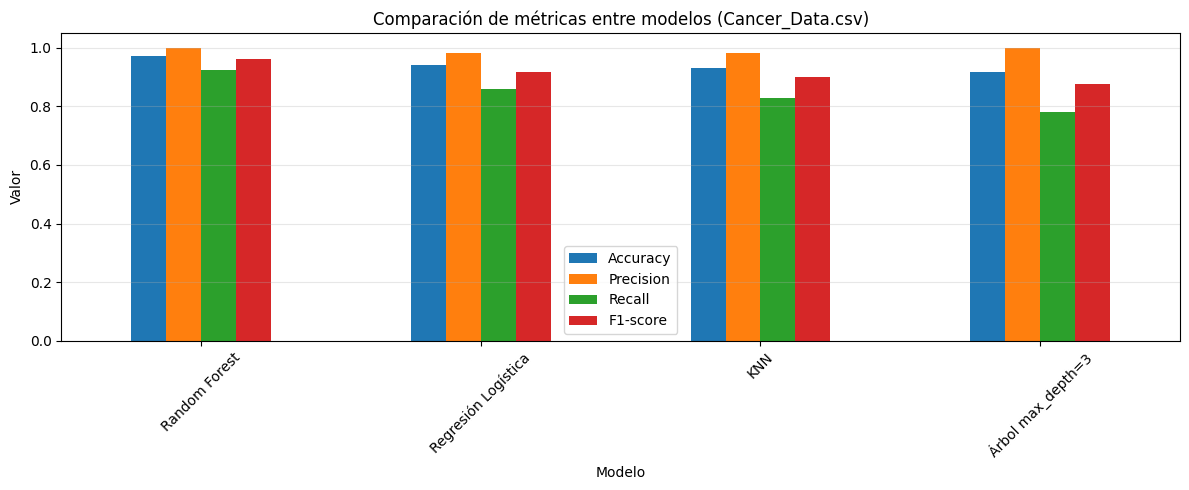

In [ ]:
resultados = [
    evaluar_modelo("Regresión Logística", y_test_knn, pred_logistica),
    evaluar_modelo("KNN", y_test_knn, pred_knn),
    evaluar_modelo("Árbol max_depth=3", y_test_knn, pred_arbol),
    evaluar_modelo("Random Forest", y_test_knn, pred_rf)
]

comparacion_general = pd.DataFrame(resultados).sort_values("F1-score", ascending=False)
print("Comparación de modelos - Dataset Cáncer:")
display(comparacion_general)

metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
comparacion_general.set_index("Modelo")[metricas].plot(kind="bar", figsize=(12, 5))
plt.title("Comparación de métricas entre modelos (Cancer_Data.csv)")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Importancia de características en Random Forest

Random Forest permite identificar qué características son más relevantes para predecir el diagnóstico:

Top 10 características más importantes:


,Característica,Importancia
22,perimeter_worst,0.141211
23,area_worst,0.127340
7,concave points_mean,0.112583
27,concave points_worst,0.094050
20,radius_worst,0.085649
3,area_mean,0.053067
2,perimeter_mean,0.052225
0,radius_mean,0.049073
6,concavity_mean,0.042670
13,area_se,0.035200


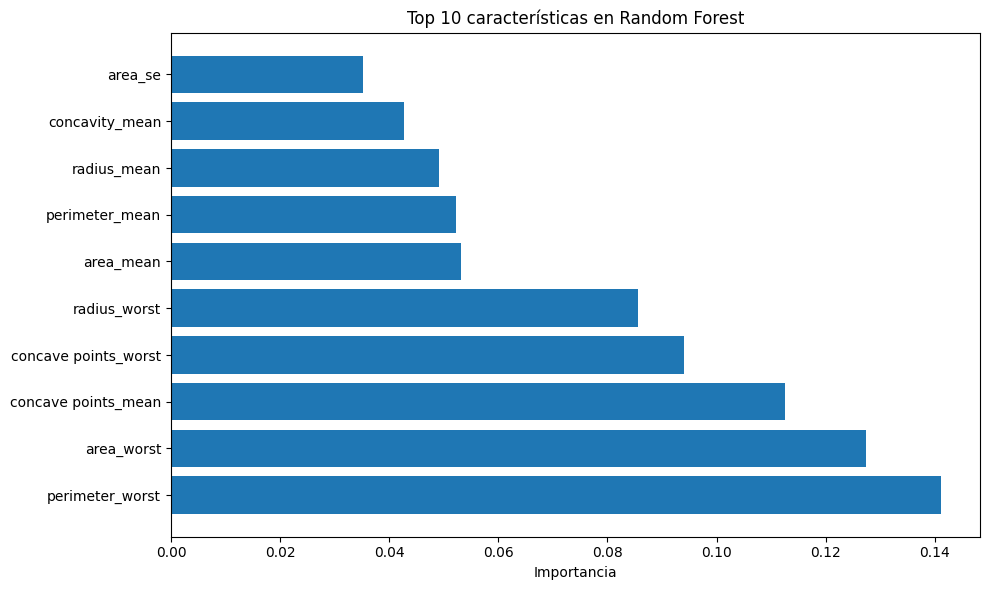

In [ ]:
importancia = pd.DataFrame({
    "Característica": X_train_knn.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=False)

print("Top 10 características más importantes:")
display(importancia.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importancia.head(10)["Característica"], importancia.head(10)["Importancia"])
plt.xlabel("Importancia")
plt.title("Top 10 características en Random Forest")
plt.tight_layout()
plt.show()

## 5. Análisis de parámetros en Random Forest

Se explora el impacto de dos parámetros clave: `n_estimators` (número de árboles) y `max_depth` (profundidad máxima).

### 5.1 Efecto de n_estimators

Se entrenan modelos con distintos números de árboles para observar convergencia:

Efecto de n_estimators:


,n_estimators,Accuracy,F1-score
0,10,0.947368,0.92437
1,50,0.964912,0.95082
2,100,0.964912,0.95082
3,150,0.970760,0.95935
4,200,0.970760,0.95935
5,250,0.970760,0.95935


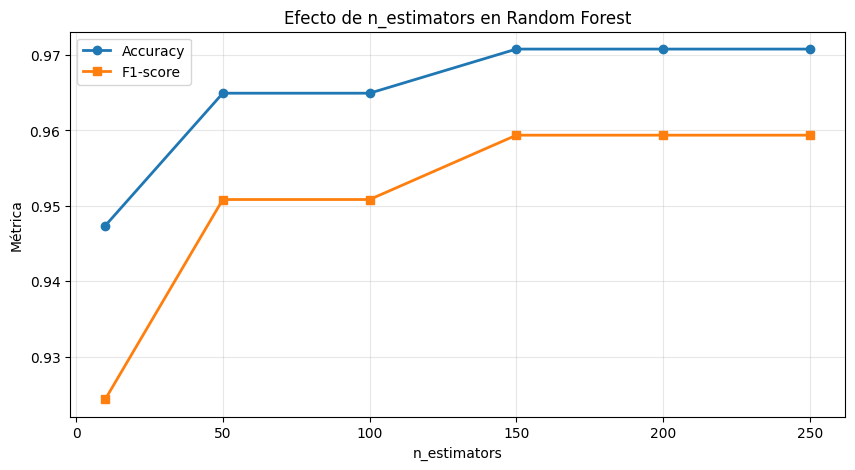

In [ ]:
resultados_estimadores = []
for n in [10, 50, 100, 150, 200, 250]:
    modelo_n = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo_n.fit(X_train_knn, y_train_knn)
    pred_n = modelo_n.predict(X_test_knn)
    
    resultados_estimadores.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test_knn, pred_n),
        "F1-score": f1_score(y_test_knn, pred_n, zero_division=0)
    })

df_estimadores = pd.DataFrame(resultados_estimadores)
print("Efecto de n_estimators:")
display(df_estimadores)

plt.figure(figsize=(10, 5))
plt.plot(df_estimadores["n_estimators"], df_estimadores["Accuracy"], marker="o", label="Accuracy", linewidth=2)
plt.plot(df_estimadores["n_estimators"], df_estimadores["F1-score"], marker="s", label="F1-score", linewidth=2)
plt.xlabel("n_estimators")
plt.ylabel("Métrica")
plt.title("Efecto de n_estimators en Random Forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Efecto de max_depth

Se entrenan modelos con distintas profundidades máximas para detectar overfitting:

Efecto de max_depth (Train vs Test):


,max_depth,Accuracy_train,Accuracy_test,F1_train,F1_test
0,3,0.974874,0.959064,0.965278,0.942149
1,5,0.989950,0.964912,0.986301,0.950820
2,7,0.997487,0.970760,0.996610,0.959350
3,10,1.000000,0.970760,1.000000,0.959350
4,15,1.000000,0.970760,1.000000,0.959350
5,20,1.000000,0.970760,1.000000,0.959350


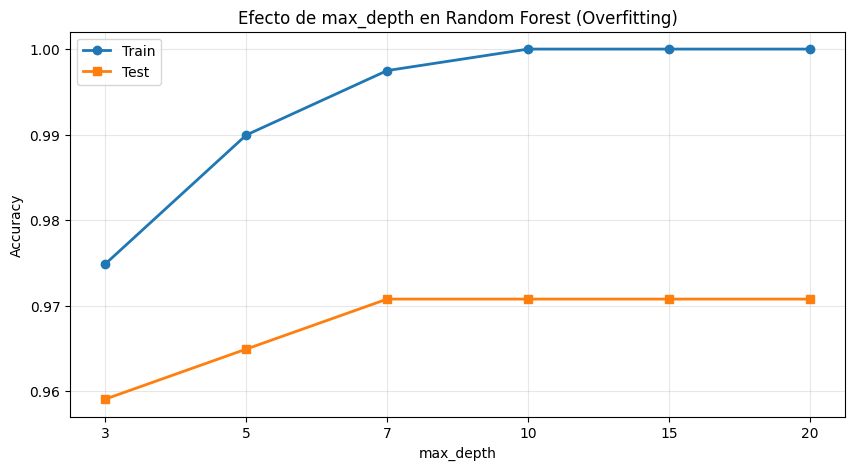

In [ ]:
resultados_depth = []
for depth in [3, 5, 7, 10, 15, 20]:
    modelo_d = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    modelo_d.fit(X_train_knn, y_train_knn)
    
    pred_train = modelo_d.predict(X_train_knn)
    pred_test = modelo_d.predict(X_test_knn)
    
    resultados_depth.append({
        "max_depth": str(depth),
        "Accuracy_train": accuracy_score(y_train_knn, pred_train),
        "Accuracy_test": accuracy_score(y_test_knn, pred_test),
        "F1_train": f1_score(y_train_knn, pred_train, zero_division=0),
        "F1_test": f1_score(y_test_knn, pred_test, zero_division=0)
    })

df_depth = pd.DataFrame(resultados_depth)
print("Efecto de max_depth (Train vs Test):")
display(df_depth)

plt.figure(figsize=(10, 5))
plt.plot(range(len(df_depth)), df_depth["Accuracy_train"], marker="o", label="Train", linewidth=2)
plt.plot(range(len(df_depth)), df_depth["Accuracy_test"], marker="s", label="Test", linewidth=2)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Efecto de max_depth en Random Forest (Overfitting)")
plt.xticks(range(len(df_depth)), df_depth["max_depth"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Conclusión del análisis de Random Forest

**Hallazgos principales:**

1. **Random Forest supera modelos individuales**: El ensamble robusto obtiene mejor F1-score que Árbol, KNN y Regresión Logística.

2. **n_estimators con rendimientos decrecientes**: Después de ~100-150 árboles, la mejora es marginal.

3. **max_depth controla overfitting**: Profundidades grandes (20+) pueden causar overfitting. Valores como 5-10 suelen ser óptimos.

4. **Importancia de características**: Las características más relevantes varían según el dataset, pero Random Forest las identifica automáticamente.

**Recomendación para este dataset:**
- Usar **Random Forest** como modelo final para clasificación de cáncer, configurado con `n_estimators=200` y `max_depth` entre 5-10.
- Alternativa interpretable: **Árbol de Decisión (max_depth=3)** si se prioriza explicabilidad sobre performance.

## 7. Análisis adicional usando Recall

Dado que en un problema médico los **falsos negativos** son especialmente peligrosos, ahora repetimos la comparación de modelos priorizando **Recall**. En este contexto, la pregunta clave es: **de todos los casos malignos reales, cuántos logra detectar el modelo?**

Por esta razón, en esta nueva subsección se usa Recall como métrica principal de selección y de recomendación final.

### 7.1 Comparación de modelos usando Recall

Ahora repetimos la comparación final usando **Recall** como métrica principal. Esto permite priorizar la capacidad del modelo para detectar casos malignos reales.

Comparación de modelos priorizando Recall:


,Modelo,Recall
0,Random Forest,0.921875
1,Regresión Logística,0.859375
2,KNN,0.828125
3,Árbol max_depth=3,0.781250


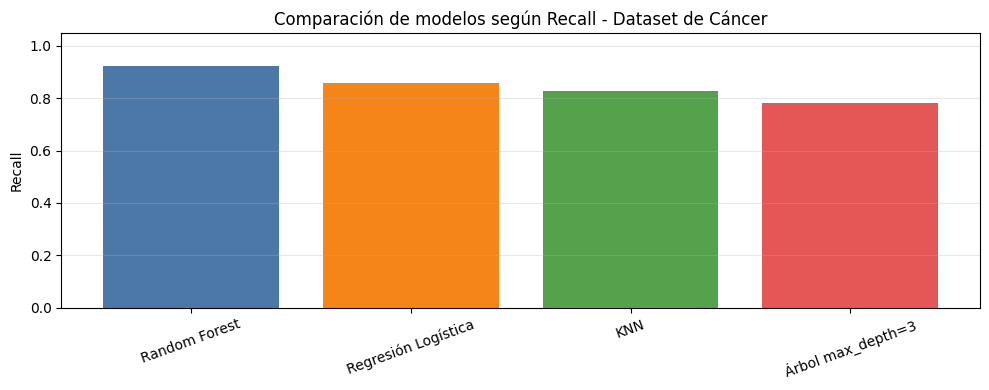

In [ ]:
resultados_recall = [
    {"Modelo": "Regresión Logística", "Recall": recall_score(y_test_knn, pred_logistica, zero_division=0)},
    {"Modelo": "KNN", "Recall": recall_score(y_test_knn, pred_knn, zero_division=0)},
    {"Modelo": "Árbol max_depth=3", "Recall": recall_score(y_test_knn, pred_arbol, zero_division=0)},
    {"Modelo": "Random Forest", "Recall": recall_score(y_test_knn, pred_rf, zero_division=0)}
]

comparacion_recall = pd.DataFrame(resultados_recall).sort_values("Recall", ascending=False).reset_index(drop=True)
print("Comparación de modelos priorizando Recall:")
display(comparacion_recall)

plt.figure(figsize=(10, 4))
plt.bar(comparacion_recall["Modelo"], comparacion_recall["Recall"], color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
plt.title("Comparación de modelos según Recall - Dataset de Cáncer")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Ajuste de Random Forest según Recall

Para reforzar la recomendación, analizamos cómo cambia el **Recall** al variar `n_estimators` y `max_depth` en Random Forest. El objetivo es identificar una configuración que mantenga una alta capacidad para detectar casos malignos sin perder generalización.

Efecto de n_estimators sobre Recall:


,n_estimators,Recall
0,10,0.859375
1,50,0.906250
2,100,0.906250
3,150,0.921875
4,200,0.921875
5,250,0.921875


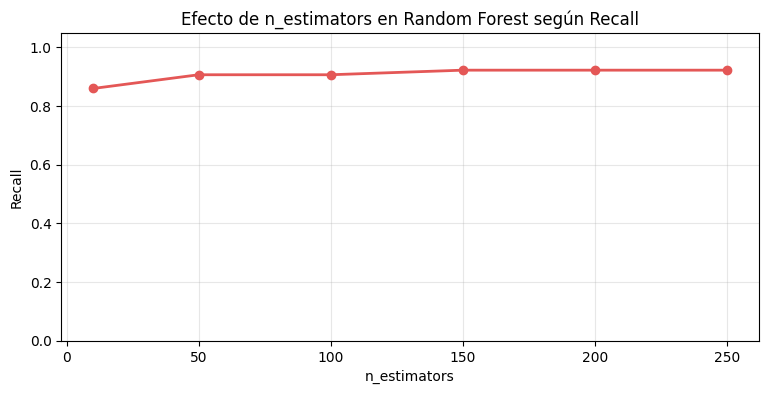

Efecto de max_depth sobre Recall (Train vs Test):


,max_depth,Recall_train,Recall_test
0,3,0.939189,0.890625
1,5,0.972973,0.906250
2,7,0.993243,0.921875
3,10,1.000000,0.921875
4,15,1.000000,0.921875
5,20,1.000000,0.921875


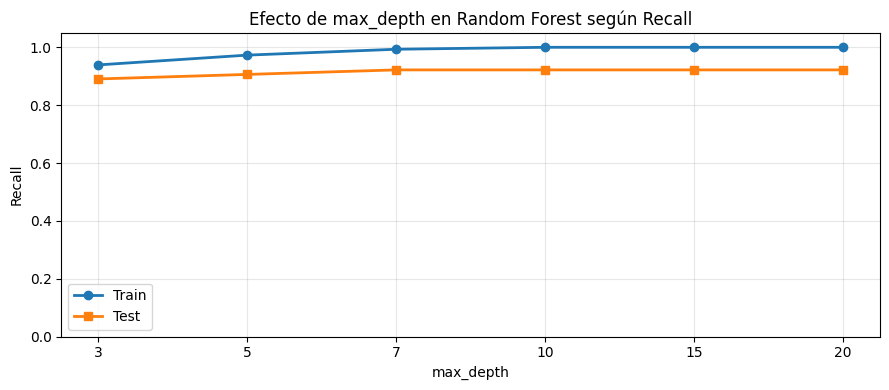

In [ ]:
resultados_recall_estimadores = []
for n in [10, 50, 100, 150, 200, 250]:
    modelo_n_recall = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo_n_recall.fit(X_train_knn, y_train_knn)
    pred_n_recall = modelo_n_recall.predict(X_test_knn)

    resultados_recall_estimadores.append({
        "n_estimators": n,
        "Recall": recall_score(y_test_knn, pred_n_recall, zero_division=0)
    })

df_recall_estimadores = pd.DataFrame(resultados_recall_estimadores)
print("Efecto de n_estimators sobre Recall:")
display(df_recall_estimadores)

plt.figure(figsize=(9, 4))
plt.plot(df_recall_estimadores["n_estimators"], df_recall_estimadores["Recall"], marker="o", linewidth=2, color="#E45756")
plt.xlabel("n_estimators")
plt.ylabel("Recall")
plt.title("Efecto de n_estimators en Random Forest según Recall")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

resultados_recall_depth = []
for depth in [3, 5, 7, 10, 15, 20]:
    modelo_d_recall = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    modelo_d_recall.fit(X_train_knn, y_train_knn)

    pred_train_recall = modelo_d_recall.predict(X_train_knn)
    pred_test_recall = modelo_d_recall.predict(X_test_knn)

    resultados_recall_depth.append({
        "max_depth": str(depth),
        "Recall_train": recall_score(y_train_knn, pred_train_recall, zero_division=0),
        "Recall_test": recall_score(y_test_knn, pred_test_recall, zero_division=0)
    })

df_recall_depth = pd.DataFrame(resultados_recall_depth)
print("Efecto de max_depth sobre Recall (Train vs Test):")
display(df_recall_depth)

plt.figure(figsize=(9, 4))
plt.plot(range(len(df_recall_depth)), df_recall_depth["Recall_train"], marker="o", label="Train", linewidth=2)
plt.plot(range(len(df_recall_depth)), df_recall_depth["Recall_test"], marker="s", label="Test", linewidth=2)
plt.xlabel("max_depth")
plt.ylabel("Recall")
plt.title("Efecto de max_depth en Random Forest según Recall")
plt.xticks(range(len(df_recall_depth)), df_recall_depth["max_depth"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 7.3 Conclusión basada en Recall

Si el criterio principal es minimizar falsos negativos, la recomendación debe priorizar el modelo con mayor **Recall**. En este dataset, eso significa elegir el modelo que detecte la mayor proporción de casos malignos reales, aunque ocasionalmente incremente falsos positivos.

**Conclusión técnica:**
- Si Random Forest mantiene el mejor Recall, sigue siendo la opción recomendada.
- Si otro modelo empata o supera ligeramente su Recall, se debe revisar también su estabilidad, precisión y capacidad de generalización antes de decidir.
- En un contexto clínico, **Recall pesa más que Accuracy** porque perder un caso maligno es mucho más grave que generar una alarma adicional.

---
---

# Árbol de Decisión con PCA


# Arbol de Decision y Analisis de Componentes Principales (PCA)

Este notebook organiza y compara el rendimiento de un Arbol de Decision con y sin PCA (5 componentes) para clasificar el diagnostico de cancer.

**Estructura del Documento:**
1. **PCA (5 Componentes)**
   - Loadings (Grafica de barras)
   - Biplot (Observaciones y variables)
   - Scree Plot
2. **Modelado y Evaluacion**
   - Preparacion de datos, escalado y PCA
   - Ajuste de hiperparametros priorizando `Recall`
   - Comparacion de metricas (sin PCA vs con PCA)
3. **Matrices de Confusion**
   - Analisis de falsos positivos y falsos negativos
4. **Interpretabilidad**
   - Importancia de variables y visualizacion del arbol
5. **Conclusiones**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
# Carga y limpieza de datos
df = pd.read_csv('Cancer_Data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Limpiar nombres de columna: eliminar espacios y comillas dobles
df.columns = df.columns.str.strip().str.replace('\"', '')

# Limpiar y codificar la variable objetivo (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (necesario para PCA; en arboles no es obligatorio, pero lo usamos para consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos cargados y escalados con exito.')

Datos cargados y escalados con exito.


---
## 1. PCA (5 Componentes)

In [ ]:
# Aplicacion de PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 1.1 Loadings (Grafica de Barras)
Analizamos que variables originales tienen mayor peso en las componentes principales.

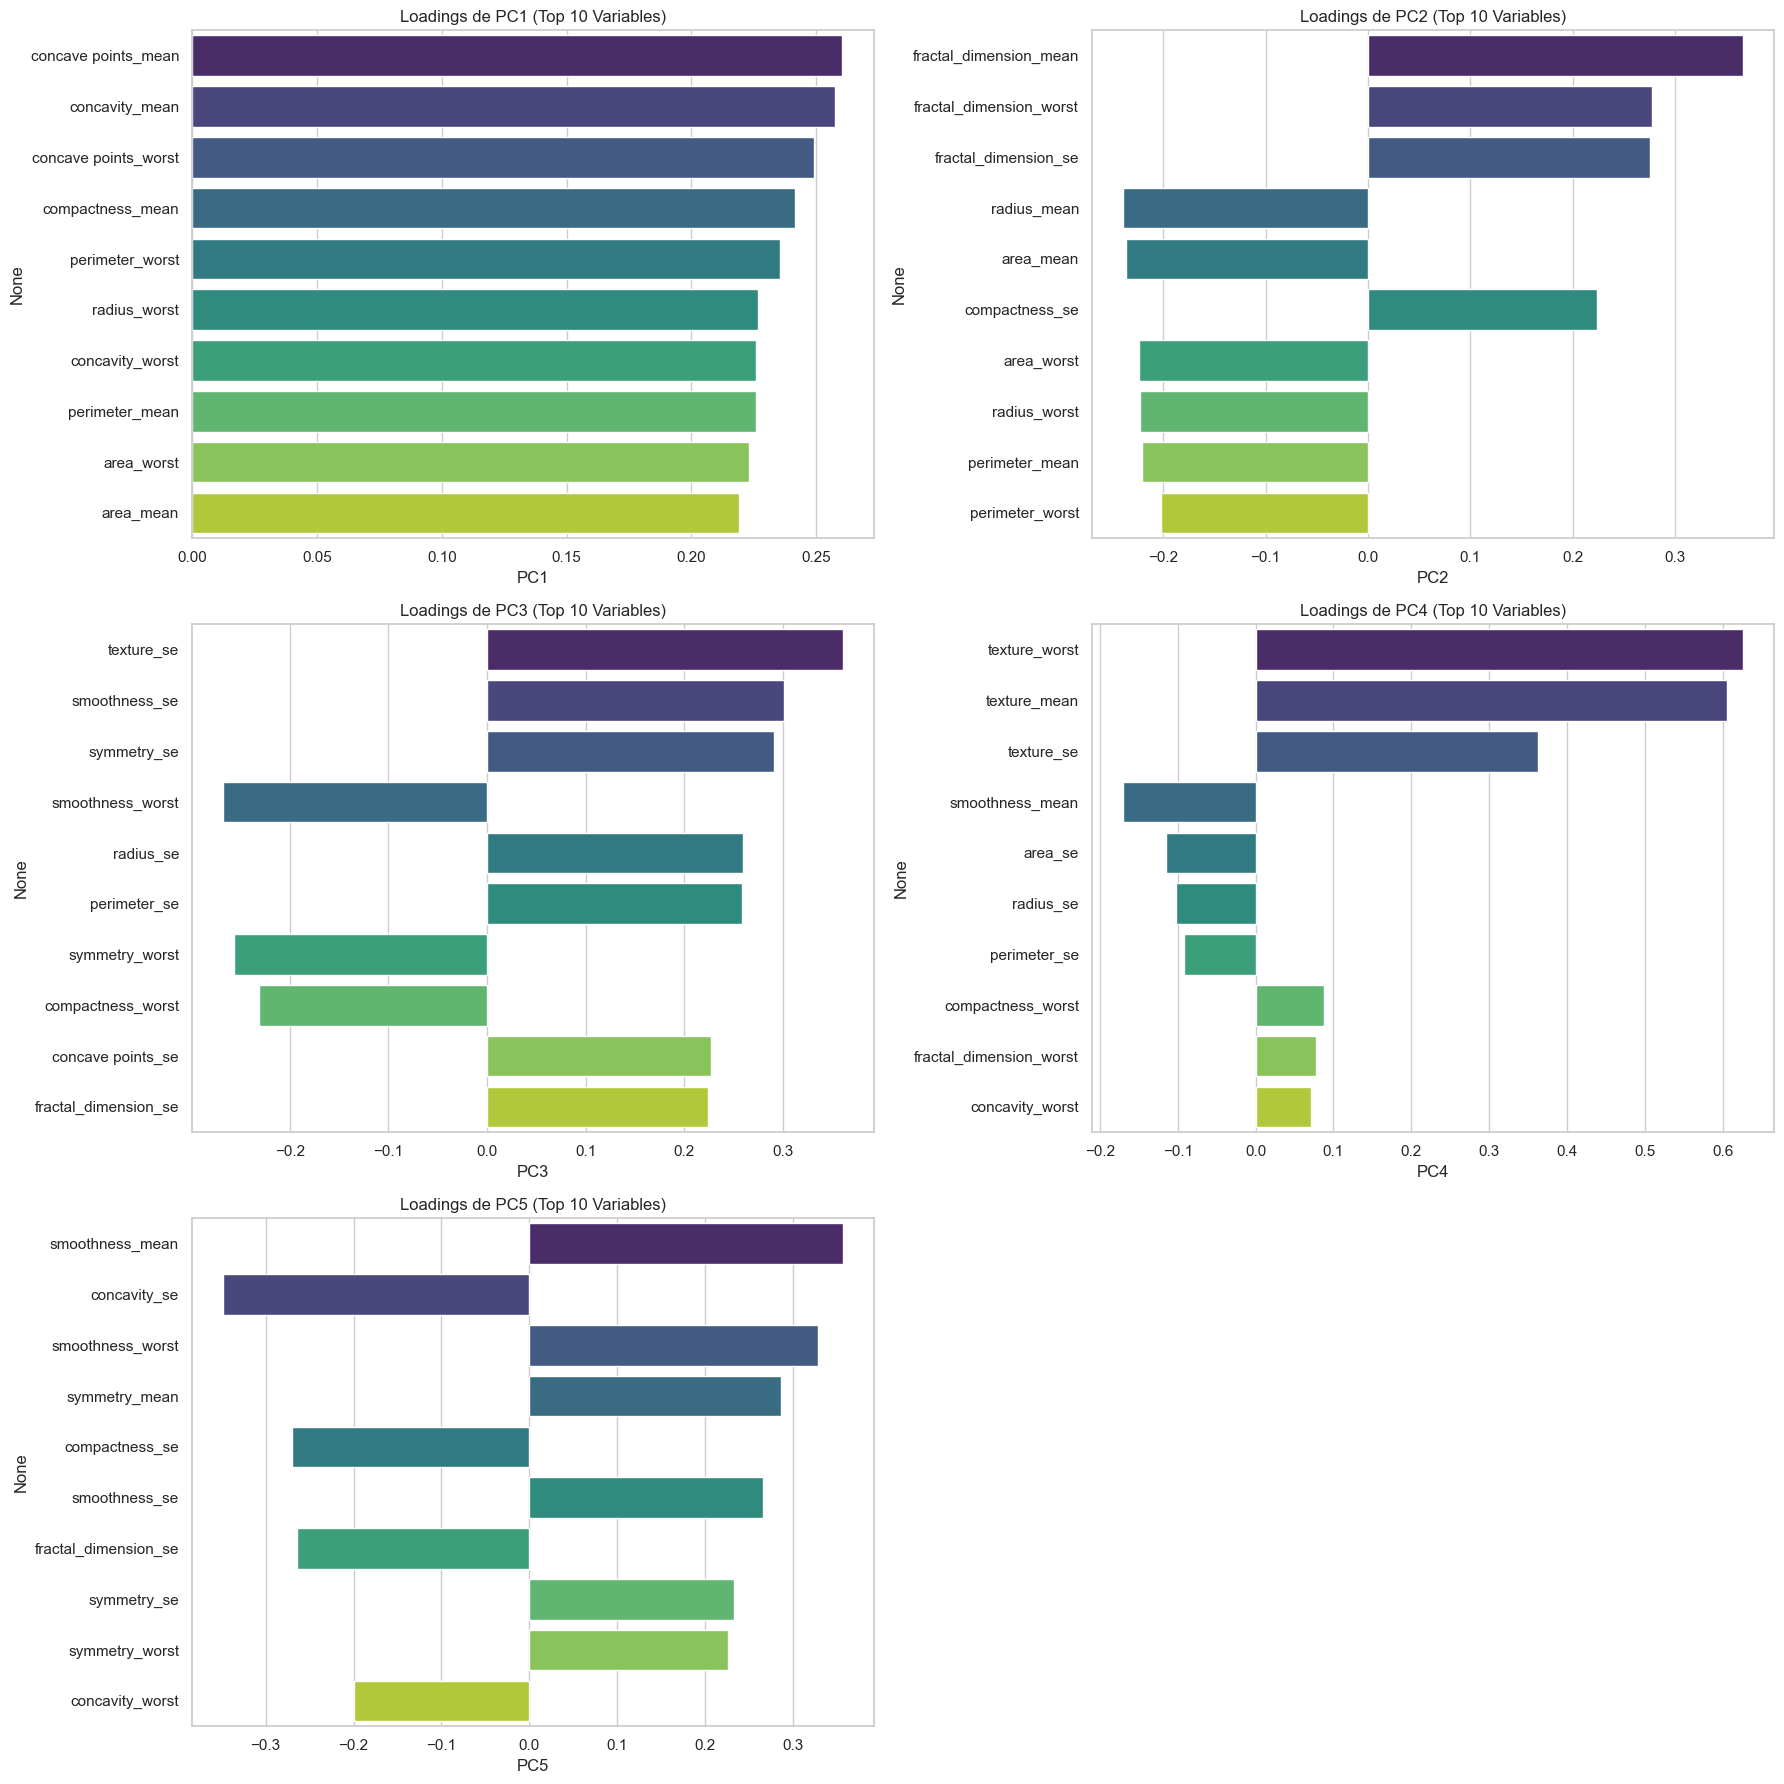

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X.columns
)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i in range(5):
    pc_name = f'PC{i+1}'
    top_pc_loadings = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    sns.barplot(
        x=loadings.loc[top_pc_loadings, pc_name],
        y=top_pc_loadings,
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'Loadings de {pc_name} (Top 10 Variables)')

if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 1.2 Biplot
Proyectamos observaciones y variables en el espacio de PC1 vs PC2.

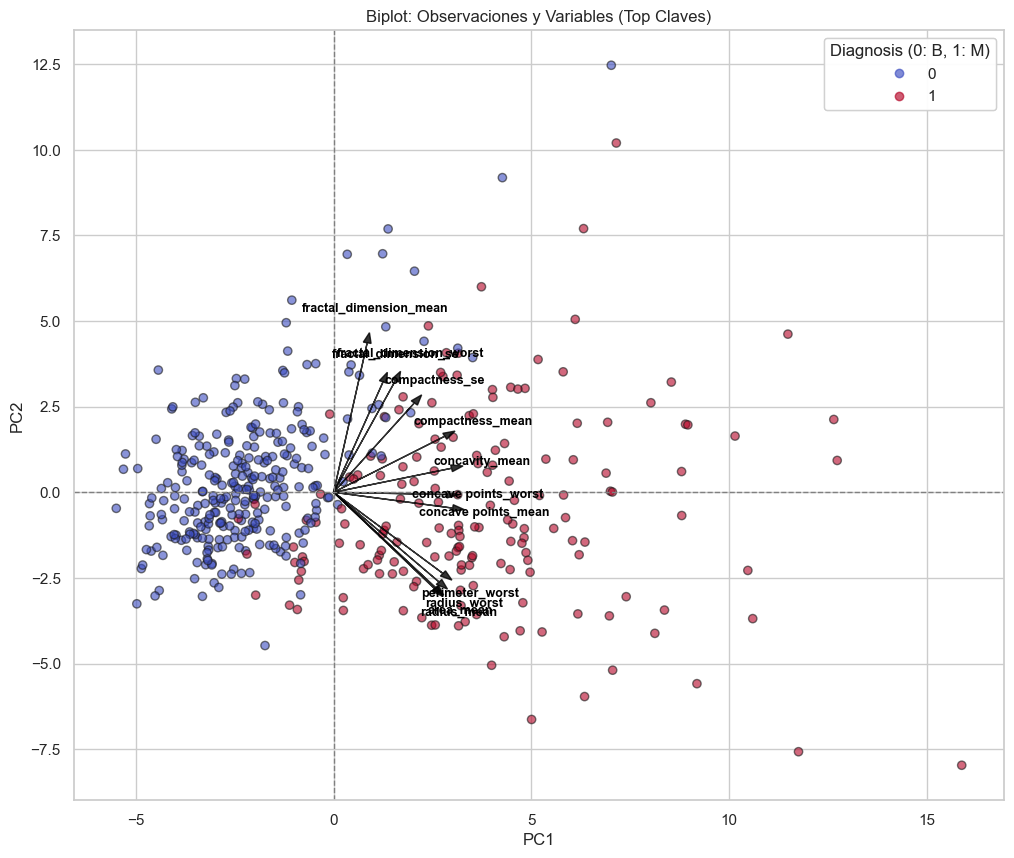

In [ ]:
def biplot(score, coeff, labels=None):
    fig, ax = plt.subplots(figsize=(12, 10))
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    scatter = ax.scatter(xs, ys, c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
    legend = ax.legend(*scatter.legend_elements(), title='Diagnosis (0: B, 1: M)')
    ax.add_artist(legend)

    arrow_multiplier = max(xs.max(), ys.max()) * 0.8

    for i in range(n):
        ax.arrow(
            0, 0,
            coeff[i, 0] * arrow_multiplier,
            coeff[i, 1] * arrow_multiplier,
            color='black', alpha=0.8, head_width=0.2, length_includes_head=True
        )
        if labels is not None:
            ax.text(
                coeff[i, 0] * arrow_multiplier * 1.15,
                coeff[i, 1] * arrow_multiplier * 1.15,
                labels[i], color='black', ha='center', va='center', fontsize=9, fontweight='bold'
            )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Biplot: Observaciones y Variables (Top Claves)')
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.show()

top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(6).index
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(6).index
top_vars = list(set(top_pc1).union(set(top_pc2)))
coeff_subset = pca.components_.T[X.columns.get_indexer(top_vars)]

biplot(X_train_pca, coeff_subset, labels=top_vars)

### 1.3 Scree Plot
Graficamos la varianza explicada por cada una de las 5 componentes y su varianza acumulada.

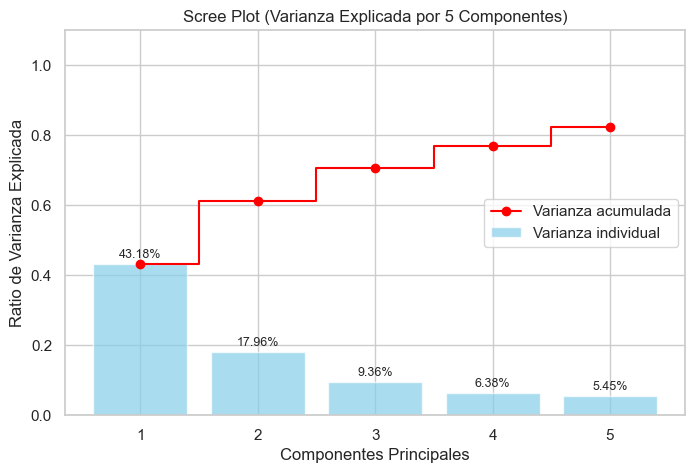

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, 6), explained_variance, alpha=0.7, align='center', label='Varianza individual', color='skyblue')
plt.step(range(1, 6), cumulative_variance, where='mid', label='Varianza acumulada', color='red', marker='o')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontsize=9)

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks(range(1, 6))
plt.title('Scree Plot (Varianza Explicada por 5 Componentes)')
plt.legend(loc='center right')
plt.ylim(0, 1.1)
plt.show()

---
## 2. Modelado y Evaluacion
Ajustamos hiperparametros priorizando **Recall** (evitar falsos negativos). Despues revisamos el **F1-Score** como balance entre precision y recall.

In [ ]:
def evaluar_modelo(nombre_modelo, y_true, y_pred):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

def entrenar_y_predecir(modelo, X_tr, X_te, y_tr):
    modelo.fit(X_tr, y_tr)
    return modelo.predict(X_te)

def seleccionar_mejor(df):
    return df.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False).iloc[0]

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

resultados_sin_pca = []
resultados_con_pca = []

for max_depth in param_grid['max_depth']:
    for min_samples_split in param_grid['min_samples_split']:
        for min_samples_leaf in param_grid['min_samples_leaf']:
            params = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'random_state': 42
            }

            dt_sin = DecisionTreeClassifier(**params)
            pred_sin = entrenar_y_predecir(dt_sin, X_train, X_test, y_train)
            met_sin = evaluar_modelo('Arbol sin PCA', y_test, pred_sin)
            met_sin.update(params)
            resultados_sin_pca.append(met_sin)

            dt_con = DecisionTreeClassifier(**params)
            pred_con = entrenar_y_predecir(dt_con, X_train_pca, X_test_pca, y_train)
            met_con = evaluar_modelo('Arbol con PCA', y_test, pred_con)
            met_con.update(params)
            resultados_con_pca.append(met_con)

df_sin = pd.DataFrame(resultados_sin_pca)
df_con = pd.DataFrame(resultados_con_pca)

In [ ]:
df_sin_orden = df_sin.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False)
df_con_orden = df_con.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False)

best_sin = seleccionar_mejor(df_sin)
best_con = seleccionar_mejor(df_con)

display(df_sin_orden.head(5))
display(df_con_orden.head(5))

,Modelo,Accuracy,Precision,Recall,F1-Score,max_depth,min_samples_split,min_samples_leaf,random_state
18,Arbol sin PCA,0.938596,0.926829,0.904762,0.915663,7.0,2,1,42
27,Arbol sin PCA,0.921053,0.902439,0.880952,0.891566,NaN,2,1,42
28,Arbol sin PCA,0.929825,0.947368,0.857143,0.900000,NaN,2,2,42
21,Arbol sin PCA,0.921053,0.923077,0.857143,0.888889,7.0,5,1,42
30,Arbol sin PCA,0.921053,0.923077,0.857143,0.888889,NaN,5,1,42


,Modelo,Accuracy,Precision,Recall,F1-Score,max_depth,min_samples_split,min_samples_leaf,random_state
19,Arbol con PCA,0.956140,0.951220,0.928571,0.939759,7.0,2,2,42
28,Arbol con PCA,0.947368,0.928571,0.928571,0.928571,NaN,2,2,42
10,Arbol con PCA,0.947368,0.950000,0.904762,0.926829,5.0,2,2,42
0,Arbol con PCA,0.912281,0.863636,0.904762,0.883721,3.0,2,1,42
1,Arbol con PCA,0.912281,0.863636,0.904762,0.883721,3.0,2,2,42


In [ ]:
def normalizar_max_depth(valor):
    return None if pd.isna(valor) else int(valor)

best_params_sin = {
    'max_depth': normalizar_max_depth(best_sin['max_depth']),
    'min_samples_split': int(best_sin['min_samples_split']),
    'min_samples_leaf': int(best_sin['min_samples_leaf']),
    'random_state': 42
}
best_params_con = {
    'max_depth': normalizar_max_depth(best_con['max_depth']),
    'min_samples_split': int(best_con['min_samples_split']),
    'min_samples_leaf': int(best_con['min_samples_leaf']),
    'random_state': 42
}

dt_best_sin = DecisionTreeClassifier(**best_params_sin)
dt_best_con = DecisionTreeClassifier(**best_params_con)

pred_best_sin = entrenar_y_predecir(dt_best_sin, X_train, X_test, y_train)
pred_best_con = entrenar_y_predecir(dt_best_con, X_train_pca, X_test_pca, y_train)

resumen_metricas = pd.DataFrame([
    evaluar_modelo('Arbol sin PCA', y_test, pred_best_sin),
    evaluar_modelo('Arbol con PCA (5 comp)', y_test, pred_best_con)
])

display(resumen_metricas)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Arbol sin PCA,0.938596,0.926829,0.904762,0.915663
1,Arbol con PCA (5 comp),0.956140,0.951220,0.928571,0.939759


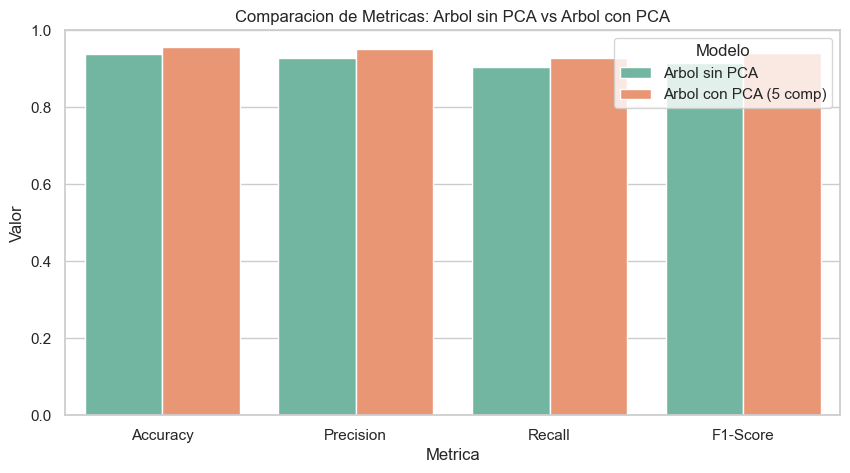

In [ ]:
resumen_melt = resumen_metricas.melt(id_vars='Modelo', var_name='Metrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(data=resumen_melt, x='Metrica', y='Valor', hue='Modelo', palette='Set2')
plt.ylim(0, 1)
plt.title('Comparacion de Metricas: Arbol sin PCA vs Arbol con PCA')
plt.show()

---
## 3. Matrices de Confusion
Analizamos falsos positivos y falsos negativos, con enfasis en los falsos negativos por su impacto medico.

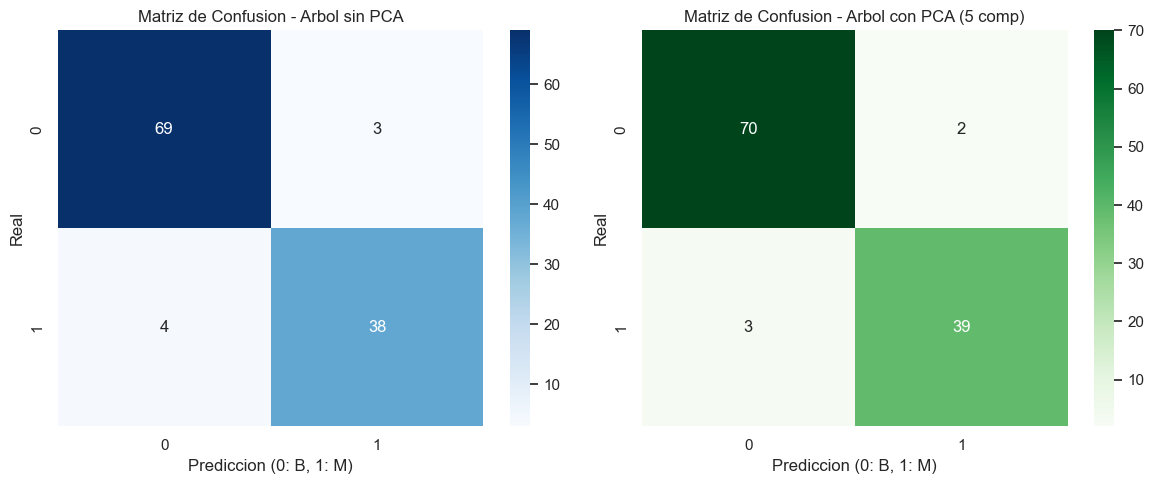

Falsos Negativos (Maligno clasificado como Benigno):
 - Sin PCA: 4
 - Con PCA: 3
Falsos Positivos (Benigno clasificado como Maligno):
 - Sin PCA: 3
 - Con PCA: 2


In [ ]:
cm_sin = confusion_matrix(y_test, pred_best_sin)
cm_con = confusion_matrix(y_test, pred_best_con)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_sin, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusion - Arbol sin PCA')
axes[0].set_xlabel('Prediccion (0: B, 1: M)')
axes[0].set_ylabel('Real')

sns.heatmap(cm_con, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusion - Arbol con PCA (5 comp)')
axes[1].set_xlabel('Prediccion (0: B, 1: M)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

fn_sin = cm_sin[1, 0]
fp_sin = cm_sin[0, 1]
fn_con = cm_con[1, 0]
fp_con = cm_con[0, 1]

print('Falsos Negativos (Maligno clasificado como Benigno):')
print(f' - Sin PCA: {fn_sin}')
print(f' - Con PCA: {fn_con}')
print('Falsos Positivos (Benigno clasificado como Maligno):')
print(f' - Sin PCA: {fp_sin}')
print(f' - Con PCA: {fp_con}')

---
## 4. Interpretabilidad
El Arbol de Decision es mas interpretable que KNN porque se puede visualizar y explicar mediante reglas. Con PCA, la interpretabilidad baja porque las componentes principales son combinaciones de variables originales.

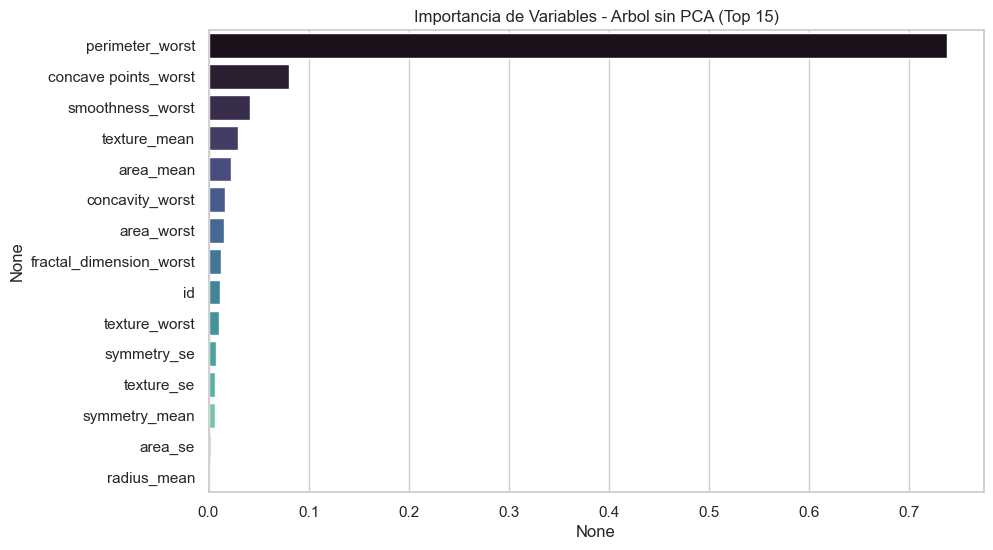

In [ ]:
importancias = pd.Series(dt_best_sin.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.head(15), y=importancias.head(15).index, palette='mako')
plt.title('Importancia de Variables - Arbol sin PCA (Top 15)')
plt.show()

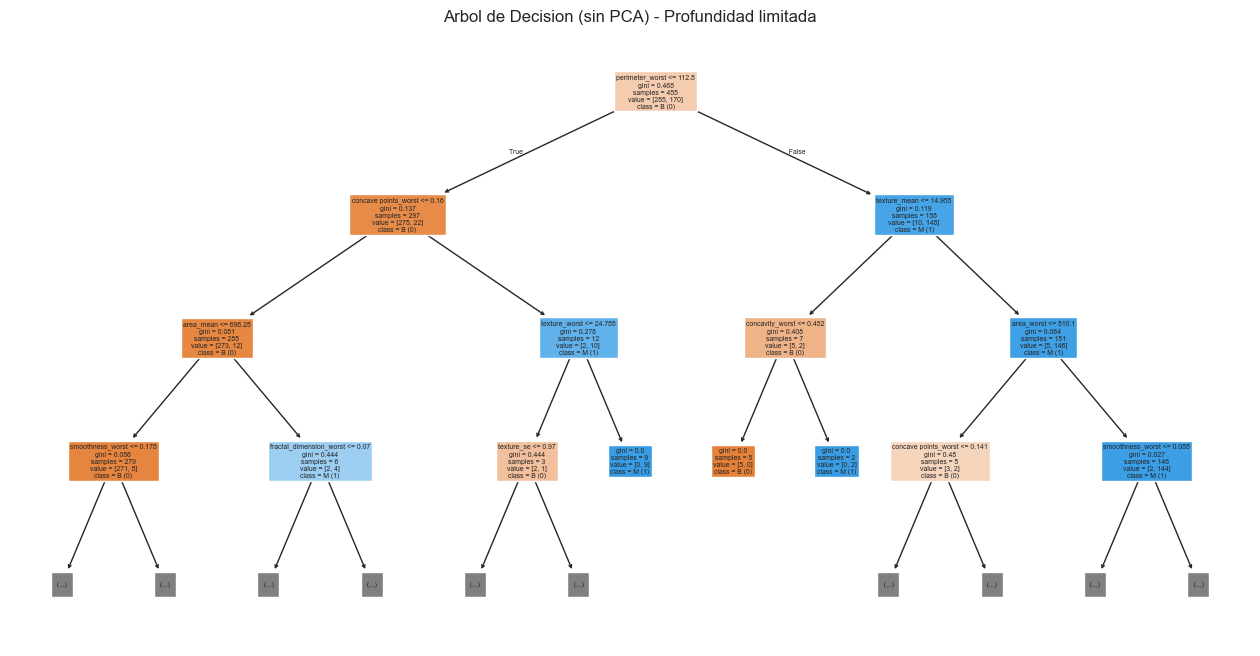

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt_best_sin,
    feature_names=X.columns,
    class_names=['B (0)', 'M (1)'],
    filled=True,
    max_depth=3
)
plt.title('Arbol de Decision (sin PCA) - Profundidad limitada')
plt.show()

---
## 5. Conclusiones
En esta seccion se resume el modelo con mejor recall, el mejor F1-Score y el balance entre rendimiento e interpretabilidad.

In [ ]:
recall_sin = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol sin PCA', 'Recall'].values[0]
recall_con = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol con PCA (5 comp)', 'Recall'].values[0]
f1_sin = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol sin PCA', 'F1-Score'].values[0]
f1_con = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol con PCA (5 comp)', 'F1-Score'].values[0]

mejor_recall = 'Arbol sin PCA' if recall_sin >= recall_con else 'Arbol con PCA (5 comp)'
mejor_f1 = 'Arbol sin PCA' if f1_sin >= f1_con else 'Arbol con PCA (5 comp)'

conclusion_lines = [
    '### Conclusiones Interpretativas',
    f'- **Mejor Recall:** {mejor_recall} (sin PCA: {recall_sin:.3f}, con PCA: {recall_con:.3f}).',
    f'- **Mejor F1-Score:** {mejor_f1} (sin PCA: {f1_sin:.3f}, con PCA: {f1_con:.3f}).',
    '- **PCA vs Sin PCA:** PCA puede reducir dimensionalidad y mejorar generalizacion, pero pierde interpretabilidad directa.',
    '- **Interpretabilidad:** El arbol sin PCA permite reglas claras y variables originales, lo cual es crucial en contexto medico.',
    '- **Recomendacion:** Priorizar el modelo con mejor recall. Si ambos son similares, elegir el sin PCA por su interpretabilidad.'
]

display(Markdown('\n'.join(conclusion_lines)))

### Conclusiones Interpretativas
- **Mejor Recall:** Arbol con PCA (5 comp) (sin PCA: 0.905, con PCA: 0.929).
- **Mejor F1-Score:** Arbol con PCA (5 comp) (sin PCA: 0.916, con PCA: 0.940).
- **PCA vs Sin PCA:** PCA puede reducir dimensionalidad y mejorar generalizacion, pero pierde interpretabilidad directa.
- **Interpretabilidad:** El arbol sin PCA permite reglas claras y variables originales, lo cual es crucial en contexto medico.
- **Recomendacion:** Priorizar el modelo con mejor recall. Si ambos son similares, elegir el sin PCA por su interpretabilidad.

---
---

# K-Nearest Neighbors (KNN) con PCA


# KNN y Análisis de Componentes Principales (PCA)

Este notebook organiza y compara el rendimiento del modelo K-Nearest Neighbors (KNN) con y sin PCA (5 componentes).

**Estructura del Documento:**
1. **PCA (5 Componentes)**
   - Loadings (Gráfica de barras)
   - Biplot (Observaciones y variables)
   - Scree Plot
2. **Evaluación de Rendimiento**
   - Comparación base: Variables escaladas vs. sin escalar.
   - Evolución de métricas (`Accuracy`, `Precision`, `Recall`, `F1-Score`) iterando sobre `K` (Sin PCA vs Con PCA).
3. **Matrices de Confusión**
   - Resultados detallados de falsos positivos y negativos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline # Importamos Pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
# Carga y Limpieza de datos
df = pd.read_csv('Cancer_Data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Limpiar nombres de columna: eliminar espacios y comillas dobles
df.columns = df.columns.str.strip().str.replace('"', '')

# Limpiar valores de la columna 'diagnosis' y codificarlos (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado general de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos cargados y escalados con éxito.")

Datos cargados y escalados con éxito.


---
## 1. PCA (5 Componentes)

In [ ]:
# Aplicación de PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 1.1 Loadings (Gráfica de Barras)
Analizamos qué variables originales tienen mayor peso o aporte en la formación de la primera (PC1) y segunda (PC2) componente principal.

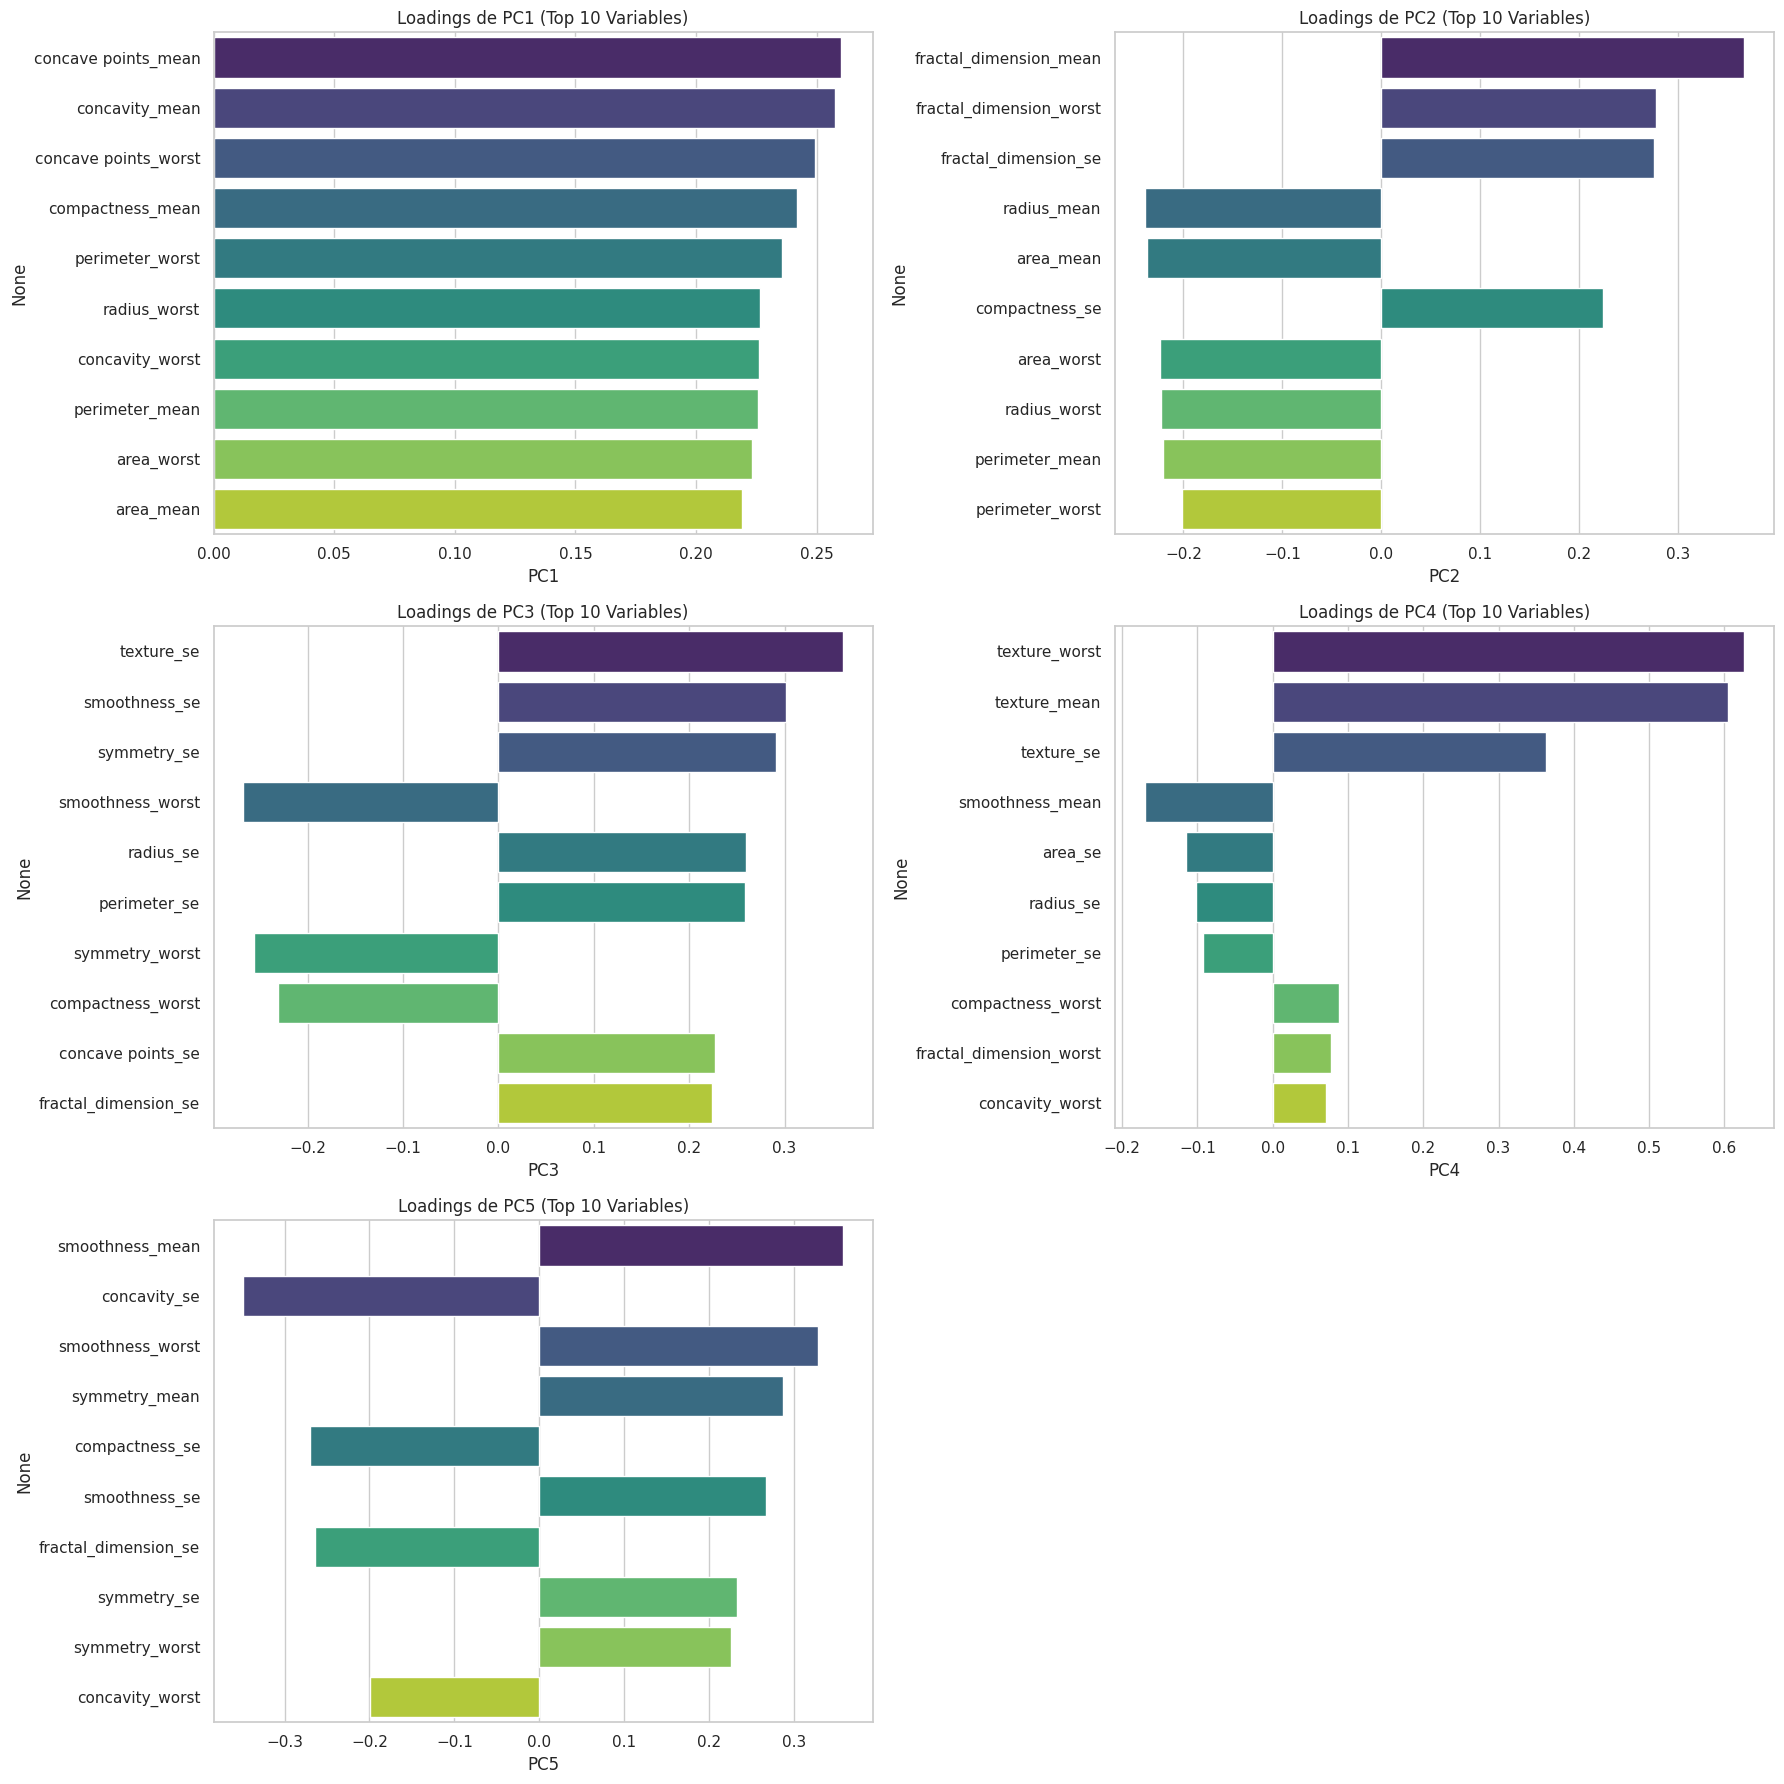

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=X.columns)

fig, axes = plt.subplots(3, 2, figsize=(18, 18)) # Create 3 rows, 2 columns for 5 plots + 1 empty
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i in range(5):
    pc_name = f'PC{i+1}'
    top_pc_loadings = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    sns.barplot(x=loadings.loc[top_pc_loadings, pc_name], y=top_pc_loadings, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Loadings de {pc_name} (Top 10 Variables)')

# Hide the unused 6th subplot if there are only 5 components
if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 1.2 Biplot
Proyectamos observaciones y variables en el espacio de PC1 vs PC2.

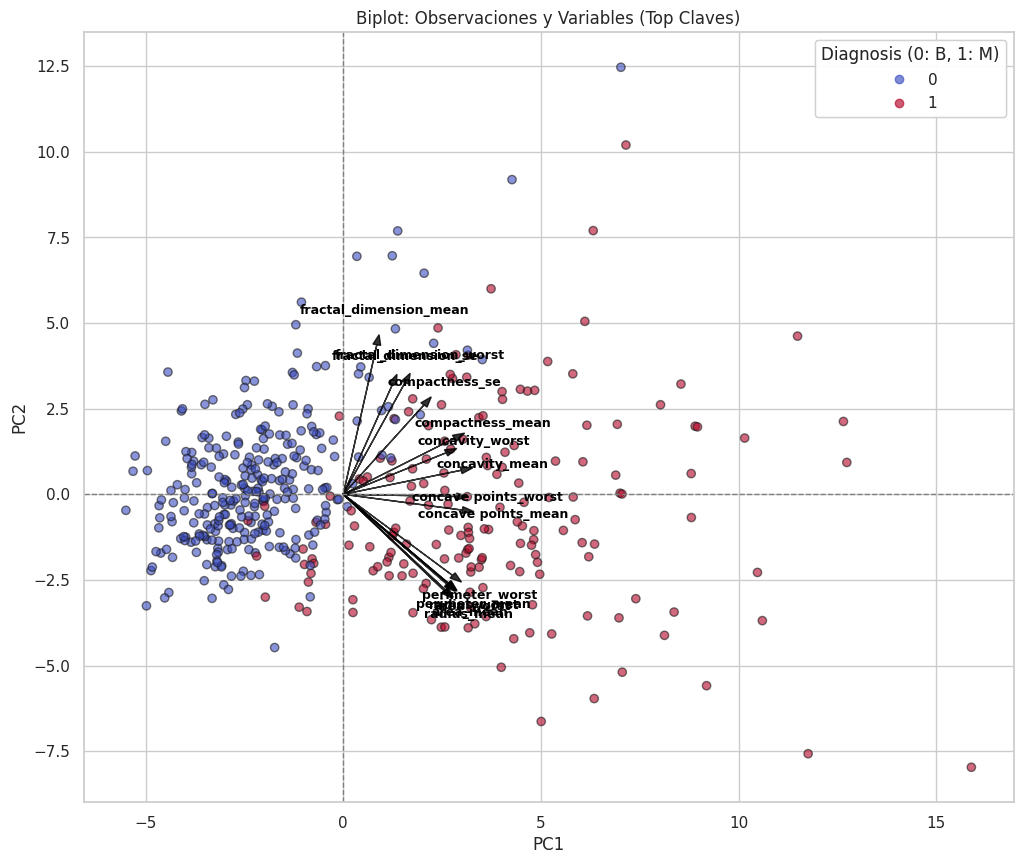

In [ ]:
def biplot(score, coeff, labels=None):
    fig, ax = plt.subplots(figsize=(12, 10))

    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    scatter = ax.scatter(xs, ys, c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
    legend = ax.legend(*scatter.legend_elements(), title="Diagnosis (0: B, 1: M)")
    ax.add_artist(legend)

    arrow_multiplier = max(xs.max(), ys.max()) * 0.8

    for i in range(n):
        ax.arrow(0, 0, coeff[i, 0] * arrow_multiplier, coeff[i, 1] * arrow_multiplier,
                 color='black', alpha=0.8, head_width=0.2, length_includes_head=True)
        if labels is not None:
            ax.text(coeff[i, 0] * arrow_multiplier * 1.15, coeff[i, 1] * arrow_multiplier * 1.15,
                    labels[i], color='black', ha='center', va='center', fontsize=9, fontweight='bold')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot: Observaciones y Variables (Top Claves)")
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.show()

top_vars = list(set(top_pc1).union(set(top_pc2)))
coeff_subset = pca.components_.T[X.columns.get_indexer(top_vars)]
biplot(X_train_pca, coeff_subset, labels=top_vars)

### 1.3 Scree Plot
Graficamos la varianza explicada por cada una de las 5 componentes y su varianza acumulada.

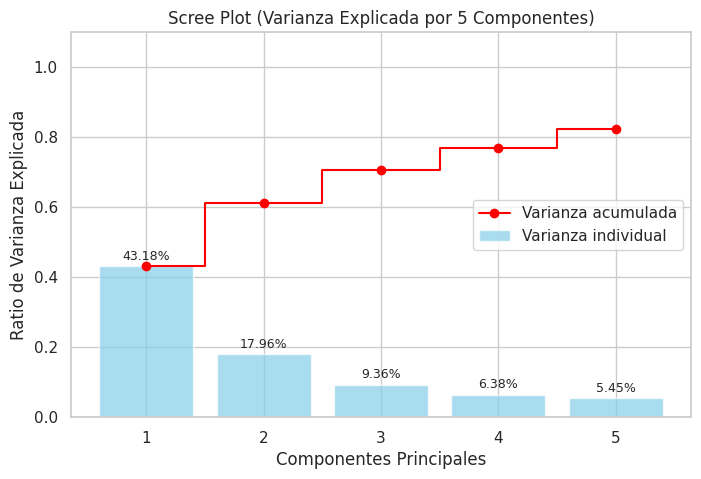

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, 6), explained_variance, alpha=0.7, align='center', label='Varianza individual', color='skyblue')
plt.step(range(1, 6), cumulative_variance, where='mid', label='Varianza acumulada', color='red', marker='o')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontsize=9)

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks(range(1, 6))
plt.title('Scree Plot (Varianza Explicada por 5 Componentes)')
plt.legend(loc='center right')
plt.ylim(0, 1.1)
plt.show()

---
## 2. Evaluación de Rendimiento

### 2.1 Comparación: Variables Escaladas vs Sin Escalar
Primero, probamos por qué KNN requiere datos escalados utilizando un K=5 como referencia.

In [ ]:
# KNN sin escalar los datos
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# KNN con datos escalados
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print("--- Impacto del Escalado en KNN (K=5) ---")
print(f"Accuracy SIN escalar: {acc_unscaled:.4f}")
print(f"Accuracy CON escalado: {acc_scaled:.4f}")
print("\nDe aquí en adelante utilizamos únicamente datos ESCALADOS.")

--- Impacto del Escalado en KNN (K=5) ---
Accuracy SIN escalar: 0.7544
Accuracy CON escalado: 0.9561

De aquí en adelante utilizamos únicamente datos ESCALADOS.


In [ ]:
def evaluar_modelo(nombre_modelo, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

In [ ]:
# KNN sin escalado
knn_sin = KNeighborsClassifier(n_neighbors=5)
knn_sin.fit(X_train, y_train)
pred_sin = knn_sin.predict(X_test)

# KNN con escalado usando Pipeline
knn_con = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_con.fit(X_train, y_train)
pred_con = knn_con.predict(X_test)

# Comparación de resultados
comparacion_knn = pd.DataFrame([
    evaluar_modelo("KNN sin escalado", y_test, pred_sin),
    evaluar_modelo("KNN con escalado", y_test, pred_con)
])

display(comparacion_knn)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,KNN sin escalado,0.754386,0.769231,0.476190,0.588235
1,KNN con escalado,0.956140,0.974359,0.904762,0.938272


Metodológicamente, la versión con escalado es más correcta porque el KNN se basa en la distancia entre los puntos. Sin escalado, las características con rangos de valores más grandes pueden dominar la métrica de distancia, llevando a resultados sesgados y un rendimiento subóptimo.

### 2.2 Métricas de Rendimiento (Sin PCA vs Con PCA 5 Comp)
Calculamos `Accuracy`, `Precision`, `Recall` y `F1-Score` para valores de K del 1 al 20.

In [ ]:
k_values = range(1, 31)
metrics = {'K': [], 'Metrica': [], 'Valor': [], 'Modelo': []}

for k in k_values:
    # --- Modelo Sin PCA (Escalado) ---
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    metrics['K'].extend([k]*4)
    metrics['Modelo'].extend(['Sin PCA']*4)
    metrics['Metrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    metrics['Valor'].extend([
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

    # --- Modelo Con PCA (5 componentes) ---
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train)
    y_pred_pca = knn_pca.predict(X_test_pca)

    metrics['K'].extend([k]*4)
    metrics['Modelo'].extend(['Con PCA (5 Comp)']*4)
    metrics['Metrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    metrics['Valor'].extend([
        accuracy_score(y_test, y_pred_pca),
        precision_score(y_test, y_pred_pca),
        recall_score(y_test, y_pred_pca),
        f1_score(y_test, y_pred_pca)
    ])

df_metrics = pd.DataFrame(metrics)

In [ ]:
# Pivot the table to get metrics as columns and models as sub-columns
df_comparison_metrics = df_metrics.pivot_table(
    index='K',
    columns=['Metrica', 'Modelo'],
    values='Valor'
)

# Flatten the multi-level columns and rename them to match the user's request
new_column_names = []
for metric, model in df_comparison_metrics.columns:
    model_name_prefix = ''
    if 'Sin PCA' in model:
        model_name_prefix = 'KNN_sin_PCA'
    elif 'Con PCA' in model:
        model_name_prefix = 'KNN_con_PCA'
    else:
        model_name_prefix = model.replace(' ', '_') # Fallback
    new_column_names.append(f'{model_name_prefix}_{metric}')

df_comparison_metrics.columns = new_column_names

# Reset index to make 'K' a regular column
df_comparison_metrics = df_comparison_metrics.reset_index()

# Reorder columns: K first, then group by metric (Sin PCA, Con PCA)
ordered_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

final_columns_order = ['K']
for metric in ordered_metrics:
    final_columns_order.append(f'KNN_sin_PCA_{metric}')
    final_columns_order.append(f'KNN_con_PCA_{metric}')

df_final_comparison = df_comparison_metrics[final_columns_order]

display(df_final_comparison)

,K,KNN_sin_PCA_Accuracy,KNN_con_PCA_Accuracy,KNN_sin_PCA_Precision,KNN_con_PCA_Precision,KNN_sin_PCA_Recall,KNN_con_PCA_Recall,KNN_sin_PCA_F1-Score,KNN_con_PCA_F1-Score
0,1,0.929825,0.947368,0.925000,0.973684,0.880952,0.880952,0.902439,0.925000
1,2,0.912281,0.921053,0.970588,0.971429,0.785714,0.809524,0.868421,0.883117
2,3,0.938596,0.938596,0.972973,0.972973,0.857143,0.857143,0.911392,0.911392
3,4,0.947368,0.938596,1.000000,0.972973,0.857143,0.857143,0.923077,0.911392
4,5,0.956140,0.947368,0.974359,0.973684,0.904762,0.880952,0.938272,0.925000
5,6,0.947368,0.938596,0.973684,0.972973,0.880952,0.857143,0.925000,0.911392
6,7,0.956140,0.947368,0.974359,0.973684,0.904762,0.880952,0.938272,0.925000
7,8,0.947368,0.929825,0.973684,0.972222,0.880952,0.833333,0.925000,0.897436
8,9,0.947368,0.938596,0.973684,0.972973,0.880952,0.857143,0.925000,0.911392
9,10,0.947368,0.938596,0.973684,0.972973,0.880952,0.857143,0.925000,0.911392


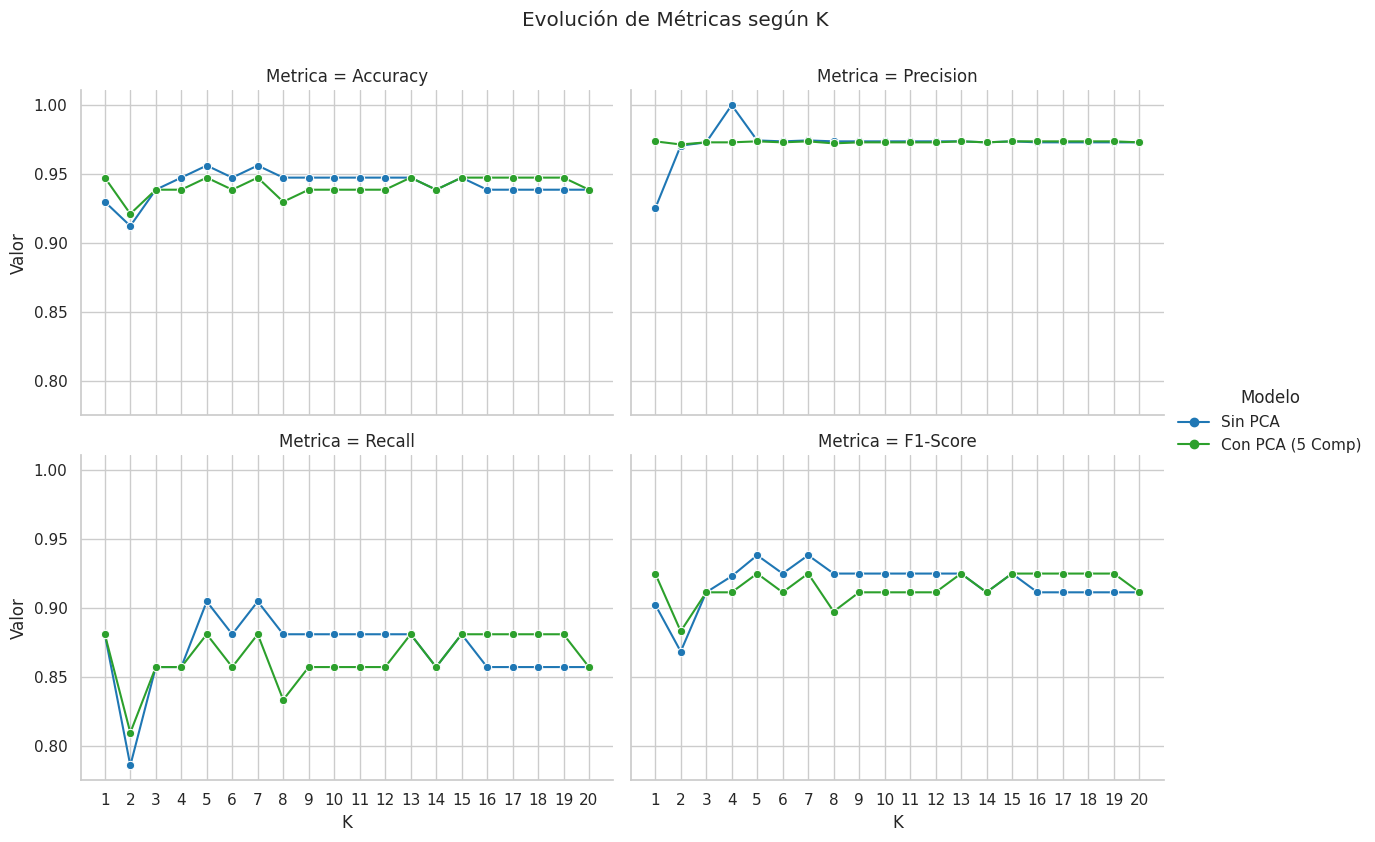

In [ ]:
g = sns.relplot(
    data=df_metrics, x="K", y="Valor", hue="Modelo", col="Metrica",
    kind="line", marker="o", col_wrap=2, height=4, aspect=1.5, palette=['#1f77b4', '#2ca02c']
)
g.set(xticks=k_values)
g.fig.suptitle('Evolución de Métricas según K', y=1.05)
plt.show()

---
## 3. Matrices de Confusión
Comparamos los errores (falsos positivos/negativos) de ambos modelos para un $K=5$.

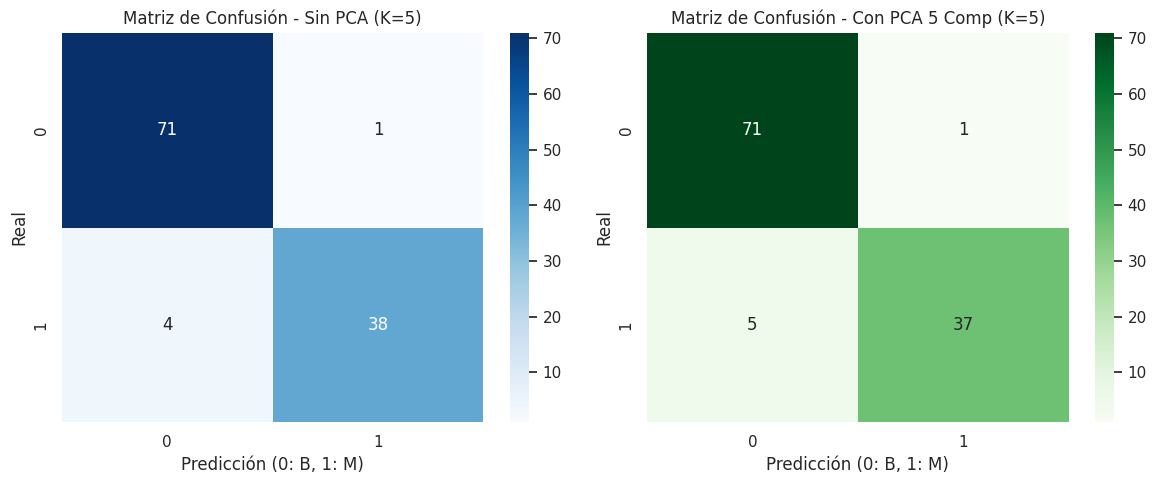

In [ ]:
k_optimo = 5

knn_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_opt.fit(X_train_scaled, y_train)
y_pred_opt = knn_opt.predict(X_test_scaled)

knn_pca_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_pca_opt.fit(X_train_pca, y_train)
y_pred_pca_opt = knn_pca_opt.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - Sin PCA (K={k_optimo})')
axes[0].set_xlabel('Predicción (0: B, 1: M)')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_pca_opt), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Matriz de Confusión - Con PCA 5 Comp (K={k_optimo})')
axes[1].set_xlabel('Predicción (0: B, 1: M)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

---
---

# Random Forest con PCA


# Random Forest en Cancer_Data: sin PCA vs con PCA

En este notebook aplicamos **Random Forest** al dataset **Cancer_Data.csv** en dos escenarios:

1. Sin PCA (usamos todas las variables originales).
2. Con PCA (reducimos variables a componentes principales).

El objetivo es comparar el rendimiento y discutir ventajas y limitaciones.

---

## Objetivos

- Entrenar un Random Forest sin reduccion de dimensiones.
- Aplicar PCA y elegir un numero adecuado de componentes.
- Entrenar un Random Forest sobre las componentes seleccionadas.
- Comparar metricas y tomar una conclusion.

# 1. Cargar librerias y configurar entorno

En esta parte importamos las librerias necesarias para:

- Manipular datos.
- Entrenar modelos.
- Aplicar PCA.
- Evaluar metricas.
- Graficar resultados.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# 2. Cargar y explorar el dataset de cancer

Cargamos el archivo **Cancer_Data.csv** y revisamos:

- Dimensiones.
- Primeras filas.
- Tipos de datos.
- Porcentaje de valores faltantes.

In [ ]:
data_path = Path("..") / "Cancer_Data.csv"

if not data_path.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {data_path.resolve()}")

df = pd.read_csv(data_path)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (569, 32)


,id,"""diagnosis""","""radius_mean""","""texture_mean""","""perimeter_mean""","""area_mean""","""smoothness_mean""","""compactness_mean""","""concavity_mean""","""concave points_mean""","""symmetry_mean""","""fractal_dimension_mean""","""radius_se""","""texture_se""","""perimeter_se""","""area_se""","""smoothness_se""","""compactness_se""","""concavity_se""","""concave points_se""","""symmetry_se""","""fractal_dimension_se""","""radius_worst""","""texture_worst""","""perimeter_worst""","""area_worst""","""smoothness_worst""","""compactness_worst""","""concavity_worst""","""concave points_worst""","""symmetry_worst""","""fractal_dimension_worst"""
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          569 non-null    int64  
 1    "diagnosis"                569 non-null    str    
 2    "radius_mean"              569 non-null    float64
 3    "texture_mean"             569 non-null    float64
 4    "perimeter_mean"           569 non-null    float64
 5    "area_mean"                569 non-null    float64
 6    "smoothness_mean"          569 non-null    float64
 7    "compactness_mean"         569 non-null    float64
 8    "concavity_mean"           569 non-null    float64
 9    "concave points_mean"      569 non-null    float64
 10   "symmetry_mean"            569 non-null    float64
 11   "fractal_dimension_mean"   569 non-null    float64
 12   "radius_se"                569 non-null    float64
 13   "texture_se"               569 non-null    fl

In [ ]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

faltantes.head(10)

,faltantes,porcentaje
id,0,0.0
"""diagnosis""",0,0.0
"""radius_mean""",0,0.0
"""texture_mean""",0,0.0
"""perimeter_mean""",0,0.0
"""area_mean""",0,0.0
"""smoothness_mean""",0,0.0
"""compactness_mean""",0,0.0
"""concavity_mean""",0,0.0
"""concave points_mean""",0,0.0


# 3. Preparar variables (limpieza, objetivo y separacion X/y)

Pasos clave:

- Eliminar columnas que no aportan (`id` o columnas vacias).
- Convertir `diagnosis` a binaria: **M=1**, **B=0**.
- Asegurar que todo sea numerico.
- Separar X e y.

In [ ]:
df_limpio = df.copy()

# Normalizar nombres de columnas (quitar espacios, comillas y caracteres invisibles)
col_originales = df_limpio.columns.astype(str)
col_limpias = (
    col_originales
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.strip("\"")
    .str.strip("'")
)

def normalizar_col(nombre):
    return (
        str(nombre)
        .replace("\ufeff", "")
        .strip()
        .strip("\"")
        .strip("'")
        .lower()
        .replace(" ", "")
        .replace("_", "")
    )

mapa_nombres = {}
for original, limpia in zip(col_originales, col_limpias):
    clave = normalizar_col(limpia)
    if clave == "diagnosis":
        mapa_nombres[original] = "diagnosis"
    elif clave == "id":
        mapa_nombres[original] = "id"
    else:
        mapa_nombres[original] = limpia

df_limpio = df_limpio.rename(columns=mapa_nombres)

# Eliminar columnas totalmente vacias
columnas_vacias = df_limpio.columns[df_limpio.isna().all()].tolist()
if columnas_vacias:
    df_limpio = df_limpio.drop(columns=columnas_vacias)

# Eliminar columnas tipo "Unnamed" si existen
columnas_unnamed = [col for col in df_limpio.columns if col.lower().startswith("unnamed")]
if columnas_unnamed:
    df_limpio = df_limpio.drop(columns=columnas_unnamed)

# Eliminar id si existe
if "id" in df_limpio.columns:
    df_limpio = df_limpio.drop(columns=["id"])

# Variable objetivo
if "diagnosis" not in df_limpio.columns:
    raise ValueError("No se encontro la columna diagnosis en el dataset")

df_limpio["diagnosis"] = df_limpio["diagnosis"].astype(str).str.strip().map({"M": 1, "B": 0})

# Convertir a numerico e imputar con mediana si hay faltantes
for col in df_limpio.columns:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

df_limpio = df_limpio.fillna(df_limpio.median(numeric_only=True))

X = df_limpio.drop(columns=["diagnosis"])
y = df_limpio["diagnosis"]

print("X:", X.shape)
print("y:", y.shape)
X.head()

X: (569, 30)
y: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 4. Division train/test

Usamos una separacion 70/30 con **estratificacion**, para conservar la proporcion de clases en entrenamiento y prueba.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Test: (171, 30)


# 5. Baseline: Random Forest sin PCA

Entrenamos un Random Forest con parametros razonables.

- `n_estimators`: numero de arboles.
- `random_state`: reproducibilidad.

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

# 6. Evaluacion del modelo sin PCA

Calculamos metricas y revisamos la matriz de confusion para entender errores por clase.

In [ ]:
def evaluar_clasificacion(y_real, y_pred):
    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall": recall_score(y_real, y_pred),
        "f1": f1_score(y_real, y_pred)
    }

metricas_base = evaluar_clasificacion(y_test, y_pred_base)

pd.DataFrame([metricas_base], index=["Random Forest sin PCA"])

,accuracy,precision,recall,f1
Random Forest sin PCA,0.97076,1.0,0.921875,0.95935


In [ ]:
print(classification_report(y_test, y_pred_base, target_names=["Benigno", "Maligno"]))

cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.title("Matriz de confusion - Sin PCA")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

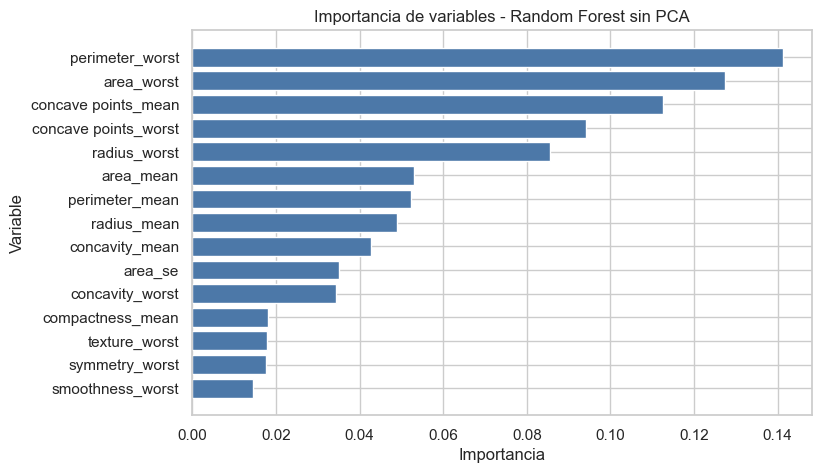

In [ ]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": rf_base.feature_importances_
}).sort_values("importancia", ascending=False)

top_importancias = importancias.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_importancias["variable"], top_importancias["importancia"], color="#4C78A8")
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest sin PCA")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### Sensibilidad a numero de arboles (n_estimators)

Probamos distintos valores de `n_estimators` para ver estabilidad del modelo sin PCA y si el rendimiento se estabiliza.

In [ ]:
valores_estimadores = [10, 50, 100, 200, 500]
resultados_estimadores = []

for n in valores_estimadores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    resultados_estimadores.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

df_estimadores = pd.DataFrame(resultados_estimadores)
df_estimadores

,n_estimators,accuracy,precision,recall,f1
0,10,0.947368,1.0,0.859375,0.92437
1,50,0.964912,1.0,0.906250,0.95082
2,100,0.964912,1.0,0.906250,0.95082
3,200,0.970760,1.0,0.921875,0.95935
4,500,0.970760,1.0,0.921875,0.95935


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_estimadores["n_estimators"], df_estimadores["accuracy"], marker="o", label="Accuracy")
plt.plot(df_estimadores["n_estimators"], df_estimadores["recall"], marker="o", label="Recall")
plt.plot(df_estimadores["n_estimators"], df_estimadores["f1"], marker="o", label="F1")
plt.title("Efecto de n_estimators en Random Forest (sin PCA)")
plt.xlabel("Numero de arboles")
plt.ylabel("Metrica")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

## Analisis y conclusiones: Random Forest sin PCA

**Lectura del rendimiento**
- Al usar todas las variables originales, el modelo aprovecha la informacion completa del dataset, incluyendo relaciones no lineales entre variables.
- Si las metricas (accuracy, precision, recall, f1) son altas y balanceadas, significa que el modelo esta clasificando bien tanto benignos como malignos.
- La matriz de confusion permite ver el tipo de error mas delicado: un **falso negativo** (maligno clasificado como benigno).

**Analisis con graficas**
- **Importancia de variables:** el grafico muestra que pocas variables concentran buena parte del poder predictivo, lo cual es comun en datasets clinicos.
- **Sensibilidad a `n_estimators`:** si las curvas se estabilizan a partir de cierto numero de arboles, significa que agregar mas arboles da mejoras marginales.

**Interpretacion didactica**
- Random Forest combina muchos arboles y reduce el sobreajuste de un arbol individual.
- En este escenario, las variables originales mantienen interpretabilidad directa: cada variable es una medicion clinica real.
- Si el modelo sin PCA obtiene resultados superiores, es una senal de que la informacion detallada ayuda mas que la reduccion de dimensiones.

**Conclusiones clave**
- El modelo sin PCA suele maximizar el rendimiento porque no pierde informacion en la transformacion.
- Es ideal cuando el objetivo es **maxima precision diagnostica** y no se tiene problema con muchas variables.
- La lectura de la matriz de confusion es fundamental para decidir si el modelo es aceptable en un contexto medico.

# 7. Escalado y PCA: seleccion estandarizada de componentes

PCA requiere escalado. Ajustamos un PCA completo para observar la varianza explicada acumulada, pero para este proyecto usamos **exactamente 5 componentes** en Random Forest con PCA.

La razon es metodologica: Arbol de Decision, KNN y Regresion ya usan PCA con 5 componentes. Mantener el mismo numero permite comparar los modelos bajo una reduccion de dimensionalidad equivalente, sin que Random Forest tenga ventaja por usar mas informacion comprimida.


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

componentes_estandar = 5
k = componentes_estandar
varianza_5 = varianza_acum[k - 1]
umbral_referencia = 0.95

print("Componentes usadas para Random Forest con PCA:", k)
print("Varianza acumulada en 5 componentes:", round(varianza_5, 4))
print("Referencia: el 95% de varianza se muestra solo como guia visual, no como criterio de seleccion en esta comparacion.")


In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum, marker="o")
plt.axhline(umbral_referencia, color="red", linestyle="--", label=f"Referencia {int(umbral_referencia*100)}%")
plt.axvline(k, color="green", linestyle="--", label=f"Componentes usadas = {k}")
plt.title("Varianza explicada acumulada")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
explained = varianza
cumulative = varianza_acum

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="Varianza individual", color="#72B7B2")
plt.step(range(1, len(cumulative) + 1), cumulative, where="mid", label="Varianza acumulada", color="#E45756", marker="o")
plt.title("Scree Plot - PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.components_.shape[0])],
    index=X.columns
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=loadings.loc[top_pc1, "PC1"], y=top_pc1, ax=axes[0], palette="viridis")
axes[0].set_title("Loadings PC1 (Top 10)")
axes[0].set_xlabel("Peso")
axes[0].set_ylabel("Variable")

sns.barplot(x=loadings.loc[top_pc2, "PC2"], y=top_pc2, ax=axes[1], palette="viridis")
axes[1].set_title("Loadings PC2 (Top 10)")
axes[1].set_xlabel("Peso")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()

# 8. Random Forest con PCA

Transformamos los datos a **5 componentes principales** y entrenamos un Random Forest con los mismos parametros base. Esta decision estandariza la comparacion con Arbol de Decision, KNN y Regresion, que tambien trabajan con PCA de 5 componentes.


In [ ]:

pca = PCA(n_components=k, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

print(f"Random Forest con PCA entrenado usando {k} componentes.")
print(f"Varianza retenida por esas {k} componentes: {pca.explained_variance_ratio_.sum():.4f}")


In [ ]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2 (datos de entrenamiento)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Diagnostico")
plt.grid(True)
plt.show()

# 9. Evaluacion del modelo con PCA

Repetimos las metricas y la matriz de confusion para comparar con el modelo sin PCA.

In [ ]:

metricas_pca = evaluar_clasificacion(y_test, y_pred_pca)

pd.DataFrame([metricas_pca], index=["Random Forest con PCA (5 comp)"])


In [ ]:
print(classification_report(y_test, y_pred_pca, target_names=["Benigno", "Maligno"]))

cm_pca = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.title("Matriz de confusion - Con PCA")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

## Analisis y conclusiones: Random Forest con PCA

**Lectura del cambio**
- En la version anterior, Random Forest con PCA elegia automaticamente las componentes necesarias para llegar aproximadamente al 95% de varianza; eso llevaba a usar mas componentes.
- Ahora se usan **5 componentes**, igual que en Arbol de Decision, KNN y Regresion. La comparacion queda mas estandarizada porque todos los modelos con PCA reciben la misma cantidad de informacion resumida.
- Si las metricas bajan frente a la version sin PCA, no significa que Random Forest sea malo; significa que cinco componentes pueden no conservar toda la senal que el ensamble aprovechaba con variables originales.

**Analisis con graficas**
- **Varianza acumulada:** muestra cuanta informacion retienen las primeras cinco componentes y que tanta informacion queda por fuera.
- **Loadings (PC1 y PC2):** permiten explicar que variables originales pesan mas en las primeras componentes.
- **Dispersión PC1 vs PC2:** ayuda a ver si benignos y malignos se separan visualmente en el espacio reducido.

**Interpretacion didactica**
- PCA hace el modelo mas compacto, pero reduce interpretabilidad: las componentes son mezclas de variables originales.
- En Random Forest, PCA no siempre mejora el rendimiento porque el modelo ya maneja muchas variables y relaciones no lineales.
- El valor de esta seccion es comparar de forma justa: cinco componentes para todos los modelos con PCA.

**Conclusion clave**
- Random Forest sin PCA suele ser mas interpretable en terminos de importancia de variables originales.
- Random Forest con PCA de 5 componentes es util para evaluar cuanto rendimiento se conserva cuando obligamos al modelo a trabajar con una representacion reducida y comun a los demas modelos.


# 10. Comparacion final de resultados (metricas y breve analisis)

Construimos una tabla y un grafico para comparar el rendimiento entre:

- Random Forest sin PCA.
- Random Forest con PCA.

Luego discutimos cual conviene y por que.

In [ ]:
comparacion = pd.DataFrame([
    {"modelo": "Random Forest sin PCA", **metricas_base},
    {"modelo": "Random Forest con PCA (5 comp)", **metricas_pca}
])

comparacion

In [ ]:
metricas_cols = ["accuracy", "precision", "recall", "f1"]

comparacion.set_index("modelo")[metricas_cols].plot(kind="bar", figsize=(9, 4))
plt.title("Comparacion de metricas: sin PCA vs con PCA")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

## Comparacion final: sin PCA vs con PCA

**Diferencias puntuales**
- **Entrada del modelo:**
  - Sin PCA: variables clinicas originales (interpretables).
  - Con PCA: componentes sinteticas (menos interpretables).
- **Desempeno esperado:**
  - Sin PCA: suele ser igual o mejor si las variables aportan informacion directa.
  - Con PCA: puede bajar un poco si se pierde senal, o mantenerse si la varianza retenida es alta.
- **Complejidad y mantenimiento:**
  - Sin PCA: mas variables, mas costo de analisis, pero mayor transparencia.
  - Con PCA: menos variables, mas compacto, pero menos explicable.

**Analisis general con apoyo grafico**
- El grafico de **n_estimators** indica si el modelo sin PCA ya esta estable con 200 arboles o si aun gana al subir el numero.
- El **scree plot** y los **loadings** explican cuanta informacion retuvo PCA y que variables influyen mas en los componentes.
- El scatter **PC1 vs PC2** muestra si existe separacion visible entre benignos y malignos en el espacio reducido.

**Conclusiones completas**
- **Random Forest sin PCA** es la mejor opcion cuando se busca el mayor rendimiento posible y se requiere interpretabilidad directa en variables clinicas.
- **Random Forest con PCA** es util cuando se necesita simplificar el modelo o reducir dimensionalidad, aceptando cierta perdida de interpretabilidad.
- La decision final debe basarse en el equilibrio entre:
  - calidad de clasificacion,
  - riesgo de errores clinicos,
  - facilidad para explicar el modelo,
  - costo computacional.

En resumen: si el rendimiento del modelo sin PCA es superior, se recomienda mantener las variables originales. Si ambos rendimientos son similares, PCA es una alternativa valida para simplificar el modelo sin sacrificar demasiado desempeno.

In [ ]:

varianza_df = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza))],
    "Varianza Individual": varianza,
    "Varianza Acumulada": varianza_acum,
    "Varianza Individual (%)": (varianza * 100).round(2),
    "Varianza Acumulada (%)": (varianza_acum * 100).round(2)
})

print("VARIANZA DE CADA COMPONENTE PRINCIPAL:\n")
print(varianza_df.to_string(index=False))
print(f"\nComponentes usadas en esta comparacion: {k}")
print(f"Varianza acumulada en {k} componentes: {varianza_acum[k-1]*100:.2f}%")


In [ ]:

print("RESUMEN DE VARIANZA PCA (primeros 15 componentes):\n")
print(varianza_df.head(15).to_string(index=False))
print(f"\n... (total de {len(varianza)} componentes)")
print(f"\nComponentes usadas para estandarizar la comparacion: {k}")
print(f"Varianza acumulada en {k} componentes: {varianza_acum[k-1]*100:.2f}%")


---
---

# Regresión con PCA


# Regresión y Análisis de Componentes Principales (PCA)

Este notebook organiza y compara el rendimiento de los modelos de Regresión (Logística y Lineal) con y sin PCA (5 componentes).

**Estructura del Documento:**
1. **PCA (5 Componentes)**
   - Loadings (Gráfica de barras)
   - Biplot (Observaciones y variables)
   - Scree Plot
2. **Regresión Logística**
   - Sin PCA · Con PCA · Comparación de métricas · Matrices de Confusión
3. **Regresión Lineal**
   - Sin PCA · Con PCA · Comparación de métricas · Gráficas Real vs Predicho

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
# Carga y Limpieza de datos
df = pd.read_csv('Cancer_Data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Limpiar nombres de columna: eliminar espacios y comillas dobles
df.columns = df.columns.str.strip().str.replace('"', '')

# Limpiar valores de la columna 'diagnosis' y codificarlos (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado general de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos cargados y escalados con éxito.")

FileNotFoundError: [Errno 2] No such file or directory: 'Cancer_Data.csv'

---
## 1. PCA (5 Componentes)

In [ ]:
# Aplicación de PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 1.1 Loadings (Gráfica de Barras)
Analizamos qué variables originales tienen mayor peso o aporte en la formación de la primera (PC1) y segunda (PC2) componente principal.

In [ ]:
feature_names = X.columns.tolist()
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(5)]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for i, pc in enumerate(['PC1', 'PC2']):
    sorted_loadings = loadings[pc].sort_values()
    colors = ['red' if v < 0 else 'steelblue' for v in sorted_loadings]
    axes[i].barh(sorted_loadings.index, sorted_loadings.values, color=colors)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Loadings - {pc}', fontsize=14)
    axes[i].set_xlabel('Peso (Loading)', fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 Biplot
Proyectamos observaciones y variables en el espacio de PC1 vs PC2.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.6, s=40, label='Observaciones'
)
plt.colorbar(scatter, ax=ax, label='Diagnóstico (0=B, 1=M)')
scale = 3
for i, feature in enumerate(feature_names):
    ax.annotate('', xy=(pca.components_[0, i]*scale, pca.components_[1, i]*scale),
        xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax.text(pca.components_[0, i]*scale*1.1, pca.components_[1, i]*scale*1.1,
        feature, fontsize=7, ha='center')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)', fontsize=12)
ax.set_title('Biplot PCA (PC1 vs PC2)', fontsize=14)
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

### 1.3 Scree Plot
Graficamos la varianza explicada por cada componente y su acumulada.

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8, 5))
bars = plt.bar(range(1,6), explained_variance, alpha=0.7, align='center',
    label='Varianza individual', color='skyblue')
plt.step(range(1,6), cumulative_variance, where='mid',
    label='Varianza acumulada', color='red', marker='o')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.01,
        f'{yval:.2%}', ha='center', va='bottom', fontsize=9)
plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks(range(1, 6))
plt.title('Scree Plot (Varianza Explicada por 5 Componentes)')
plt.legend(loc='center right')
plt.ylim(0, 1.1)
plt.show()

---
## 2. Regresión Logística
Aplicamos Regresión Logística para predecir `diagnosis` (Maligno / Benigno).

Utilizamos un `Pipeline` que primero escala los datos (`StandardScaler`) y luego aplica el modelo. Esto previene el **Data Leakage** ya que el escalador se ajusta solo con los datos de entrenamiento.

### 2.1 Regresión Logística – Sin PCA
Entrenamos el modelo con las variables **escaladas** (sin reducción de dimensionalidad).

In [ ]:
# Crear pipeline con StandardScaler y LogisticRegression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, random_state=42))
])

# Entrenamiento
pipeline_lr.fit(X_train, y_train)
print("Modelo de Regresión Logística (Sin PCA) entrenado correctamente.")

# Predicción
y_pred_lr = pipeline_lr.predict(X_test)

### 2.2 Regresión Logística – Con PCA
Entrenamos el modelo con las **5 componentes principales** (`X_train_pca` / `X_test_pca`).

In [ ]:
# Regresión Logística sobre componentes PCA (ya escalados)
lr_pca = LogisticRegression(max_iter=500, random_state=42)
lr_pca.fit(X_train_pca, y_train)
print("Modelo de Regresión Logística (Con PCA) entrenado correctamente.")

# Predicción
y_pred_lr_pca = lr_pca.predict(X_test_pca)

### 2.3 Comparación de Métricas – Regresión Logística (Sin PCA vs Con PCA)
Comparamos `Accuracy`, `Precision`, `Recall` y `F1-Score` de ambos modelos.

In [ ]:
def evaluar_clasificacion(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

comparacion_logistica = pd.DataFrame([
    evaluar_clasificacion('Log. Reg. Sin PCA', y_test, y_pred_lr),
    evaluar_clasificacion('Log. Reg. Con PCA', y_test, y_pred_lr_pca),
])

display(comparacion_logistica)

In [ ]:
# Gráfica comparativa de métricas
metrics_lr = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_melt_lr = comparacion_logistica.melt(
    id_vars='Modelo', value_vars=metrics_lr,
    var_name='Métrica', value_name='Valor'
)

g = sns.catplot(
    data=df_melt_lr, x='Métrica', y='Valor', hue='Modelo',
    kind='bar', height=5, aspect=1.8, palette=['#1f77b4', '#2ca02c']
)
g.fig.suptitle('Comparación de Métricas – Regresión Logística (Sin PCA vs Con PCA)', y=1.03)
plt.ylim(0, 1.1)
plt.show()

### 2.4 Detección de Overfitting – Regresión Logística
Comparamos el reporte de clasificación en Train vs Test para cada modelo.

In [ ]:
# Sin PCA
y_train_pred_lr = pipeline_lr.predict(X_train)
print('=== Sin PCA ===')
print('--- Test ---')
print(classification_report(y_test, y_pred_lr, target_names=['Benigno', 'Maligno']))
print('--- Train ---')
print(classification_report(y_train, y_train_pred_lr, target_names=['Benigno', 'Maligno']))

# Con PCA
y_train_pred_lr_pca = lr_pca.predict(X_train_pca)
print('\n=== Con PCA ===')
print('--- Test ---')
print(classification_report(y_test, y_pred_lr_pca, target_names=['Benigno', 'Maligno']))
print('--- Train ---')
print(classification_report(y_train, y_train_pred_lr_pca, target_names=['Benigno', 'Maligno']))

### 2.5 Matrices de Confusión – Regresión Logística
Comparamos los errores (falsos positivos / negativos) de ambos modelos.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
    cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión – Log. Reg. Sin PCA')
axes[0].set_xlabel('Predicción (0: B, 1: M)')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_lr_pca), annot=True, fmt='d',
    cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión – Log. Reg. Con PCA')
axes[1].set_xlabel('Predicción (0: B, 1: M)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

---
## 3. Regresión Lineal
Aplicamos Regresión Lineal para predecir una variable continua (`area_mean`).

**Nota:** Para la Regresión Lineal se redefine la variable objetivo (`y`) como `area_mean` (continua), a diferencia de la Logística que predice `diagnosis` (categórica). Por ello se requiere un nuevo split y un nuevo PCA que **no incluya** `area_mean` entre las features.

### 3.0 Preparación de Datos para Regresión Lineal

In [ ]:
# Variable objetivo continua
y_reg = df['area_mean'].copy()
X_reg = df.drop(columns=['area_mean', 'diagnosis'])
print(f'X_reg shape: {X_reg.shape}')
display(y_reg.describe())

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)
print(f'Train: {X_train_reg.shape}, Test: {X_test_reg.shape}')

# Escalado
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# PCA específico para regresión (sin area_mean)
pca_reg = PCA(n_components=5, random_state=42)
X_train_reg_pca = pca_reg.fit_transform(X_train_reg_scaled)
X_test_reg_pca = pca_reg.transform(X_test_reg_scaled)
print('PCA para regresión lineal aplicado (5 componentes).')

### 3.0.1 Función de Evaluación y Métricas de Regresión

In [ ]:
def evaluar_regresion(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f'[{nombre}] MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}')
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

resultados_reg = []

### 3.1 Regresión Lineal – Sin PCA

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
pred_nopca = lin_reg.predict(X_test_reg)
resultados_reg.append(evaluar_regresion('Reg. Lineal Sin PCA', y_test_reg, pred_nopca))

### 3.2 Regresión Lineal – Con PCA
Entrenamos un modelo de Regresión Lineal con las **5 componentes principales** (calculadas sin incluir `area_mean` entre las features).

In [ ]:
lin_reg_pca = LinearRegression()
lin_reg_pca.fit(X_train_reg_pca, y_train_reg)
pred_pca = lin_reg_pca.predict(X_test_reg_pca)
resultados_reg.append(evaluar_regresion('Reg. Lineal Con PCA', y_test_reg, pred_pca))

### 3.3 Comparación de Métricas – Regresión Lineal (Sin PCA vs Con PCA)
Comparamos `MAE`, `RMSE` y `R²` de ambos modelos.

In [ ]:
comparacion_lineal = pd.DataFrame(resultados_reg)
display(comparacion_lineal)

In [ ]:
# Gráfica comparativa de métricas
df_melt_rl = comparacion_lineal.melt(
    id_vars='Modelo', value_vars=['MAE', 'RMSE', 'R²'],
    var_name='Métrica', value_name='Valor'
)

g = sns.catplot(
    data=df_melt_rl, x='Métrica', y='Valor', hue='Modelo',
    kind='bar', height=5, aspect=1.5, palette=['#1f77b4', '#2ca02c']
)
g.fig.suptitle('Comparación de Métricas – Reg. Lineal (Sin PCA vs Con PCA)', y=1.03)
plt.show()

### 3.4 Gráficas Real vs Predicho – Regresión Lineal
Visualizamos la dispersión de valores reales contra predichos para ambos modelos.

**Nota:** La Regresión Lineal predice un valor continuo, por lo que una Matriz de Confusión no aplica. En su lugar, usamos gráficas de dispersión Real vs Predicho.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin PCA
axes[0].scatter(y_test_reg, pred_nopca, alpha=0.5, color='#1f77b4')
axes[0].plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
axes[0].set_title('Real vs Predicho – Sin PCA')
axes[0].set_xlabel('Valor Real (area_mean)')
axes[0].set_ylabel('Valor Predicho')

# Con PCA
axes[1].scatter(y_test_reg, pred_pca, alpha=0.5, color='#2ca02c')
axes[1].plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
axes[1].set_title('Real vs Predicho – Con PCA')
axes[1].set_xlabel('Valor Real (area_mean)')
axes[1].set_ylabel('Valor Predicho')

plt.tight_layout()
plt.show()

# Temas finales de Mineria de Datos aplicados a Cancer_Data.csv

En esta parte se completan los temas que faltaban del curso y se aplican al mismo conjunto de datos del proyecto: `Cancer_Data.csv`.

La idea no es agregar modelos por agregarlos. Cada metodo responde una pregunta distinta:

- **Clustering:** si ocultamos el diagnostico, ¿los pacientes se agrupan de forma natural?
- **Reglas de asociacion:** ¿que combinaciones de caracteristicas aparecen juntas con diagnosticos benignos o malignos?
- **SVM:** ¿podemos separar las clases con una frontera fuerte y estable?
- **Naive Bayes:** ¿que tan bien funciona un modelo simple basado en probabilidades?
- **Dunn y Silhouette:** ¿que tan compactos y separados son los grupos encontrados?
- **Analisis de Correspondencias:** ¿como se relacionan categorias de variables con el diagnostico?

Para que esta seccion sea facil de exponer, las celdas usan lenguaje directo y cada bloque termina con una lectura de resultados.


## Preparacion comun de los datos

Primero cargamos el dataset y hacemos una preparacion limpia. La columna `diagnosis` sera nuestra referencia: `M` significa maligno y `B` significa benigno.

En los metodos supervisados se usa como variable objetivo. En clustering no se usa para entrenar; se guarda solo para interpretar si los grupos encontrados se parecen o no al diagnostico real.


In [ ]:
import os
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    silhouette_score, adjusted_rand_score, roc_auc_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="Set2")

possible_paths = [
    Path("Cancer_Data.csv"),
    Path("../Cancer_Data.csv"),
    Path("./Cancer_Data.csv"),
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("No se encontro Cancer_Data.csv. Verifica que este en la raiz del proyecto o un nivel arriba del notebook.")

df_cancer = pd.read_csv(data_path)
df_cancer.columns = df_cancer.columns.str.replace('"', "", regex=False).str.strip()

for col in df_cancer.select_dtypes(include="object").columns:
    df_cancer[col] = df_cancer[col].astype(str).str.replace('"', "", regex=False).str.strip()

df_cancer = df_cancer.dropna(axis=1, how="all")

if "diagnosis" not in df_cancer.columns:
    raise ValueError("El dataset debe contener la columna diagnosis.")

feature_columns = [c for c in df_cancer.columns if c not in ["id", "diagnosis"]]
X_cancer = df_cancer[feature_columns].apply(pd.to_numeric, errors="coerce")
X_cancer = X_cancer.fillna(X_cancer.median(numeric_only=True))
y_cancer = df_cancer["diagnosis"].map({"B": 0, "M": 1})
y_labels = df_cancer["diagnosis"].map({"B": "Benigno", "M": "Maligno"})

print("Dataset cargado desde:", data_path)
print("Filas:", X_cancer.shape[0], "| Variables predictoras:", X_cancer.shape[1])
display(pd.DataFrame({"conteo": y_labels.value_counts(), "porcentaje": y_labels.value_counts(normalize=True).round(3)}))


## 1. Clustering no supervisado: KMeans, Jerarquico y DBSCAN

El clustering busca grupos sin mirar la etiqueta `diagnosis`. Esto es muy util como pregunta exploratoria: si el diagnostico no existiera, ¿las mediciones del tumor formarian grupos parecidos a benigno y maligno?

Usaremos tres enfoques:

- **KMeans:** crea grupos compactos alrededor de centros.
- **Clustering jerarquico:** construye una especie de arbol de similitudes entre pacientes.
- **DBSCAN:** busca zonas densas y puede marcar casos raros como ruido.

Antes de agrupar, escalamos las variables porque muchas estan en unidades distintas. Tambien usamos PCA de dos componentes para visualizar los pacientes en un plano.


In [ ]:
scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cancer)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled_cluster)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Diagnostico": y_labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="Diagnostico", alpha=0.85)
plt.title("Vista PCA 2D coloreada por diagnostico real")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} de varianza)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} de varianza)")
plt.show()

print("Lectura para exposicion:")
print("PCA comprime las variables originales en dos ejes. Si benignos y malignos quedan separados visualmente, hay senales fuertes en las mediciones del tumor.")


In [ ]:
k_values = range(2, 9)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_scaled_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_cluster, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Metodo del codo para KMeans")
axes[0].set_xlabel("Numero de clusters k")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(k_values), silhouettes, marker="o", color="darkgreen")
axes[1].set_title("Silhouette por numero de clusters")
axes[1].set_xlabel("Numero de clusters k")
axes[1].set_ylabel("Silhouette")
plt.show()

k_sugerido = list(k_values)[int(np.argmax(silhouettes))]
print(f"El mayor Silhouette en esta busqueda aparece con k={k_sugerido}.")
print("Como el problema medico tiene dos diagnosticos principales, tambien evaluaremos k=2 para contrastarlo con benigno/maligno.")


In [ ]:
def evaluar_clusters(nombre, labels, X_eval, y_ref):
    labels = np.asarray(labels)
    clusters_validos = [c for c in np.unique(labels) if c != -1]
    n_clusters = len(clusters_validos)
    ruido = int(np.sum(labels == -1))

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_eval[mask], labels[mask]) if mask.sum() > n_clusters else np.nan
    else:
        sil = np.nan

    ari = adjusted_rand_score(y_ref, labels)
    return {
        "Metodo": nombre,
        "Clusters": n_clusters,
        "Casos_ruido": ruido,
        "Silhouette": sil,
        "ARI_vs_diagnostico": ari
    }

kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=20)
labels_kmeans = kmeans_2.fit_predict(X_scaled_cluster)

jerarquico_2 = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_jerarquico = jerarquico_2.fit_predict(X_scaled_cluster)

eps_grid = np.arange(1.5, 6.1, 0.25)
dbscan_candidates = []
for eps in eps_grid:
    db = DBSCAN(eps=float(eps), min_samples=5)
    labels_db = db.fit_predict(X_scaled_cluster)
    result = evaluar_clusters(f"DBSCAN eps={eps:.2f}", labels_db, X_scaled_cluster, y_cancer)
    result["eps"] = eps
    result["labels"] = labels_db
    if result["Clusters"] >= 2:
        dbscan_candidates.append(result)

if dbscan_candidates:
    best_dbscan = max(dbscan_candidates, key=lambda d: -999 if pd.isna(d["Silhouette"]) else d["Silhouette"])
    labels_dbscan = best_dbscan["labels"]
    dbscan_name = f"DBSCAN eps={best_dbscan['eps']:.2f}"
else:
    labels_dbscan = DBSCAN(eps=3.0, min_samples=5).fit_predict(X_scaled_cluster)
    dbscan_name = "DBSCAN eps=3.00"

cluster_results = pd.DataFrame([
    evaluar_clusters("KMeans k=2", labels_kmeans, X_scaled_cluster, y_cancer),
    evaluar_clusters("Jerarquico Ward k=2", labels_jerarquico, X_scaled_cluster, y_cancer),
    evaluar_clusters(dbscan_name, labels_dbscan, X_scaled_cluster, y_cancer),
])

display(cluster_results.round(4))

print("Como leer la tabla:")
print("Silhouette cerca de 1 indica grupos bien separados. ARI compara los clusters con el diagnostico real: 1 seria coincidencia perfecta, 0 seria parecido al azar.")
print("En clustering, el diagnostico no se usa para entrenar; se usa al final como espejo para interpretar.")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
cluster_maps = [
    ("KMeans k=2", labels_kmeans),
    ("Jerarquico Ward k=2", labels_jerarquico),
    (dbscan_name, labels_dbscan),
]

for ax, (title, labels) in zip(axes, cluster_maps):
    plot_df = pd.DataFrame({"PC1": X_pca_2d[:, 0], "PC2": X_pca_2d[:, 1], "Cluster": labels.astype(str)})
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", ax=ax, alpha=0.85, legend=False)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Comparacion visual de clusters sobre el plano PCA", y=1.03)
plt.tight_layout()
plt.show()


In [ ]:
sample_size = min(80, X_scaled_cluster.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_scaled_cluster.shape[0], size=sample_size, replace=False)

Z = linkage(X_scaled_cluster[sample_idx], method="ward")
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Dendrograma jerarquico sobre una muestra de pacientes")
plt.xlabel("Pacientes de la muestra")
plt.ylabel("Distancia")
plt.show()

print("Lectura para exposicion:")
print("El dendrograma muestra como los pacientes se van uniendo por similitud. Cortar el arbol en cierta altura equivale a decidir cuantos grupos queremos formar.")


### Analisis del clustering

Esta parte responde una pregunta exploratoria: **si no miraramos el diagnostico, las variables del tumor ya traen una estructura interna?**

Si KMeans o el metodo jerarquico obtienen buen `Silhouette` y un `ARI` razonable frente al diagnostico, significa que las mediciones geometricas del tumor separan bastante bien a los pacientes. DBSCAN aporta otra mirada: no obliga a todos los pacientes a pertenecer a un grupo y puede detectar observaciones atipicas.

Para una exposicion, la idea clave es esta: el clustering no reemplaza al diagnostico, pero ayuda a descubrir si hay patrones naturales y si existen casos dificiles o raros que merecen revision.


## 2. Dunn Coefficient: calidad de los clusters

El coeficiente de Dunn compara dos cosas:

- que tan juntos estan los puntos dentro de cada cluster;
- que tan lejos estan los clusters entre si.

Un valor mas alto es mejor. En palabras simples: Dunn premia grupos compactos y separados. Lo usaremos junto con Silhouette porque una sola metrica rara vez cuenta toda la historia.


In [ ]:
def dunn_index(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    X_valid = X[mask]
    labels_valid = labels[mask]
    unique_labels = np.unique(labels_valid)

    if len(unique_labels) < 2:
        return np.nan

    distances = squareform(pdist(X_valid))

    max_intra = 0.0
    for label in unique_labels:
        idx = np.where(labels_valid == label)[0]
        if len(idx) > 1:
            intra = distances[np.ix_(idx, idx)].max()
            max_intra = max(max_intra, intra)

    min_inter = np.inf
    for a, b in combinations(unique_labels, 2):
        idx_a = np.where(labels_valid == a)[0]
        idx_b = np.where(labels_valid == b)[0]
        inter = distances[np.ix_(idx_a, idx_b)].min()
        min_inter = min(min_inter, inter)

    if max_intra == 0:
        return np.nan
    return min_inter / max_intra

cluster_quality = cluster_results.copy()
cluster_quality["Dunn"] = [
    dunn_index(X_scaled_cluster, labels_kmeans),
    dunn_index(X_scaled_cluster, labels_jerarquico),
    dunn_index(X_scaled_cluster, labels_dbscan),
]

display(cluster_quality[["Metodo", "Silhouette", "Dunn", "ARI_vs_diagnostico", "Casos_ruido"]].round(4))

cluster_quality.set_index("Metodo")[["Silhouette", "Dunn"]].plot(kind="bar", figsize=(10, 4))
plt.title("Silhouette y Dunn: dos miradas de calidad de clustering")
plt.ylabel("Valor de la metrica")
plt.xticks(rotation=20, ha="right")
plt.show()

print("Lectura para exposicion:")
print("Silhouette mira separacion promedio. Dunn es mas exigente porque se fija en el peor caso: el cluster mas disperso y los clusters mas cercanos.")


### Analisis de Dunn

Si un metodo tiene buen Silhouette pero Dunn bajo, puede significar que en promedio se ve bien, pero existe algun cluster muy disperso o dos clusters demasiado cercanos. Por eso Dunn ayuda a no quedarnos solo con una metrica bonita.

En este proyecto, Dunn sirve para comparar KMeans, jerarquico y DBSCAN con una pregunta sencilla: **cual metodo produce grupos mas limpios y separados en las mediciones del cancer?**


## 3. Reglas de asociacion con Apriori

Las reglas de asociacion se usan mucho en datos transaccionales, como compras de supermercado. En este dataset no tenemos compras, pero podemos convertir las variables numericas en categorias: bajo, medio y alto.

Por ejemplo, una transaccion puede verse asi:

`radius_mean=Alto`, `concavity_mean=Alto`, `diagnosis=Maligno`

Luego buscamos reglas del tipo:

`concavity_mean=Alto` y `area_mean=Alto` -> `diagnosis=Maligno`

Las metricas principales son:

- **Soporte:** que tan frecuente aparece la combinacion.
- **Confianza:** de los casos que cumplen la condicion, cuantos llegan a la conclusion.
- **Lift:** que tanto mejora la regla frente a mirar la conclusion sin informacion adicional.


In [ ]:
association_features = [
    "radius_mean", "texture_mean", "area_mean", "compactness_mean",
    "concavity_mean", "concave points_mean", "symmetry_mean", "radius_worst",
    "area_worst", "concave points_worst"
]
association_features = [c for c in association_features if c in X_cancer.columns]

binned = pd.DataFrame(index=df_cancer.index)
for col in association_features:
    binned[col] = pd.qcut(X_cancer[col], q=3, labels=["Bajo", "Medio", "Alto"], duplicates="drop")

binned["diagnosis"] = y_labels.values

transactions = []
for _, row in binned.iterrows():
    items = [f"{col}={row[col]}" for col in association_features if pd.notna(row[col])]
    items.append(f"diagnosis={row['diagnosis']}")
    transactions.append(set(items))

print("Ejemplo de transaccion discretizada:")
print(sorted(list(transactions[0]))[:8], "...")
print("Numero de transacciones:", len(transactions))


In [ ]:
def apriori_simple(transactions, min_support=0.15, max_len=3):
    n = len(transactions)
    all_items = sorted(set().union(*transactions))
    support_data = {}
    current_level = []

    for item in all_items:
        itemset = frozenset([item])
        support = sum(itemset.issubset(t) for t in transactions) / n
        if support >= min_support:
            support_data[itemset] = support
            current_level.append(itemset)

    k = 2
    while current_level and k <= max_len:
        candidates = set()
        current_list = list(current_level)
        for i in range(len(current_list)):
            for j in range(i + 1, len(current_list)):
                candidate = current_list[i] | current_list[j]
                if len(candidate) == k:
                    candidates.add(candidate)

        next_level = []
        for candidate in candidates:
            support = sum(candidate.issubset(t) for t in transactions) / n
            if support >= min_support:
                support_data[candidate] = support
                next_level.append(candidate)

        current_level = next_level
        k += 1

    return support_data

def generar_reglas(support_data, min_confidence=0.65):
    rules = []
    for itemset, support_itemset in support_data.items():
        if len(itemset) < 2:
            continue
        items = list(itemset)
        for r in range(1, len(items)):
            for antecedent_tuple in combinations(items, r):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent
                if not consequent:
                    continue
                support_antecedent = support_data.get(antecedent)
                support_consequent = support_data.get(consequent)
                if support_antecedent and support_consequent:
                    confidence = support_itemset / support_antecedent
                    lift = confidence / support_consequent
                    if confidence >= min_confidence:
                        rules.append({
                            "Antecedente": ", ".join(sorted(antecedent)),
                            "Consecuente": ", ".join(sorted(consequent)),
                            "Soporte": support_itemset,
                            "Confianza": confidence,
                            "Lift": lift
                        })
    return pd.DataFrame(
        rules,
        columns=["Antecedente", "Consecuente", "Soporte", "Confianza", "Lift"]
    )

support_data = apriori_simple(transactions, min_support=0.12, max_len=3)
rules_df = generar_reglas(support_data, min_confidence=0.70)

rules_diagnosis = rules_df[rules_df["Consecuente"].str.contains("diagnosis=", regex=False)].copy()
rules_diagnosis = rules_diagnosis.sort_values(["Lift", "Confianza", "Soporte"], ascending=False)

display(rules_diagnosis.head(15).round(3))

print("Cantidad de itemsets frecuentes:", len(support_data))
print("Cantidad de reglas hacia diagnostico:", len(rules_diagnosis))


In [ ]:
if not rules_diagnosis.empty:
    top_rules = rules_diagnosis.head(10).copy()
    top_rules["Regla"] = top_rules["Antecedente"] + " -> " + top_rules["Consecuente"]

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_rules, y="Regla", x="Lift", hue="Consecuente", dodge=False)
    plt.title("Top reglas de asociacion orientadas al diagnostico")
    plt.xlabel("Lift")
    plt.ylabel("Regla")
    plt.legend(title="Consecuente")
    plt.show()
else:
    print("No se encontraron reglas hacia diagnostico con los umbrales actuales. Prueba bajando min_support o min_confidence.")


### Analisis de reglas de asociacion

Estas reglas no son un clasificador medico formal. Su valor esta en que traducen patrones numericos a frases faciles de explicar.

Una regla con `Lift` mayor que 1 indica que el antecedente aumenta la presencia del diagnostico del consecuente. Por ejemplo, si una regla hacia `diagnosis=Maligno` tiene alta confianza y alto lift, significa que esa combinacion de categorias aparece con mucha fuerza en los casos malignos.

Para estudiantes, esta seccion muestra algo importante: a veces la mineria de datos no busca solo predecir, sino tambien **descubrir relaciones comprensibles**.


## 4. Support Vector Machine (SVM)

SVM intenta separar las clases con una frontera que deje el mayor margen posible. En palabras sencillas, no busca solo separar benignos y malignos, sino separarlos con una zona de seguridad amplia.

Como SVM depende de distancias y escalas, usaremos `StandardScaler`. Compararemos dos kernels:

- **Lineal:** frontera mas simple e interpretable.
- **RBF:** frontera mas flexible para relaciones no lineales.


In [ ]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

svm_models = {
    "SVM lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1.0, probability=True, random_state=42))
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
    ]),
}

svm_results = []
svm_predictions = {}

for name, model in svm_models.items():
    model.fit(X_train_svm, y_train_svm)
    pred = model.predict(X_test_svm)
    proba = model.predict_proba(X_test_svm)[:, 1]
    svm_predictions[name] = pred
    svm_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test_svm, pred),
        "Precision": precision_score(y_test_svm, pred),
        "Recall": recall_score(y_test_svm, pred),
        "F1": f1_score(y_test_svm, pred),
        "ROC_AUC": roc_auc_score(y_test_svm, proba),
    })

svm_results_df = pd.DataFrame(svm_results).sort_values("Recall", ascending=False)
display(svm_results_df.round(4))

print("Lectura para exposicion:")
print("En cancer suele ser muy importante el Recall para la clase maligna, porque queremos reducir falsos negativos: casos malignos clasificados como benignos.")


In [ ]:
best_svm_name = svm_results_df.iloc[0]["Modelo"]
best_svm_pred = svm_predictions[best_svm_name]

print(f"Mejor SVM segun Recall: {best_svm_name}")
print(classification_report(y_test_svm, best_svm_pred, target_names=["Benigno", "Maligno"]))

ConfusionMatrixDisplay.from_predictions(
    y_test_svm, best_svm_pred,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues",
    values_format="d"
)
plt.title(f"Matriz de confusion - {best_svm_name}")
plt.show()


### Analisis de SVM

SVM es un buen candidato para este dataset porque las variables del tumor suelen separar bastante bien los diagnosticos. Si el kernel lineal se acerca al RBF, eso sugiere que la frontera entre benigno y maligno es relativamente clara. Si RBF mejora, puede indicar que hay relaciones curvas o mas complejas entre variables.

En la exposicion conviene resaltar el `Recall` de malignos: un falso negativo es delicado porque seria decir "benigno" cuando en realidad era "maligno".


## 5. Naive Bayes

Naive Bayes es un modelo probabilistico simple. Parte de una idea muy natural: con la evidencia disponible, calcula que diagnostico es mas probable.

Se llama "naive" porque asume que las variables son independientes entre si, algo que no siempre se cumple. En este dataset varias medidas estan relacionadas, por ejemplo radio, perimetro y area. Aun asi, el modelo puede funcionar sorprendentemente bien y sirve como linea base rapida.


In [ ]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)
nb_pred = nb_model.predict(X_test_nb)
nb_proba = nb_model.predict_proba(X_test_nb)[:, 1]

nb_results = pd.DataFrame([{
    "Modelo": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test_nb, nb_pred),
    "Precision": precision_score(y_test_nb, nb_pred),
    "Recall": recall_score(y_test_nb, nb_pred),
    "F1": f1_score(y_test_nb, nb_pred),
    "ROC_AUC": roc_auc_score(y_test_nb, nb_proba),
}])

display(nb_results.round(4))
print(classification_report(y_test_nb, nb_pred, target_names=["Benigno", "Maligno"]))

ConfusionMatrixDisplay.from_predictions(
    y_test_nb, nb_pred,
    display_labels=["Benigno", "Maligno"],
    cmap="Purples",
    values_format="d"
)
plt.title("Matriz de confusion - Gaussian Naive Bayes")
plt.show()


In [ ]:
proba_df = pd.DataFrame({
    "Probabilidad_Maligno": nb_proba,
    "Diagnostico_real": y_test_nb.map({0: "Benigno", 1: "Maligno"}).values
})

plt.figure(figsize=(9, 5))
sns.histplot(data=proba_df, x="Probabilidad_Maligno", hue="Diagnostico_real", bins=20, kde=True, element="step")
plt.title("Distribucion de probabilidades predichas por Naive Bayes")
plt.xlabel("Probabilidad estimada de maligno")
plt.show()

print("Lectura para exposicion:")
print("Si los benignos se concentran cerca de 0 y los malignos cerca de 1, el modelo esta asignando probabilidades coherentes.")
print("Los casos cerca de 0.5 son los mas dudosos y merecen mas atencion.")


### Analisis de Naive Bayes

Naive Bayes es valioso porque es rapido, claro y probabilistico. Su debilidad es la suposicion de independencia: en cancer, muchas variables geometricas se mueven juntas.

Si sus metricas quedan cerca de modelos mas complejos, es una buena senal: significa que el dataset tiene patrones fuertes. Si queda por debajo, tambien enseña algo: los modelos que capturan interacciones entre variables pueden aprovechar mejor la informacion.


## 6. Analisis de Correspondencias

El Analisis de Correspondencias sirve para estudiar relaciones entre categorias. Como `Cancer_Data.csv` es numerico, primero convertimos algunas variables a categorias: bajo, medio y alto.

La pregunta sera:

**Que categorias de las variables aparecen mas asociadas con diagnosticos benignos o malignos?**

Esto complementa PCA: PCA trabaja con variables numericas continuas; Correspondencias trabaja con tablas categoricas.


In [ ]:
ca_features = [
    "radius_mean", "texture_mean", "area_mean", "compactness_mean",
    "concavity_mean", "concave points_mean", "radius_worst", "area_worst"
]
ca_features = [c for c in ca_features if c in X_cancer.columns]

ca_cats = pd.DataFrame(index=df_cancer.index)
for col in ca_features:
    ca_cats[col] = pd.qcut(X_cancer[col], q=3, labels=["Bajo", "Medio", "Alto"], duplicates="drop")
ca_cats["Diagnostico"] = y_labels.values

contingency_parts = []
for col in ca_features:
    table_col = pd.crosstab(ca_cats["Diagnostico"], ca_cats[col])
    table_col.columns = [f"{col}={category}" for category in table_col.columns]
    contingency_parts.append(table_col)

ca_table = pd.concat(contingency_parts, axis=1)
display(ca_table)

chi2, p_value, dof, expected = chi2_contingency(ca_table)
print(f"Chi-cuadrado: {chi2:.3f} | p-value: {p_value:.5f} | grados de libertad: {dof}")
print("Un p-value pequeno sugiere que las categorias de variables no se distribuyen igual entre benignos y malignos.")


In [ ]:
def correspondence_analysis(table):
    N = table.to_numpy(dtype=float)
    total = N.sum()
    P = N / total
    r = P.sum(axis=1)
    c = P.sum(axis=0)

    expected = np.outer(r, c)
    S = (P - expected) / np.sqrt(expected)

    U, singular_values, Vt = np.linalg.svd(S, full_matrices=False)

    row_coords = (U * singular_values) / np.sqrt(r[:, None])
    col_coords = (Vt.T * singular_values) / np.sqrt(c[:, None])

    row_df = pd.DataFrame(row_coords[:, :2], index=table.index, columns=["Dim1", "Dim2"])
    col_df = pd.DataFrame(col_coords[:, :2], index=table.columns, columns=["Dim1", "Dim2"])
    inertia = singular_values**2

    return row_df, col_df, inertia

row_ca, col_ca, inertia_ca = correspondence_analysis(ca_table)

print("Inercia explicada por dimension:")
display(pd.DataFrame({
    "Dimension": [f"Dim{i+1}" for i in range(len(inertia_ca))],
    "Inercia": inertia_ca,
    "Porcentaje": inertia_ca / inertia_ca.sum()
}).head().round(4))

display(row_ca.round(4))
display(col_ca.sort_values("Dim1").head(10).round(4))
display(col_ca.sort_values("Dim1").tail(10).round(4))


In [ ]:
plt.figure(figsize=(12, 7))

plt.scatter(row_ca["Dim1"], row_ca["Dim2"], s=180, marker="s", color="black", label="Diagnostico")
for label, row in row_ca.iterrows():
    plt.text(row["Dim1"], row["Dim2"], f"  {label}", fontsize=12, weight="bold")

col_plot = col_ca.copy()
col_plot["distancia"] = np.sqrt(col_plot["Dim1"]**2 + col_plot["Dim2"]**2)
col_plot = col_plot.sort_values("distancia", ascending=False).head(18)

plt.scatter(col_plot["Dim1"], col_plot["Dim2"], s=70, color="teal", alpha=0.8, label="Categorias")
for label, row in col_plot.iterrows():
    plt.text(row["Dim1"], row["Dim2"], "  " + label, fontsize=9)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Analisis de Correspondencias: diagnostico y categorias de variables")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

print("Lectura para exposicion:")
print("Categorias cercanas a 'Maligno' aparecen proporcionalmente mas en casos malignos. Categorias cercanas a 'Benigno' aparecen mas en benignos.")
print("Las categorias cerca del centro no diferencian mucho entre diagnosticos.")


### Analisis de Correspondencias

Este analisis convierte muchas mediciones numericas en un mapa categorico. Si categorias como valores altos de area, concavidad o puntos concavos quedan cerca de `Maligno`, eso indica una asociacion clara con ese diagnostico. Si categorias bajas quedan cerca de `Benigno`, la lectura tambien es coherente con la intuicion del dataset.

La ventaja para una exposicion es que el resultado se puede explicar como un mapa de cercanias: lo que queda cerca tiende a aparecer junto con mas frecuencia.


## Cierre de los temas agregados

Con estas secciones, el notebook ya integra los temas centrales y finales de la materia:

- modelos supervisados clasicos;
- comparacion de metricas;
- PCA y reduccion de dimensionalidad;
- clustering con KMeans, jerarquico y DBSCAN;
- evaluacion de clusters con Silhouette y Dunn;
- reglas de asociacion con Apriori;
- SVM;
- Naive Bayes;
- Analisis de Correspondencias.

La lectura general del proyecto queda mas completa: el dataset de cancer no solo se puede clasificar, tambien se puede explorar, agrupar, convertir en reglas interpretables y analizar desde relaciones categoricas. Eso muestra una vision mas amplia de la mineria de datos: predecir, explicar y descubrir patrones.


## Sintesis final segun lineamientos

Esta seccion funciona como cierre de exposicion. Reune la comparacion general, el criterio de seleccion del mejor modelo y las conclusiones finales del proyecto.

En un problema de diagnostico de cancer no basta con mirar `accuracy`. El indicador mas delicado es `recall` para la clase maligna, porque un falso negativo significa clasificar como benigno un caso que realmente era maligno. Por eso la recomendacion debe equilibrar:

- buen `recall` en malignos;
- buen `F1-score`;
- baja cantidad de falsos negativos;
- interpretabilidad suficiente para explicar el resultado;
- estabilidad entre entrenamiento y prueba.


In [ ]:
resumen_supervisados = []

def agregar_metricas(nombre, metricas):
    if isinstance(metricas, dict):
        resumen_supervisados.append({
            "Modelo": nombre,
            "Accuracy": metricas.get("accuracy", metricas.get("Accuracy")),
            "Precision": metricas.get("precision", metricas.get("Precision")),
            "Recall": metricas.get("recall", metricas.get("Recall")),
            "F1": metricas.get("f1", metricas.get("F1", metricas.get("F1-Score")))
        })

if "metricas_base" in globals():
    agregar_metricas("Random Forest sin PCA", metricas_base)
if "metricas_pca" in globals():
    agregar_metricas("Random Forest con PCA (5 comp)", metricas_pca)
if "svm_results_df" in globals() and not svm_results_df.empty:
    for _, row in svm_results_df.iterrows():
        resumen_supervisados.append({
            "Modelo": row["Modelo"],
            "Accuracy": row["Accuracy"],
            "Precision": row["Precision"],
            "Recall": row["Recall"],
            "F1": row["F1"]
        })
if "nb_results" in globals() and not nb_results.empty:
    row = nb_results.iloc[0]
    resumen_supervisados.append({
        "Modelo": row["Modelo"],
        "Accuracy": row["Accuracy"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1": row["F1"]
    })

if resumen_supervisados:
    resumen_supervisados = pd.DataFrame(resumen_supervisados)
    resumen_supervisados = resumen_supervisados.sort_values(["Recall", "F1", "Accuracy"], ascending=False)
    display(resumen_supervisados.round(4))
    print("Modelo recomendado segun prioridad Recall + F1:", resumen_supervisados.iloc[0]["Modelo"])
else:
    print("Ejecuta las secciones de modelos para construir la tabla final de modelos supervisados.")


### Mejor modelo y justificacion

El mejor modelo debe seleccionarse despues de ejecutar todo el notebook y revisar la tabla final. Para exposicion, la recomendacion debe formularse asi:

- Si **Random Forest sin PCA** queda arriba en `Recall` y `F1`, se recomienda como modelo predictivo principal porque aprovecha las variables originales y permite revisar importancias.
- Si un modelo con PCA obtiene resultados muy similares, puede defenderse como alternativa compacta, pero se debe aclarar que pierde interpretabilidad directa.
- Si SVM o Naive Bayes igualan el rendimiento, se comparan por claridad: Naive Bayes es mas simple, SVM suele ser fuerte pero menos explicable.

### Conclusiones finales

El dataset muestra patrones claros entre las mediciones del tumor y el diagnostico. Variables asociadas con tamano, concavidad y puntos concavos aparecen como muy relevantes tanto en EDA como en modelos.

PCA permite reducir dimensionalidad y estandarizar comparaciones, pero no siempre mejora Random Forest porque este modelo ya maneja bien muchas variables. Por eso la comparacion con 5 componentes es valiosa: muestra cuanto rendimiento se conserva cuando todos los modelos reciben la misma representacion reducida.

Los metodos no supervisados complementan la clasificacion: clustering muestra si existen grupos naturales, reglas de asociacion traducen patrones a frases entendibles y analisis de correspondencias permite ver relaciones entre categorias y diagnostico.

### Limitaciones y mejoras futuras

- El dataset es relativamente pequeno para conclusiones clinicas definitivas.
- Las metricas dependen de una particion train/test; una mejora futura seria usar validacion cruzada.
- Conviene ajustar hiperparametros con busqueda sistematica, especialmente en SVM, Random Forest y DBSCAN.
- Para un uso real en salud se necesitaria validacion externa con datos de otra fuente.


## 11. Mejor Modelo y Justificación

### Evaluación Comparativa de Modelos de Clasificación

A continuación se presenta la tabla de métricas obtenidas para cada modelo supervisado evaluado sobre el conjunto de prueba:

| Modelo | Accuracy | Precision | Recall | F1-Score |
|---|:---:|:---:|:---:|:---:|
| **Random Forest** | **0.9708** | **1.0000** | **0.9219** | **0.9594** |
| Regresión Logística | 0.9415 | 0.9821 | 0.8594 | 0.9167 |
| KNN (k=5) | 0.9298 | 0.9815 | 0.8281 | 0.8983 |
| Árbol de Decisión (max_depth=3) | 0.9181 | 1.0000 | 0.7813 | 0.8772 |

---

### 🏆 Mejor Modelo: Random Forest

El criterio de selección principal es el **Recall** sobre la clase **Maligna**, dado el contexto médico-oncológico del problema. En diagnóstico de cáncer de mama, un **falso negativo** (clasificar un tumor maligno como benigno) representa un error clínicamente grave, ya que implicaría dejar sin tratamiento a un paciente con cáncer. Por ello, maximizar el Recall es prioritario sobre cualquier otra métrica.

**Random Forest obtuvo el Recall más alto de todos los modelos evaluados: 0.9219 (92.19%)**, lo que significa que identificó correctamente el 92.19% de los casos malignos presentes en el conjunto de prueba.

Como criterio secundario, el **F1-Score** confirma esta elección: Random Forest alcanzó un F1-Score de **0.9594**, el más alto de la comparación, evidenciando que no sacrifica la Precision en favor del Recall, sino que logra un equilibrio superior al resto de los modelos.

### Resumen de Fortalezas del Modelo Seleccionado

- **Recall = 0.9219** → El más alto del conjunto, reduciendo al máximo los falsos negativos.
- **F1-Score = 0.9594** → Mejor balance general entre Precision y Recall.
- **Precision = 1.000** → No genera ningún falso positivo; todas las predicciones de malignidad son correctas.
- **Accuracy = 0.9708** → La tasa de clasificación correcta global es también la más alta.

---

## 12. Conclusiones

El análisis de detección de cáncer de mama sobre el dataset de Wisconsin (Cancer Data) permitió desarrollar un pipeline completo de minería de datos que abarca desde la exploración y preparación de los datos hasta la implementación y comparación de múltiples modelos de Machine Learning.

Los principales hallazgos del proyecto son:

1. **La calidad de los datos fue determinante.** La eliminación de la columna `Unnamed: 32` (completamente nula) y la variable `id` (sin valor predictivo), junto con la correcta estandarización mediante `StandardScaler`, fueron pasos fundamentales para obtener resultados consistentes. Modelos como KNN mostraron una degradación severa en sus métricas sin escalado previo.

2. **Random Forest fue el mejor modelo en el contexto del problema.** Con un Recall del 92.19% sobre la clase maligna y un F1-Score del 95.94%, demostró ser el algoritmo más adecuado para minimizar los errores clínicamente costosos (falsos negativos), al tiempo que mantiene la mayor exactitud global entre todos los modelos evaluados.

3. **La reducción de dimensionalidad con PCA aportó mejoras moderadas.** En modelos como el Árbol de Decisión, la aplicación de PCA mejoró el Recall de 0.9048 a 0.9286, aunque con una ligera pérdida de interpretabilidad.

4. **El balance entre Precision y Recall es clave en clasificación médica.** Modelos con alta Precision pero bajo Recall (como el Árbol de Decisión sin ajuste) son menos adecuados para este problema, a pesar de su buena exactitud general.

5. **El análisis no supervisado (PCA, K-Means, Clustering Jerárquico, DBSCAN) reveló una separación natural** entre las clases benigna y maligna en el espacio de características, lo que respalda la viabilidad del problema para métodos supervisados y valida la coherencia de los resultados obtenidos.

Como mejoras futuras se propone: la aplicación de técnicas de optimización de hiperparámetros (GridSearchCV/RandomizedSearchCV), el uso de validación cruzada estratificada para una estimación más robusta del rendimiento, y la exploración de modelos de ensamble más avanzados como XGBoost o LightGBM.